# Four Steps MultiFidelity Neural Network

HEre we consider the succession of different fidelity levels in series

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import copy
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)




Ray module not found. Multiprocessing features are not available


True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)
# I create a list of the models
model_list=[0]*len(diffusion)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)

U_HF_test=normalization(U_HF_test)
# transformation of the dataseet
U_HF_test_original=U_HF_test

In [5]:
# # data augmentation introducing a noise
# noise_stddev1=[0.01,0.005,0.02,0.005]
# noise_stddev2=[0.005,0.003,0.01,0.003]

# (U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
# reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]


In [6]:
# # plot of the new dataset
# plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
# plt.show()

In [7]:
#print(reaction_HF_test.shape)
#print(U_HF_test.shape)

# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([25])
Nlf = np.array([25,25,25])

batch_size=[25,25,25,25]


In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,7000,7000,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder 'sequential_step_models' already exists.
********************  # Diff: = 0  ********************



The function training took 20.76744294166565 seconds.


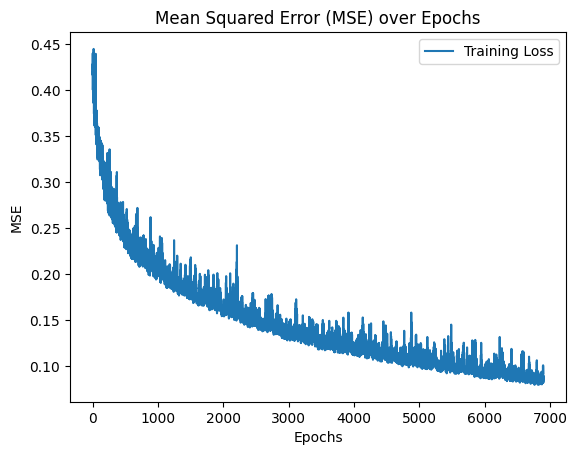

The function training took 19.717334985733032 seconds.


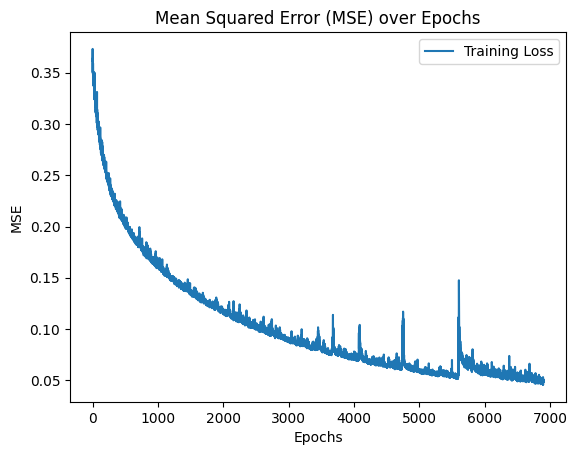

The function training took 20.49817442893982 seconds.


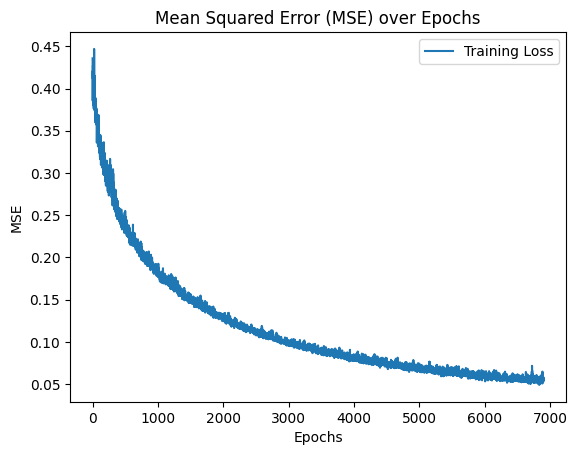

The function training took 20.62291121482849 seconds.


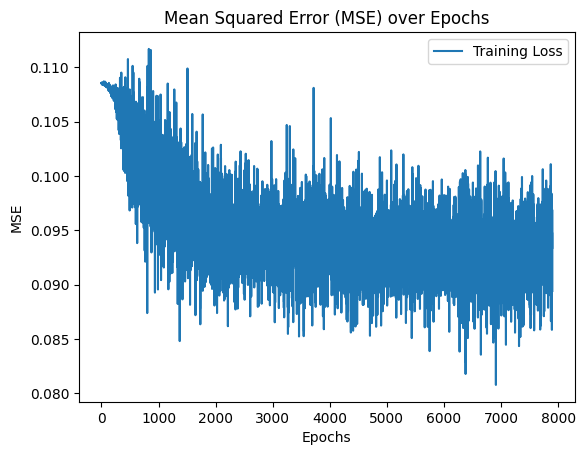

low fidelity 1 NN
Test MSE: 0.22814950517972157
R^2: -90.50057959597223


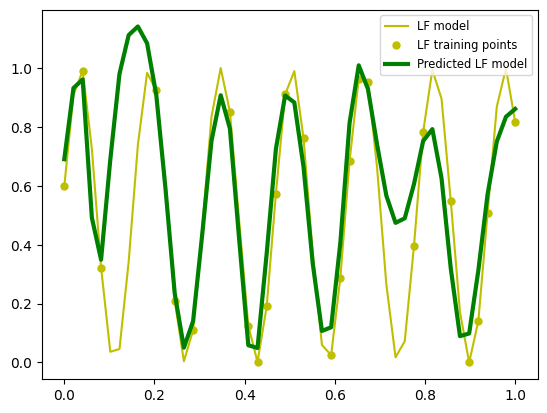

low fidelity 2 NN
Test MSE: 0.21488909864671718
R^2: -85.21052888849354


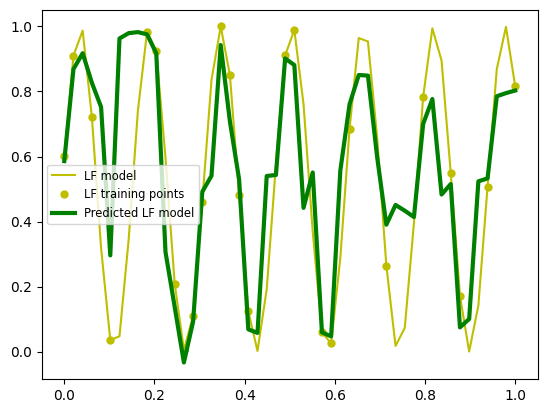

low fidelity 3 NN
Test MSE: 0.25664763932788864
R^2: -102.00335451500092


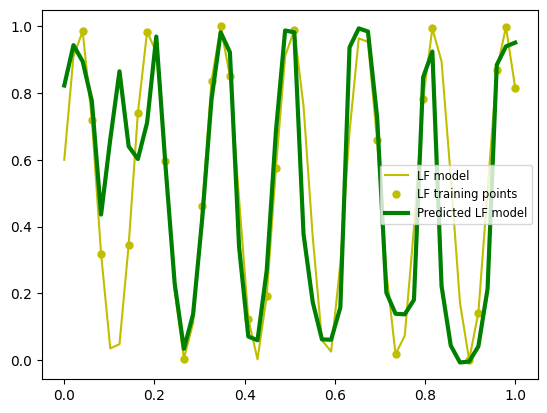

FInal model
Test MSE: 0.1373488697370961
R^2: -59.66711198198669


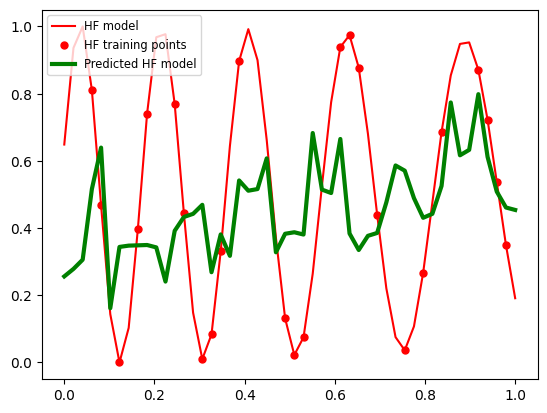

Saving ...


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6980\1887073931.py:259: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6980\1887073931.py:263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6980\1887073931.py:267: FutureWarning: The behavio

********************  # Diff: = 5  ********************
The function training took 19.923731565475464 seconds.


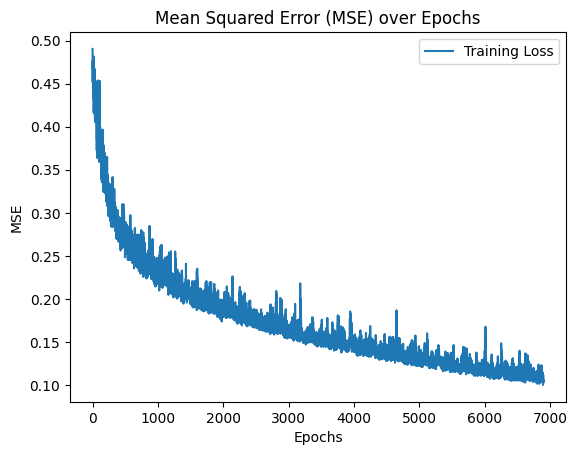

The function training took 22.575197458267212 seconds.


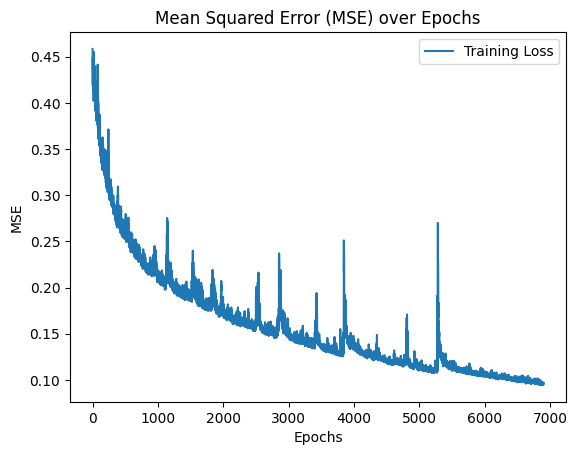

The function training took 22.08867120742798 seconds.


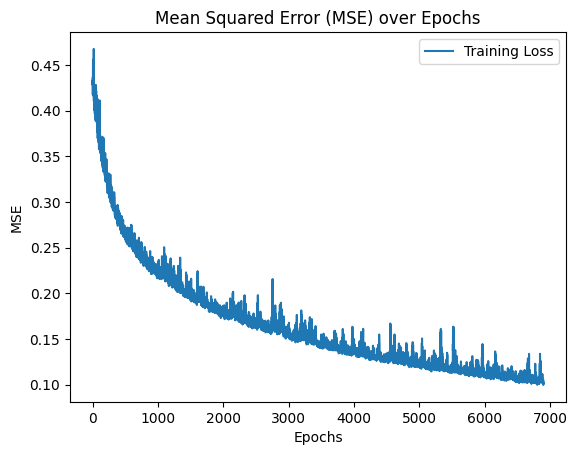

The function training took 20.256205558776855 seconds.


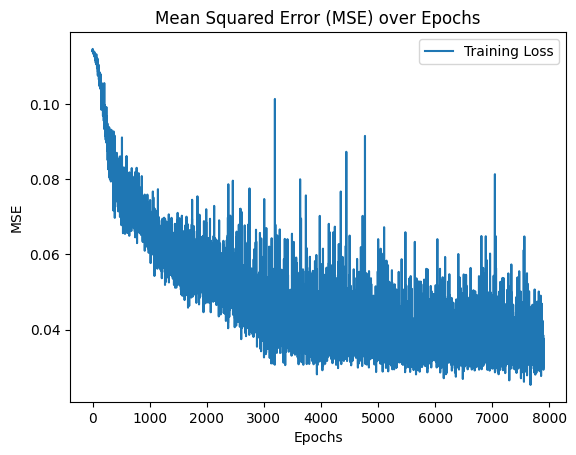

low fidelity 1 NN
Test MSE: 0.25394027380921064
R^2: -101.0565412723548


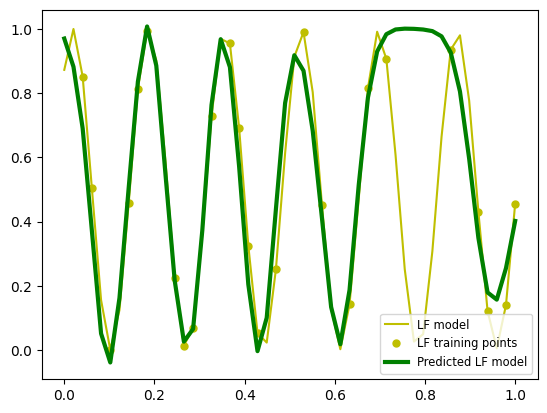

low fidelity 2 NN
Test MSE: 0.19126310070998362
R^2: -83.43730454239565


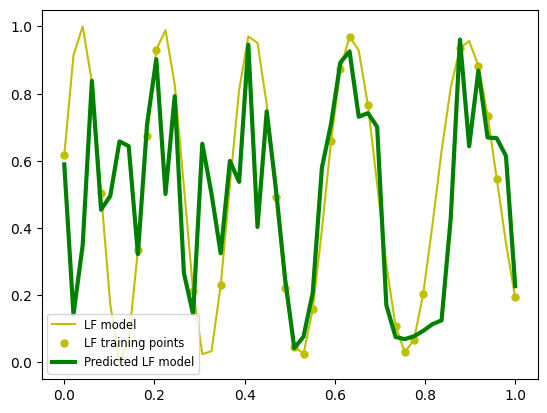

low fidelity 3 NN
Test MSE: 0.20292616771844232
R^2: -88.18920264892462


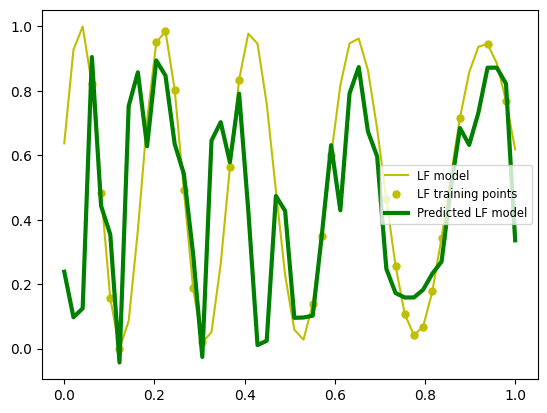

FInal model
Test MSE: 0.6946333949180594
R^2: -305.82015830625846


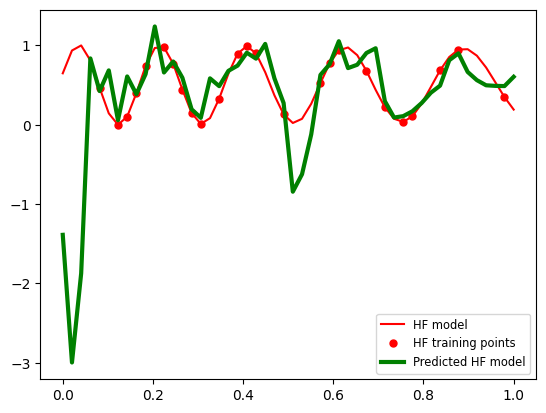

Saving ...
********************  # Diff: = 75  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\../utils\Structure.py:589: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 22.3847074508667 seconds.


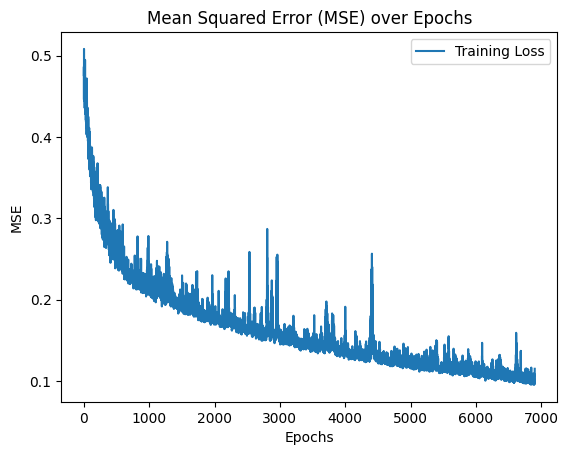

The function training took 22.995415449142456 seconds.


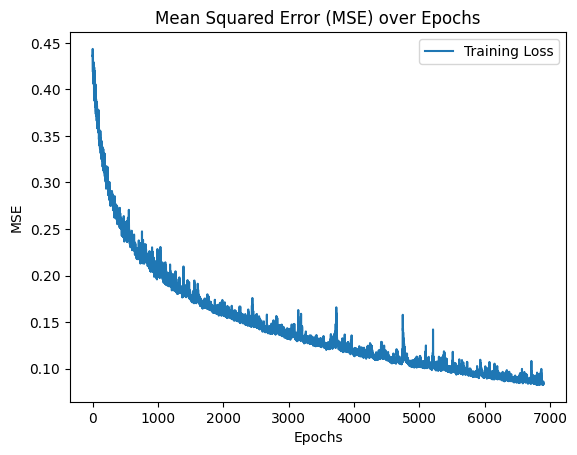

The function training took 20.903493404388428 seconds.


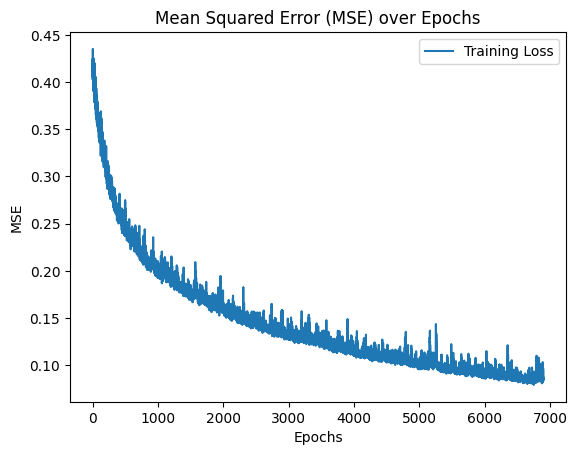

The function training took 22.815626859664917 seconds.


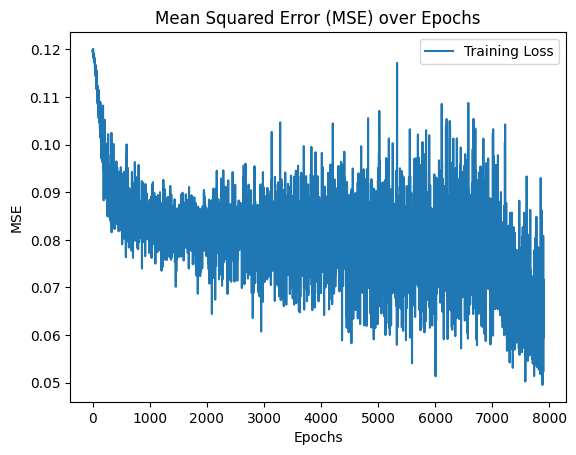

low fidelity 1 NN
Test MSE: 0.23747301845363308
R^2: -92.07283327710162


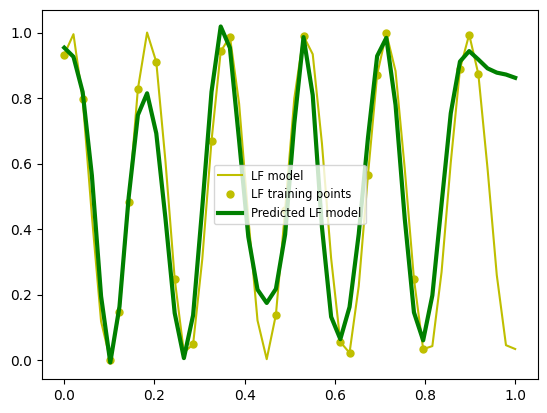

low fidelity 2 NN
Test MSE: 0.22958008053544235
R^2: -96.629939375371


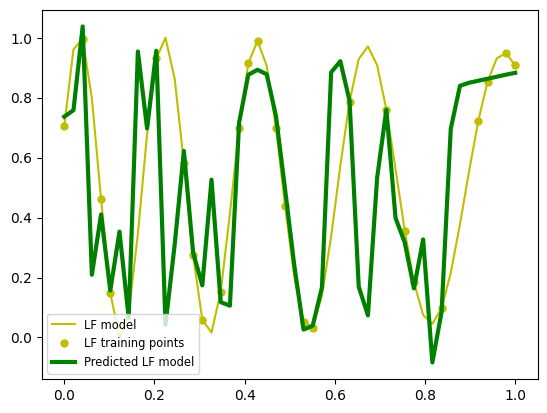

low fidelity 3 NN
Test MSE: 0.2179350501236815
R^2: -91.51140907890829


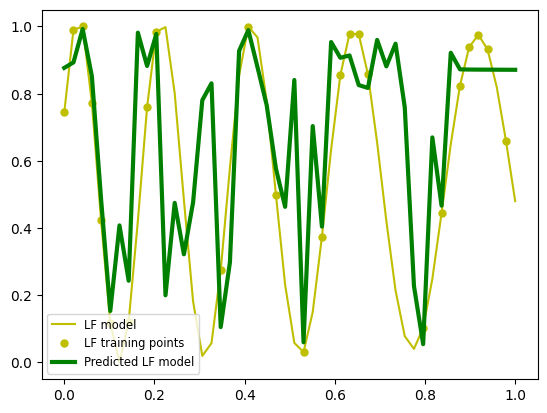

FInal model
Test MSE: 0.16469509951181013
R^2: -71.74596481276203


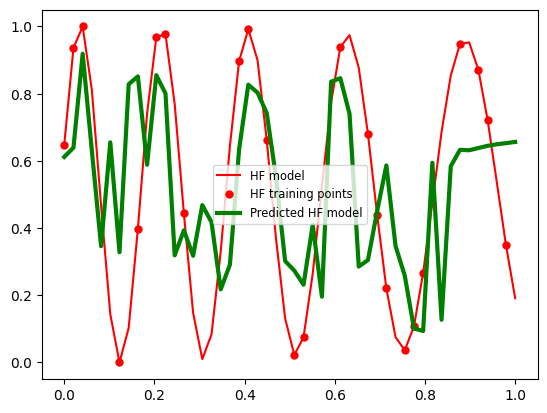

Saving ...
********************  # Diff: = 1  ********************


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\../utils\Structure.py:589: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


The function training took 23.228233337402344 seconds.


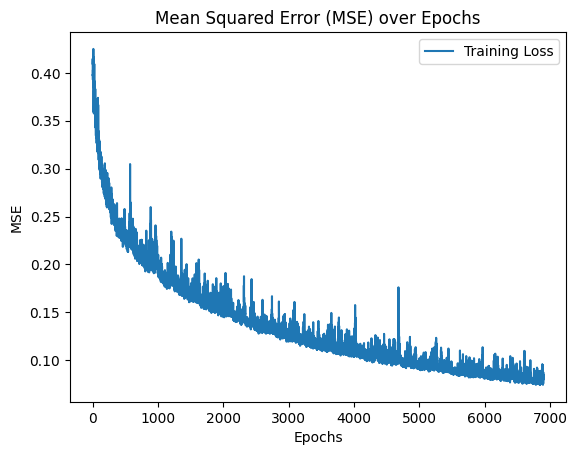

The function training took 24.136057138442993 seconds.


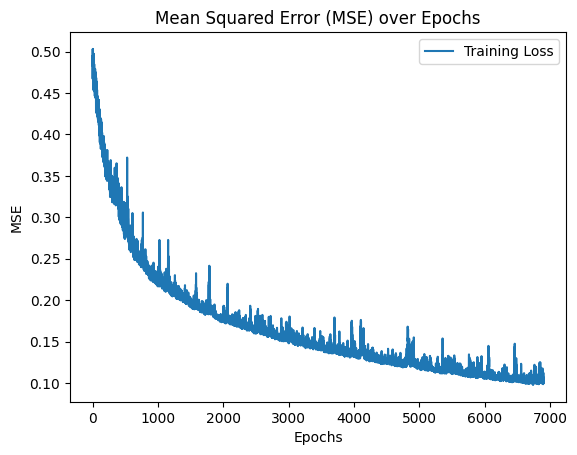

The function training took 22.338330030441284 seconds.


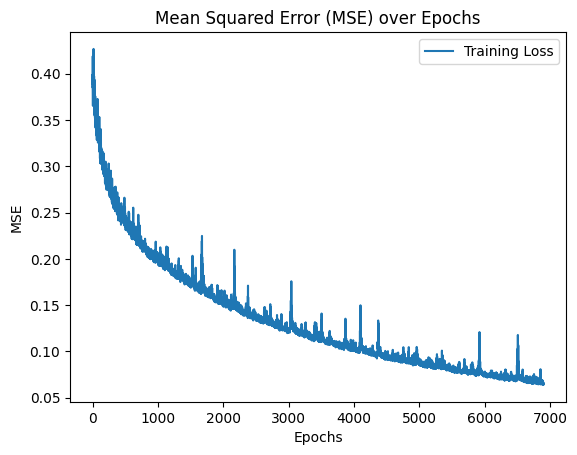

The function training took 21.27770757675171 seconds.


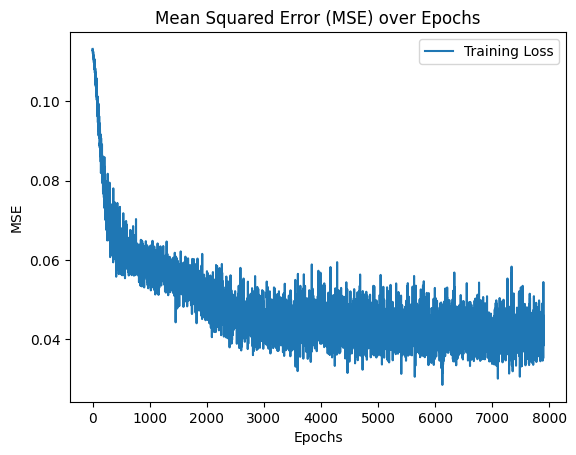

low fidelity 1 NN
Test MSE: 0.1983620296228238
R^2: -80.63488963716664


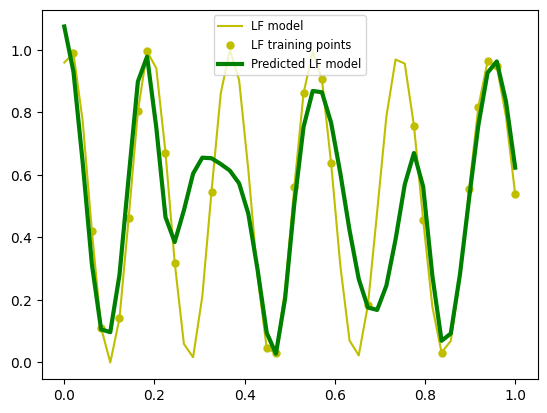

low fidelity 2 NN
Test MSE: 0.22827593925675738
R^2: -95.52575088125671


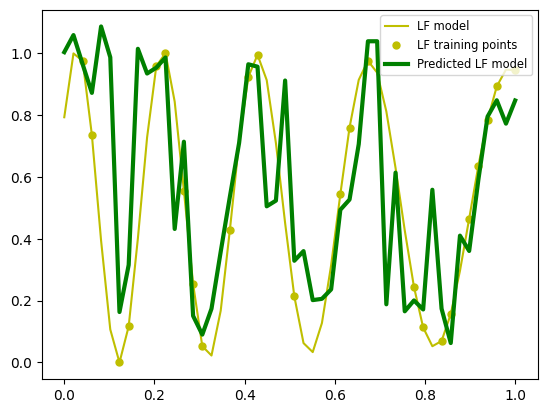

low fidelity 3 NN
Test MSE: 0.21894226703606723
R^2: -93.57145378255072


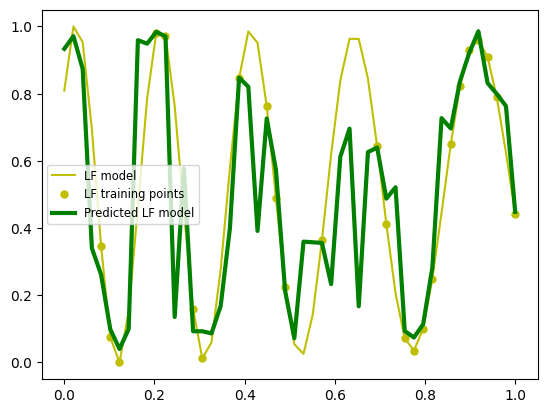

FInal model
Test MSE: 0.21285410751747622
R^2: -93.01783939908806


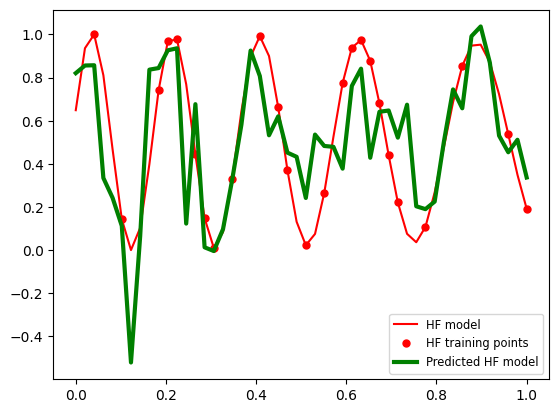

Saving ...
  diffusion         R2
0         0  -59.66711
1         5 -305.82016
2        75  -71.74596
3         1  -93.01784
  diffusion      MSE         R2
0         0  0.13735  -59.66711
1         5  0.69463 -305.82016
2        75  0.16470  -71.74596
3         1  0.21285  -93.01784


c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\../utils\Structure.py:589: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(self.model_list[index].model,folder)


In [9]:
# Name of the folder
folder_name = "sequential_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
      

for d in range(len(diffusion)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []

    print(
    f"********************  # Diff: = {diffusion[d]}  ********************"
    )
    
    data_train=[]
    data_test=[]
    output_train=[]
    output_test=[]
    permutation = np.random.permutation(len(reaction_HF_test))
    reaction_HF = reaction_HF_test[permutation,:][0:n_HF[0],:]
    U_HF = U_HF_test[permutation][0:n_HF[0]]

    for m in range(len(Discretizations)):
                
        file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

        # selection and normalization of the dataset
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]        
        U_LF_test = normalization(U_LF_test)
        reaction_LF_test = normalization(reaction_LF_test)

        # noise_std1=[0.02,0.01,0.02,0.01]
        # noise_std2=[0.01,0.005,0.01,0.005]
        # (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)


        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf[m]]
        U_train_LF = U_LF_test[permutation][0:Nlf[m]]
        
        #reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
        #reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]

        data_train.append(reaction_LF)
        output_train.append(U_train_LF)
        data_test.append(reaction_LF_test)
        output_test.append(U_LF_test)

    data_train.append(reaction_HF)
    output_train.append(U_HF)
    data_test.append(reaction_HF_test)
    output_test.append(U_HF_test)

    bestLF_params = {
        "lr": 0.0255,
        "kernel_init": "glorot_uniform",
        "opt": "Adam",
    } 
    best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

    names=["LF","LF","LF","HF"]
    params=[bestLF_params, bestLF_params, bestLF_params, best_params]
    
    data_train_original=copy.deepcopy(data_train)
    model= NetworkFactory.build_network("4step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)
################################
    # aggiungi un a serie di 4 plot uguali con concatenazione dei dati per l'input della tete 
                # low fidelity part of the network 
    ULF = model.model_list[0].prediction(data_test[0])
    print("low fidelity 1 NN")
    
    (test_mse_LF,r2_LF) = model.model_list[0].performance(data_test[0],output_test[0])
    test_mse_LF_list.append(test_mse_LF)
    r2_LF_list.append(r2_LF)

    plt.figure()
    plt.plot(
    data_test[0], output_test[0], "y-", linewidth=1.5, label="LF model"
    )
    plt.plot(
    data_train[0],
    output_train[0],
    "yo",
    markersize=5,
    label="LF training points",
    )
    plt.plot(
    data_test[0],
    ULF,
    "g-",
    linewidth=3,
    label="Predicted LF model",
    )
    plt.legend(prop={"size": 8.3})
    plt.show()


    # ---- 2NN
    # test component of the dataset (for each NN)
    input_LF2 = np.concatenate(
        (data_test[1],  model.model_list[0].prediction(data_test[1]).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF   

    input_LF3 = np.concatenate(
        (data_test[2],  model.model_list[0].prediction(data_test[2]).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF  

    input_HF = np.concatenate(
        (data_test[3],  model.model_list[0].prediction(data_test[3]).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF  

    # training component of the dataset (for each NN)
    input_LF2_train = np.concatenate(
        (data_train_original[1],  model.model_list[0].prediction(data_train_original[1]).reshape(-1,1)),axis=1
    ) 

    input_LF3_train = np.concatenate(
        (data_train_original[2],  model.model_list[0].prediction(data_train_original[2]).reshape(-1,1)),axis=1
    ) 

    input_HF_train = np.concatenate(
        (data_train_original[3],  model.model_list[0].prediction(data_train_original[3]).reshape(-1,1)),axis=1
    ) 

    ULF2 = model.model_list[1].prediction(input_LF2)
    print("low fidelity 2 NN")
    
    (test_mse_LF,r2_LF) = model.model_list[1].performance(input_LF2,output_test[1])
    test_mse_LF_list.append(test_mse_LF)
    r2_LF_list.append(r2_LF)

    plt.figure()
    plt.plot(
    data_test[1], output_test[1], "y-", linewidth=1.5, label="LF model"
    )
    plt.plot(
    data_train_original[1],
    output_train[1],
    "yo",
    markersize=5,
    label="LF training points",
    )
    plt.plot(
    data_test[1],
    ULF2,
    "g-",
    linewidth=3,
    label="Predicted LF model",
    )
    plt.legend(prop={"size": 8.3})
    plt.show()
    # ----- 3NN
    # test component of the dataset (for each NN)

    input_LF3 = np.concatenate(
        (input_LF3,  model.model_list[1].prediction(input_LF3).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF

    input_HF = np.concatenate(
        (input_HF,  model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF   

    input_LF3_train = np.concatenate(
        (input_LF3_train,  model.model_list[1].prediction(input_LF3_train).reshape(-1,1)),axis=1
    ) 

    input_HF_train = np.concatenate(
        (input_HF_train,  model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1
    ) 

    ULF3 = model.model_list[2].prediction(input_LF3)
    print("low fidelity 3 NN")
    
    (test_mse_LF,r2_LF) = model.model_list[2].performance(input_LF3,output_test[2])
    test_mse_LF_list.append(test_mse_LF)
    r2_LF_list.append(r2_LF)

    plt.figure()
    plt.plot(
    data_test[2], output_test[2], "y-", linewidth=1.5, label="LF model"
    )
    plt.plot(
    data_train_original[2],
    output_train[2],
    "yo",
    markersize=5,
    label="LF training points",
    )
    plt.plot(
    data_test[2],
    ULF3,
    "g-",
    linewidth=3,
    label="Predicted LF model",
    )
    plt.legend(prop={"size": 8.3})
    plt.show()


    # ------- HNN

                # creation of the input of the second part of the 2 steps NN to study the high fidelity model
    input_HF = np.concatenate(
        (input_HF,  model.model_list[2].prediction(input_HF).reshape(-1,1)),axis=1
    )  # <- TRAINING INPUT for the second NN: NN_HF

    input_HF_train = np.concatenate(
        (input_HF_train,  model.model_list[2].prediction(input_HF_train).reshape(-1,1)),axis=1
    ) 

    UHF=model.model_list[3].prediction(input_HF)
    # performance of the last part of the network
    print("FInal model")
    (test_mse_HF,r2_HF) = model.model_list[3].performance(input_HF,output_test[3])                
    test_mse_HF_list.append(test_mse_HF)
    r2_HF_list.append(r2_HF)

    plt.figure()
    plt.plot(
    data_test[3], output_test[3], "r-", linewidth=1.5, label="HF model"
    )
    plt.plot(
    data_train_original[3],
    output_train[3],
    "ro",
    markersize=5,
    label="HF training points",
    )
    
    plt.plot(
    data_test[3],
    UHF,
    "g-",
    linewidth=3,
    label="Predicted HF model",
    )
    plt.legend(prop={"size": 8.3})
    plt.show()

    new_data = {'diffusion': diffusion[d]}

    # DataFrame r2_LF_df
    new_data['R2'] = r2_LF_list[-1]
    r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

    # DataFrame r2_HF_df              
    new_data['R2'] = r2_HF_list[-1]
    r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

    # DataFrame mse_LF_df
    new_data['MSE'] = test_mse_LF_list[-1]
    mse_LF_df = pandas.concat([mse_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

    # DataFrame mse_HF_df
    new_data['MSE'] = test_mse_HF_list[-1]
    mse_HF_df = pandas.concat([mse_HF_df, pandas.DataFrame([new_data])], ignore_index=True)


    # save the model
    model_list[d]=model
    model.save(str(diffusion[d]),folder_path)
               

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

In [10]:
for i in range(5):
    print(i)

0
1
2
3
4


In [11]:
data_test[-1]

array([[0.        ],
       [0.02040816],
       [0.04081633],
       [0.06122449],
       [0.08163265],
       [0.10204082],
       [0.12244898],
       [0.14285714],
       [0.16326531],
       [0.18367347],
       [0.20408163],
       [0.2244898 ],
       [0.24489796],
       [0.26530612],
       [0.28571429],
       [0.30612245],
       [0.32653061],
       [0.34693878],
       [0.36734694],
       [0.3877551 ],
       [0.40816327],
       [0.42857143],
       [0.44897959],
       [0.46938776],
       [0.48979592],
       [0.51020408],
       [0.53061224],
       [0.55102041],
       [0.57142857],
       [0.59183673],
       [0.6122449 ],
       [0.63265306],
       [0.65306122],
       [0.67346939],
       [0.69387755],
       [0.71428571],
       [0.73469388],
       [0.75510204],
       [0.7755102 ],
       [0.79591837],
       [0.81632653],
       [0.83673469],
       [0.85714286],
       [0.87755102],
       [0.89795918],
       [0.91836735],
       [0.93877551],
       [0.959

## Save the output

In [12]:
# os.makedirs(folder_path)

# r2_HF_df.to_csv(
#     "./{folder_name}/r2_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_HF_df.to_csv(
#     "./{folder_name}/mse_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# r2_LF_df.to_csv(
#     "./{folder_name}/r2_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_LF_df.to_csv(
#     "./{folder_name}/mse_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )

# with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
#     # store the data as binary data stream
#     pickle.dump(U_HF_list, filehandle)

# with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
#     pickle.dump(U_LF_list, filehandle)

# Inverse problem

In [13]:
dim=5
# before normalization I look for 5 values between 0.5 and 1.5
#real_x = np.random.rand(dim)
real_x=np.array([0.11234,0.333,0.5,0.665,0.7])
reaction_HF_test_original=reaction_HF_test_original[:,0]
# I find the mmost similar value in our dataset, so that I can then find the "correct" U for the function
closest_indices = np.argmin(np.abs(reaction_HF_test_original[:, np.newaxis] - real_x), axis=0)
real_x=real_x.reshape(-1, 1)

nearest_x=reaction_HF_test_original[closest_indices]

NameError: name 'reaction_HF_test_original' is not defined

In [ ]:
# found the correct value, as if I have applied the real function
nearest_U=U_HF_test_original[closest_indices]
reaction_HF_test_original=np.c_[reaction_HF_test_original, np.abs(np.sin(5*np.pi*reaction_HF_test_original-5*np.pi/6))]

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x)) # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

In [ ]:
#real_x=np.c_[real_x, np.abs(np.sin(5*np.pi*real_x-5*np.pi/6))]
transformations= lambda x: np.abs(np.sin(5*np.pi*x-5*np.pi/6))
transformations=[transformations]

In [ ]:
# from functools import reduce

# x_final = reduce(lambda acc, trasf: np.hstack([acc, trasf(acc)]), transformations, real_x)

In [ ]:
nearest_U=nearest_U.reshape(-1,1)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]


Sampling chain 1/4


Running chain, α = 0.55: 100%|██████████| 1000/1000 [01:22<00:00, 12.12it/s]


Sampling chain 2/4


Running chain, α = 0.45: 100%|██████████| 1000/1000 [01:22<00:00, 12.17it/s]


Sampling chain 3/4


Running chain, α = 0.65: 100%|██████████| 1000/1000 [01:22<00:00, 12.18it/s]


Sampling chain 4/4


Running chain, α = 0.58: 100%|██████████| 1000/1000 [01:21<00:00, 12.26it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.271 0.496 0.408 0.51  0.42 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.271  0.426  -0.366    1.121      0.148    0.124       9.0      16.0   
x1  0.496  0.360  -0.154    1.198      0.114    0.084      10.0      24.0   
x2  0.408  0.386  -0.208    1.112      0.149    0.110       7.0      25.0   
x3  0.510  0.364  -0.252    1.126      0.114    0.083      10.0      17.0   
x4  0.420  0.395  -0.431    1.036      0.164    0.122       6.0      17.0   

    r_hat  
x0   1.38  
x1   1.33  
x2   1.57  
x3   1.32  
x4   1.74  
Autocorrelation...
[0.15866 0.163   0.092   0.155   0.28   ]


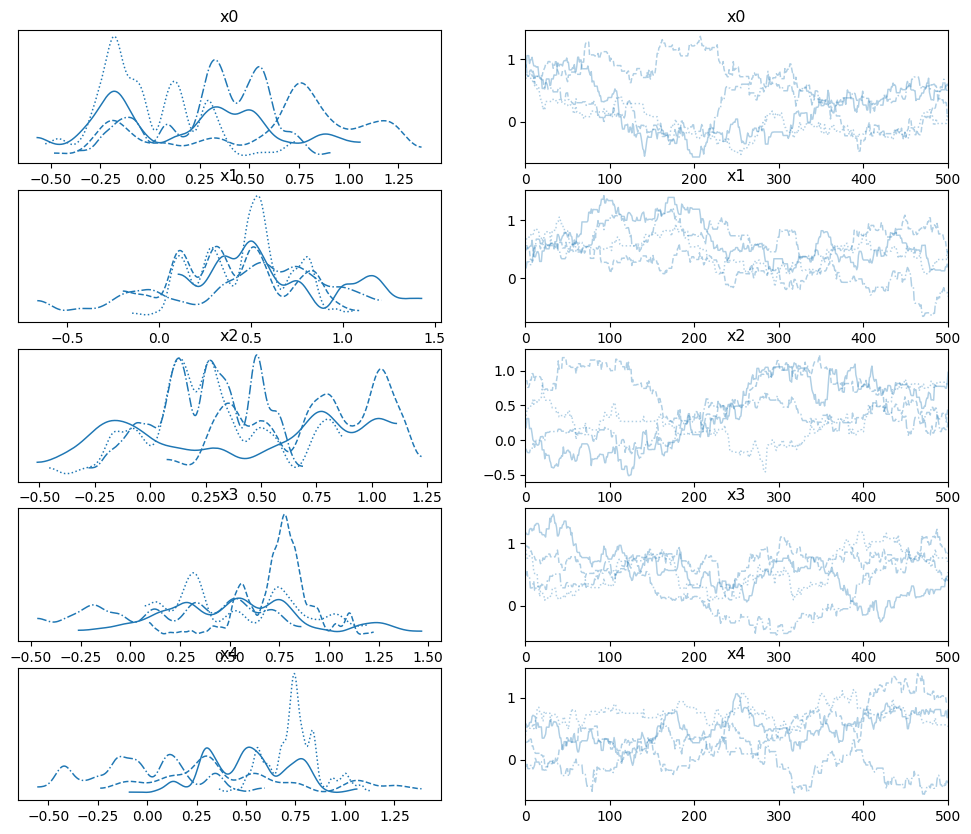

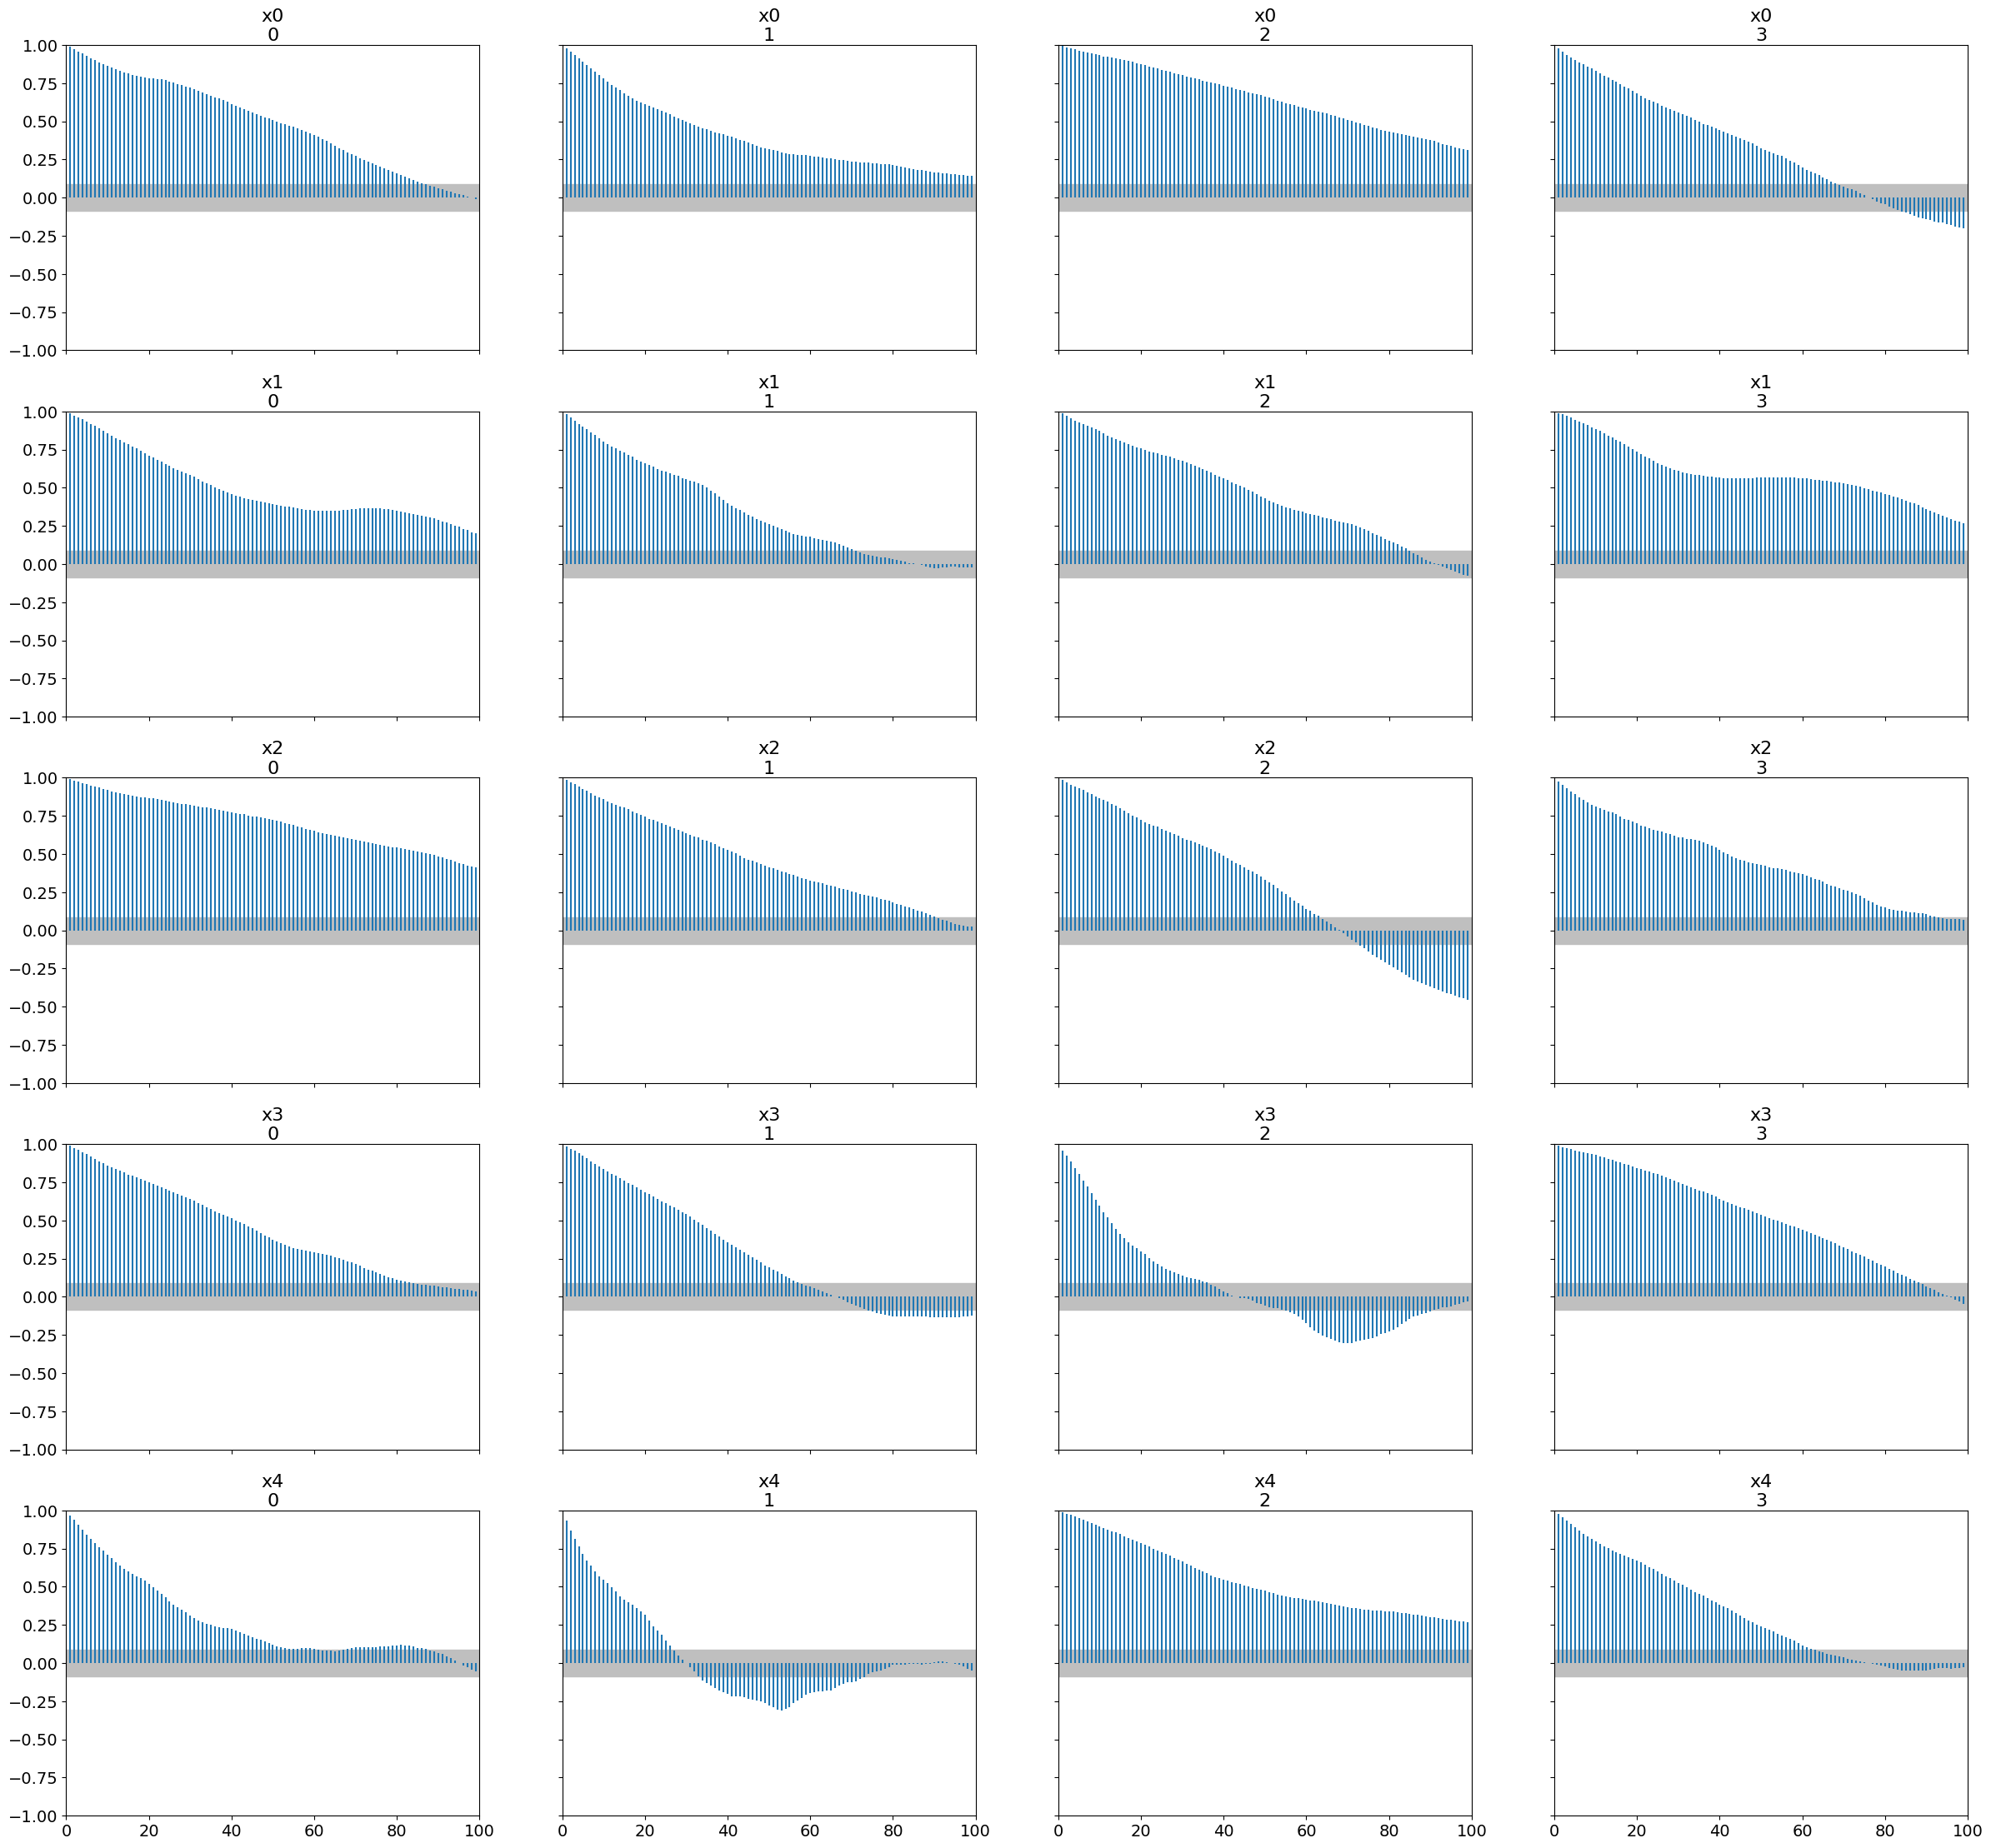

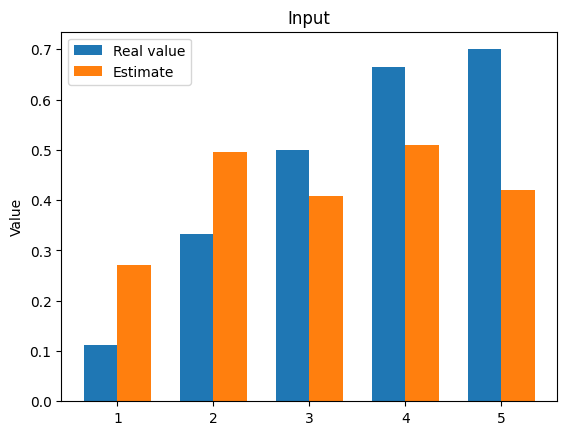

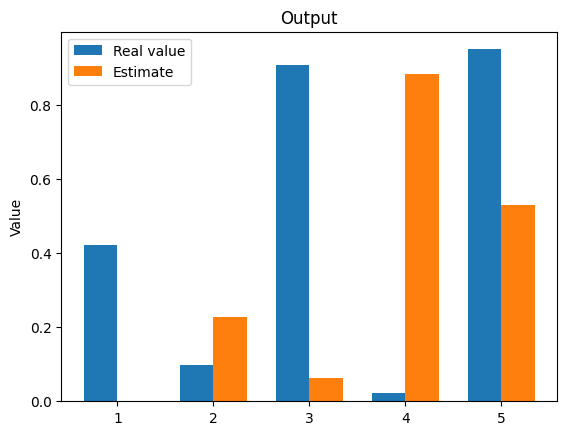

The function inverse took 362.8616828918457 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.56: 100%|██████████| 1000/1000 [01:23<00:00, 12.04it/s]


Sampling chain 2/4


Running chain, α = 0.45: 100%|██████████| 1000/1000 [01:22<00:00, 12.13it/s]


Sampling chain 3/4


Running chain, α = 0.34: 100%|██████████| 1000/1000 [01:22<00:00, 12.15it/s]


Sampling chain 4/4


Running chain, α = 0.51: 100%|██████████| 1000/1000 [01:23<00:00, 12.02it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.557 0.35  0.476 0.598 0.49 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.557  0.336   0.064    1.166      0.141    0.105       6.0      34.0   
x1  0.350  0.332  -0.154    1.015      0.104    0.078      12.0      53.0   
x2  0.476  0.292   0.006    1.036      0.094    0.071      10.0      31.0   
x3  0.598  0.303   0.073    1.191      0.110    0.083       8.0      26.0   
x4  0.490  0.329   0.028    1.175      0.122    0.090       8.0      49.0   

    r_hat  
x0   1.76  
x1   1.30  
x2   1.33  
x3   1.46  
x4   1.56  
Autocorrelation...
[0.44466 0.017   0.024   0.067   0.21   ]


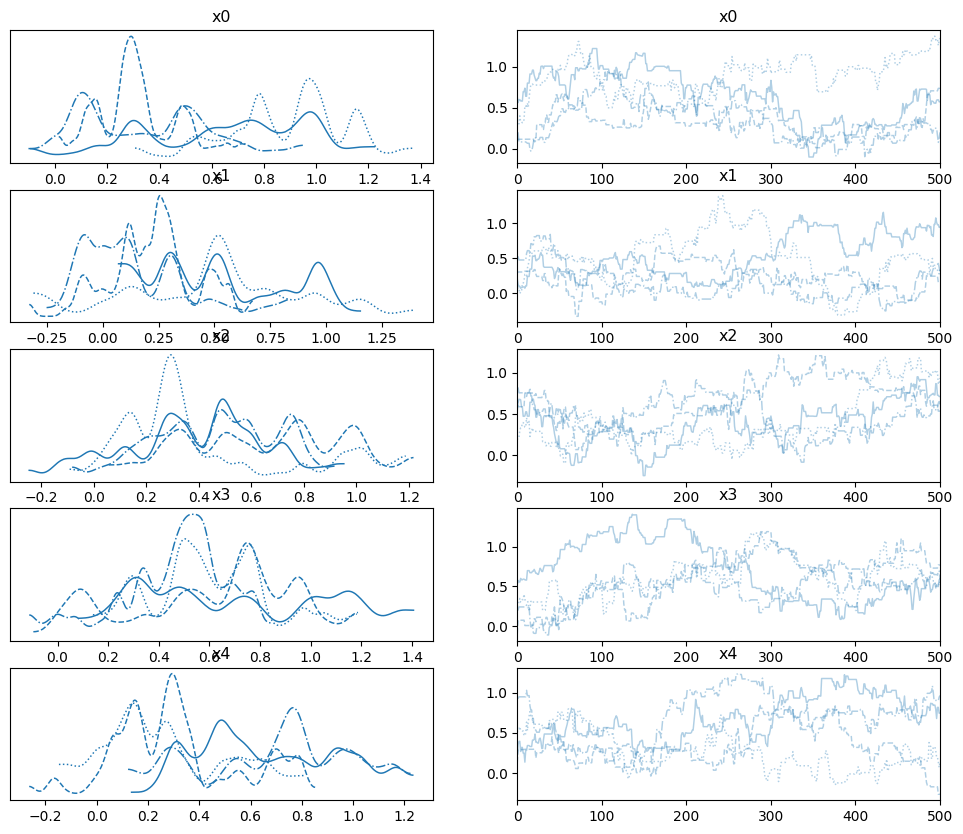

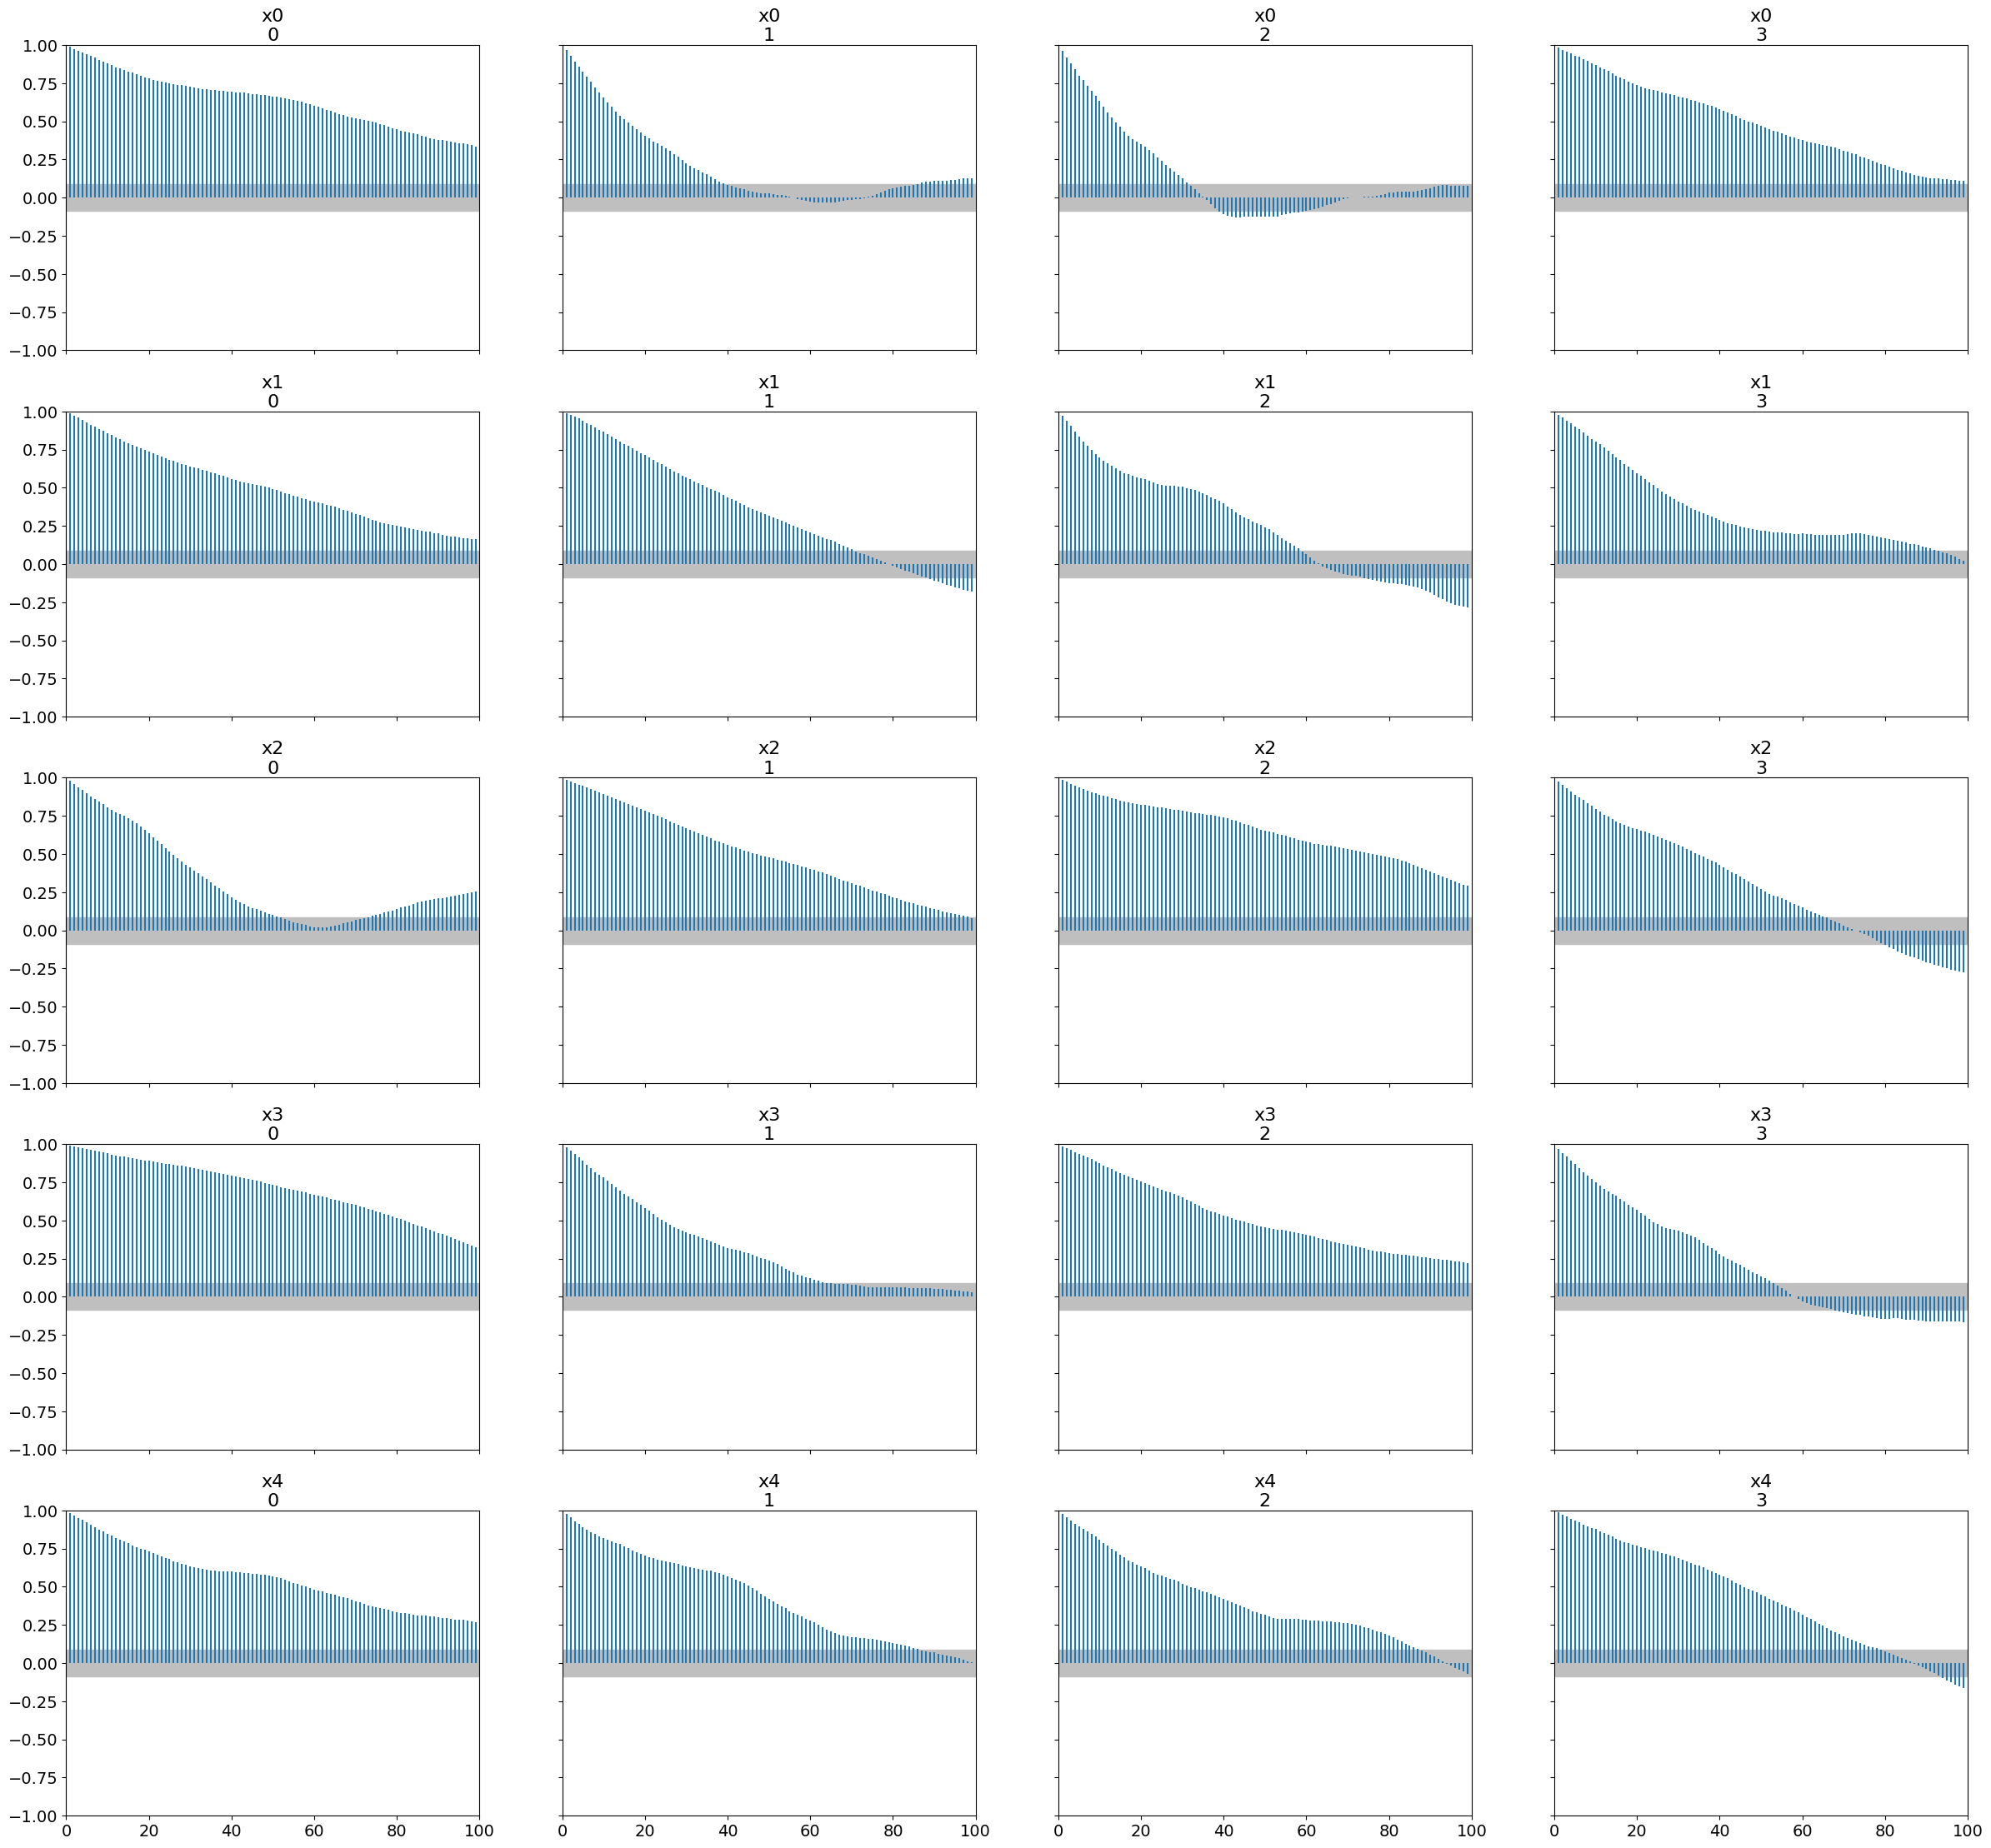

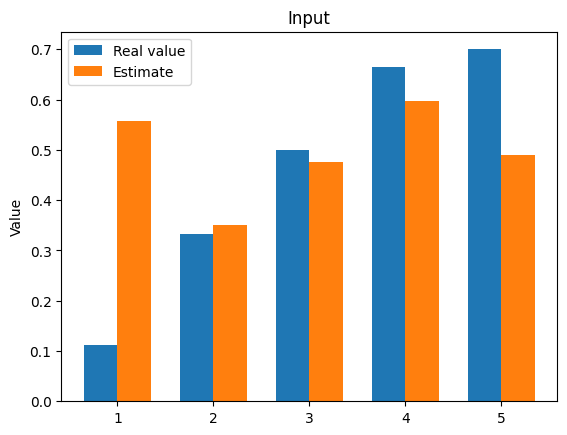

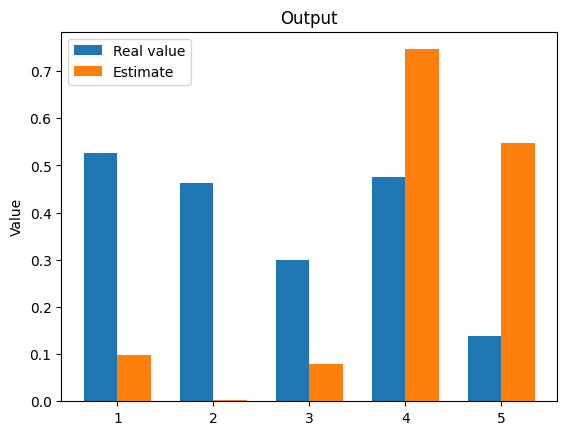

The function inverse took 370.56435656547546 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.71: 100%|██████████| 1000/1000 [01:22<00:00, 12.09it/s]


Sampling chain 2/4


Running chain, α = 0.62: 100%|██████████| 1000/1000 [01:24<00:00, 11.82it/s]


Sampling chain 3/4


Running chain, α = 0.78: 100%|██████████| 1000/1000 [01:31<00:00, 10.92it/s]


Sampling chain 4/4


Running chain, α = 0.75: 100%|██████████| 1000/1000 [01:33<00:00, 10.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.624 0.468 0.384 0.566 0.568]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.624  0.367  -0.061    1.304      0.134    0.106       8.0      15.0   
x1  0.468  0.287  -0.003    1.031      0.082    0.063      14.0      32.0   
x2  0.384  0.327  -0.342    0.853      0.127    0.094       7.0      13.0   
x3  0.566  0.299   0.059    1.216      0.088    0.064      11.0      50.0   
x4  0.568  0.316  -0.084    1.092      0.088    0.064      13.0      25.0   

    r_hat  
x0   1.42  
x1   1.22  
x2   1.56  
x3   1.31  
x4   1.23  
Autocorrelation...
[0.51166 0.135   0.116   0.099   0.132  ]


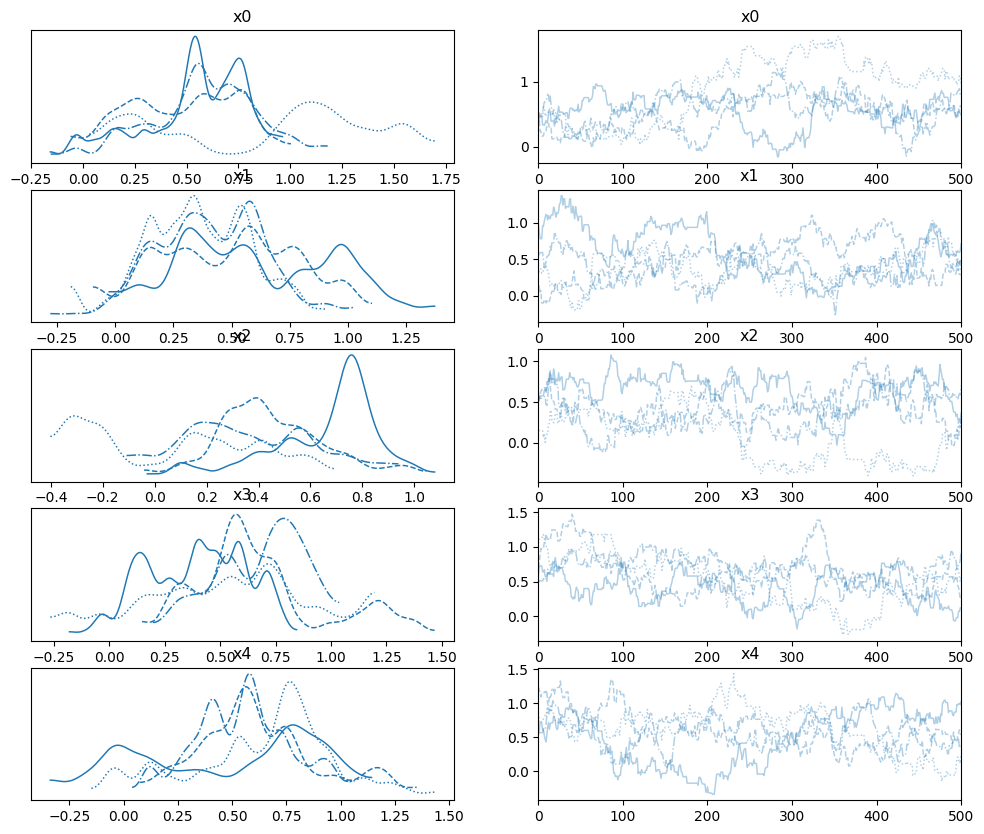

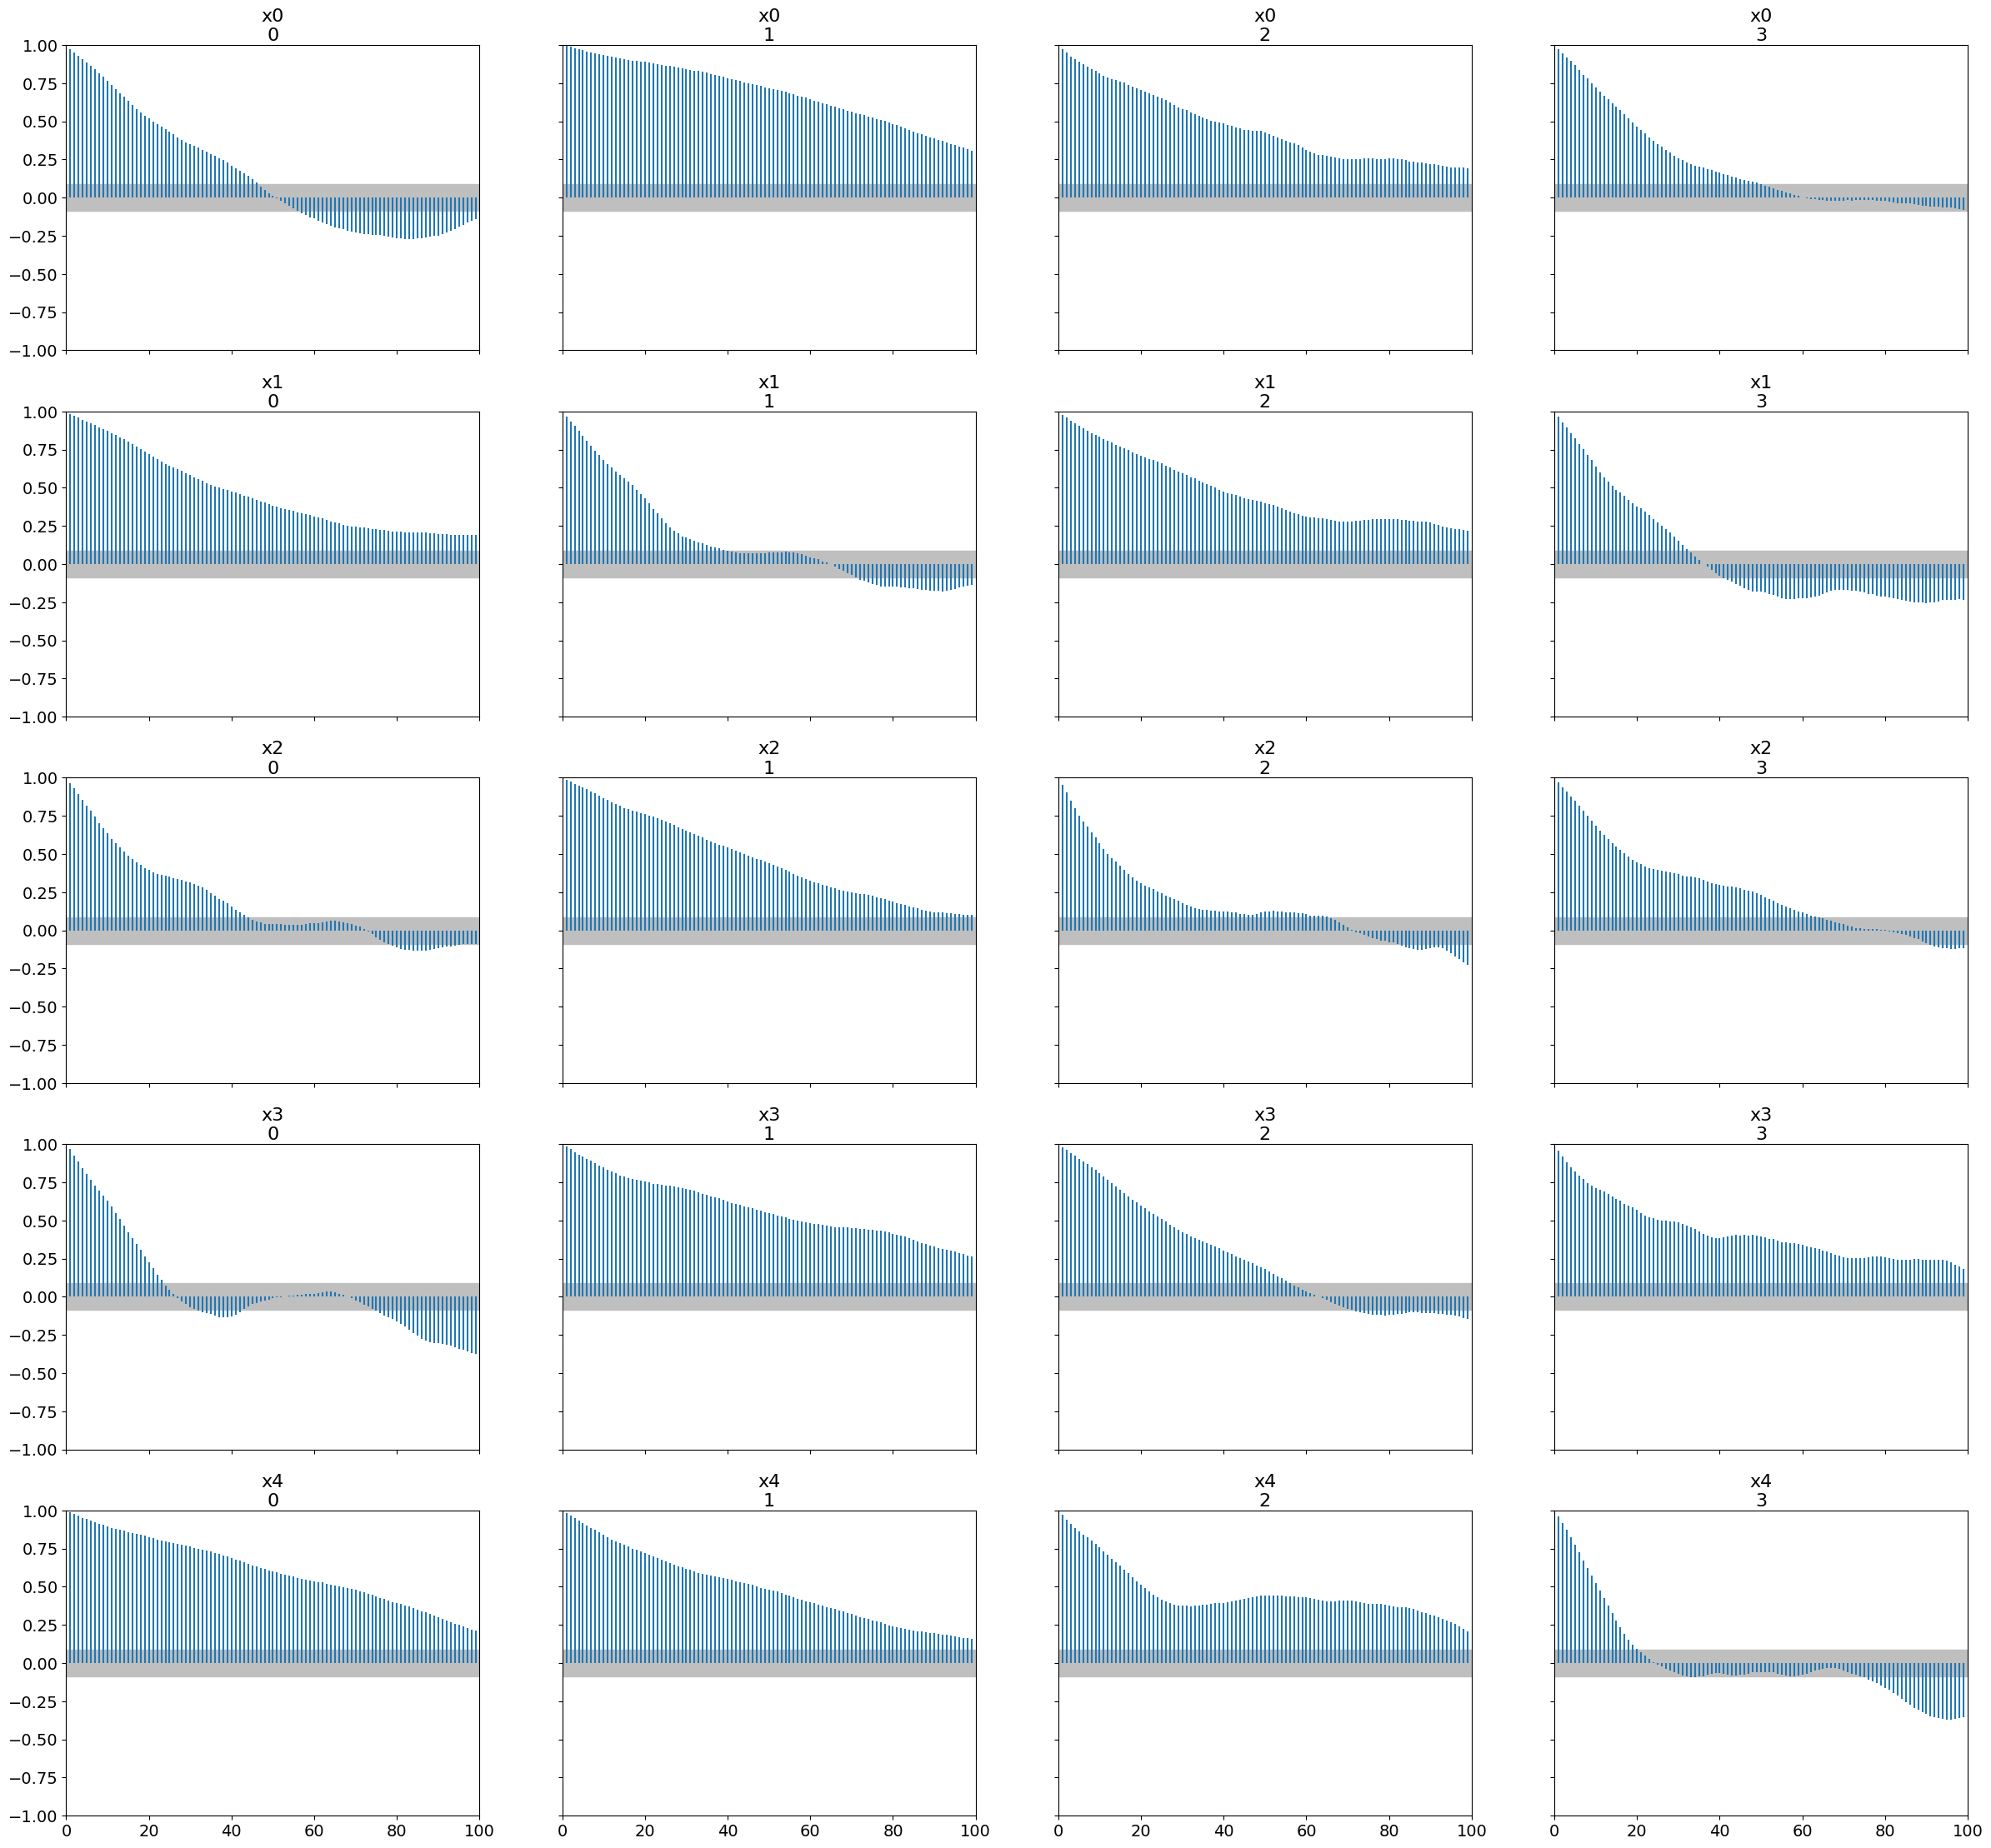

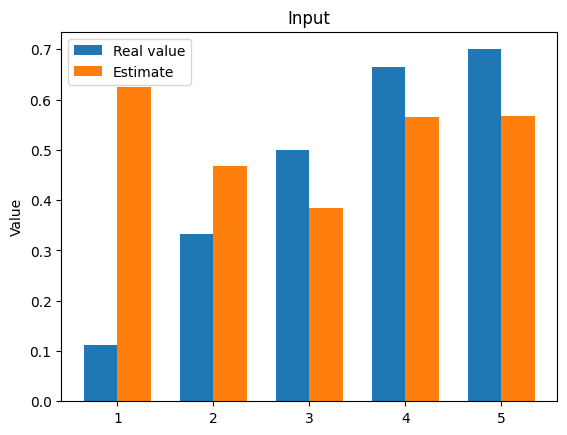

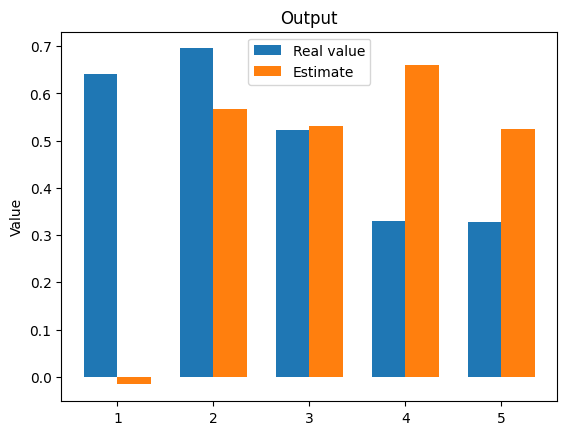

The function inverse took 407.01258635520935 seconds.


In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="RW")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="RW")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]


KeyboardInterrupt: 

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.40: 100%|██████████| 2000/2000 [04:55<00:00,  6.76it/s]


Sampling chain 2/4


Running chain, α = 0.35: 100%|██████████| 2000/2000 [05:08<00:00,  6.48it/s]


Sampling chain 3/4


Running chain, α = 0.32: 100%|██████████| 2000/2000 [05:10<00:00,  6.44it/s]


Sampling chain 4/4


Running chain, α = 0.37: 100%|██████████| 2000/2000 [05:22<00:00,  6.20it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.5   0.567 0.64  0.66  0.524]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.500  0.311  -0.005    1.148      0.031    0.022     100.0     257.0   
x1  0.567  0.341  -0.054    1.163      0.074    0.053      22.0     168.0   
x2  0.640  0.349   0.087    1.336      0.053    0.038      44.0     164.0   
x3  0.660  0.354   0.059    1.322      0.051    0.037      51.0     128.0   
x4  0.524  0.374  -0.202    1.193      0.036    0.026     110.0     229.0   

    r_hat  
x0   1.04  
x1   1.13  
x2   1.09  
x3   1.10  
x4   1.05  
Autocorrelation...
[0.38766 0.234   0.14    0.005   0.176  ]


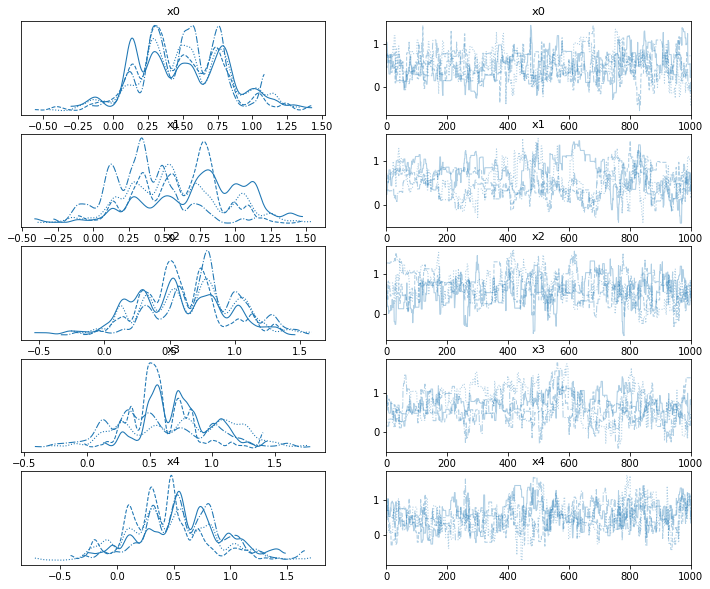

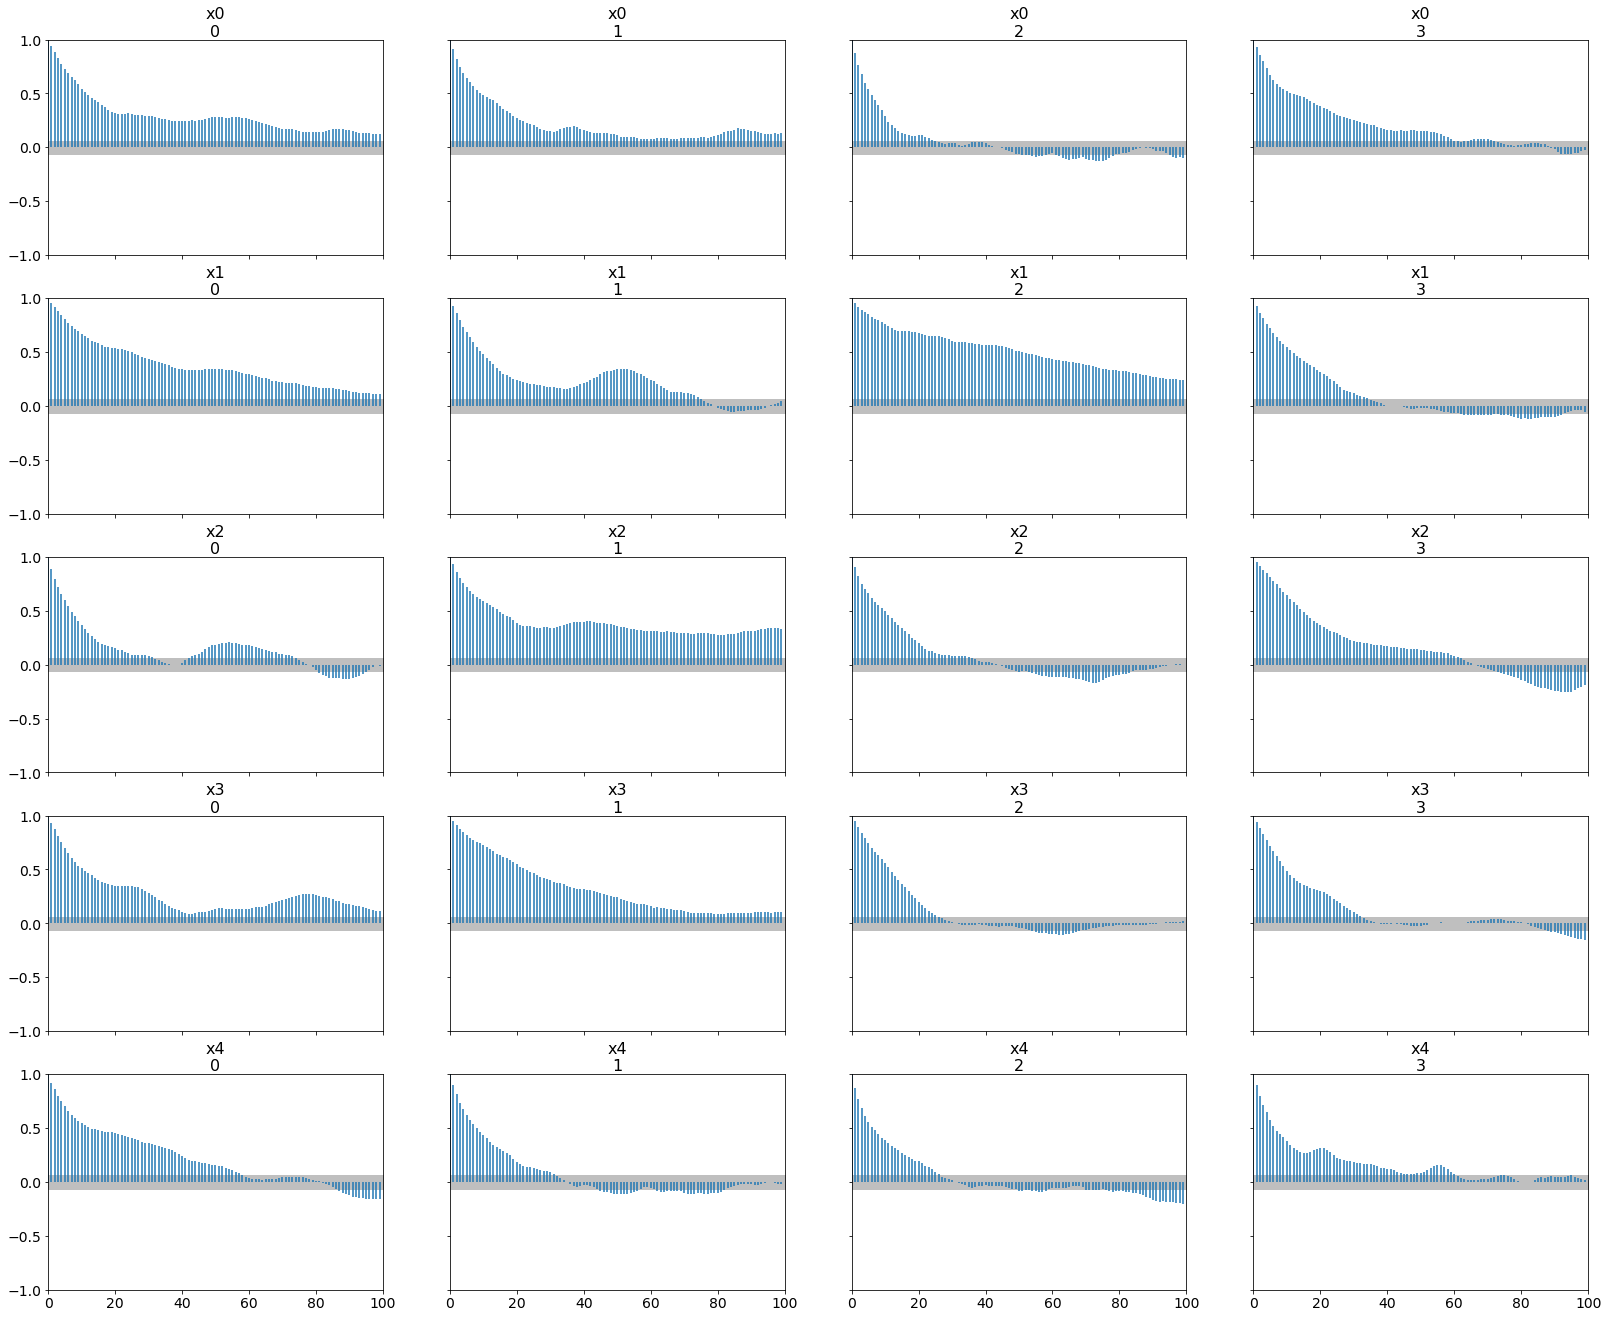

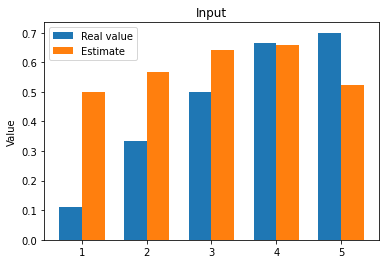

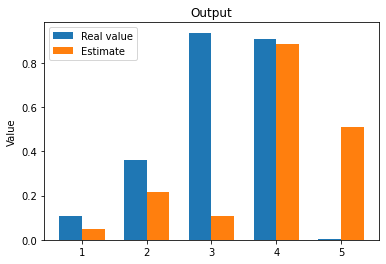

The function inverse took 1364.1761486530304 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.35: 100%|██████████| 2000/2000 [05:19<00:00,  6.26it/s]


Sampling chain 2/4


Running chain, α = 0.34: 100%|██████████| 2000/2000 [05:22<00:00,  6.21it/s]


Sampling chain 3/4


Running chain, α = 0.31:  76%|███████▌  | 1523/2000 [04:15<01:19,  5.99it/s]

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=2000#4000#8000
burnin=1000#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="AM")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.05: 100%|██████████| 1000/1000 [02:48<00:00,  5.95it/s]


Sampling chain 2/4


Running chain, α = 0.07: 100%|██████████| 1000/1000 [02:41<00:00,  6.19it/s]


Sampling chain 3/4


Running chain, α = 0.02: 100%|██████████| 1000/1000 [02:51<00:00,  5.83it/s]


Sampling chain 4/4


Running chain, α = 0.12: 100%|██████████| 1000/1000 [02:48<00:00,  5.93it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.605 0.52  0.565 0.629 0.688]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.605  0.282   0.076    1.114      0.042    0.031      47.0      69.0   
x1  0.520  0.347  -0.063    1.078      0.055    0.039      40.0      22.0   
x2  0.565  0.284   0.009    0.952      0.068    0.049      16.0      80.0   
x3  0.629  0.378  -0.029    1.290      0.049    0.035      62.0      59.0   
x4  0.688  0.337   0.059    1.310      0.084    0.060      17.0      64.0   

    r_hat  
x0   1.09  
x1   1.06  
x2   1.19  
x3   1.18  
x4   1.20  
Autocorrelation...
[0.49266 0.187   0.065   0.036   0.012  ]


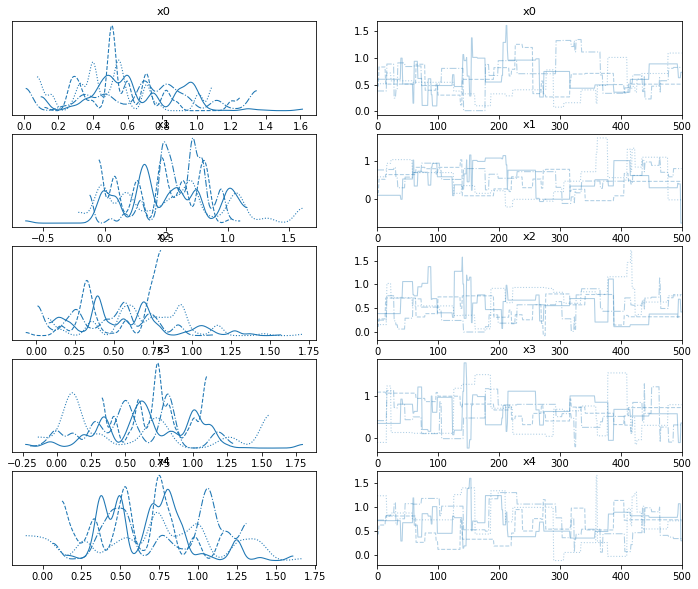

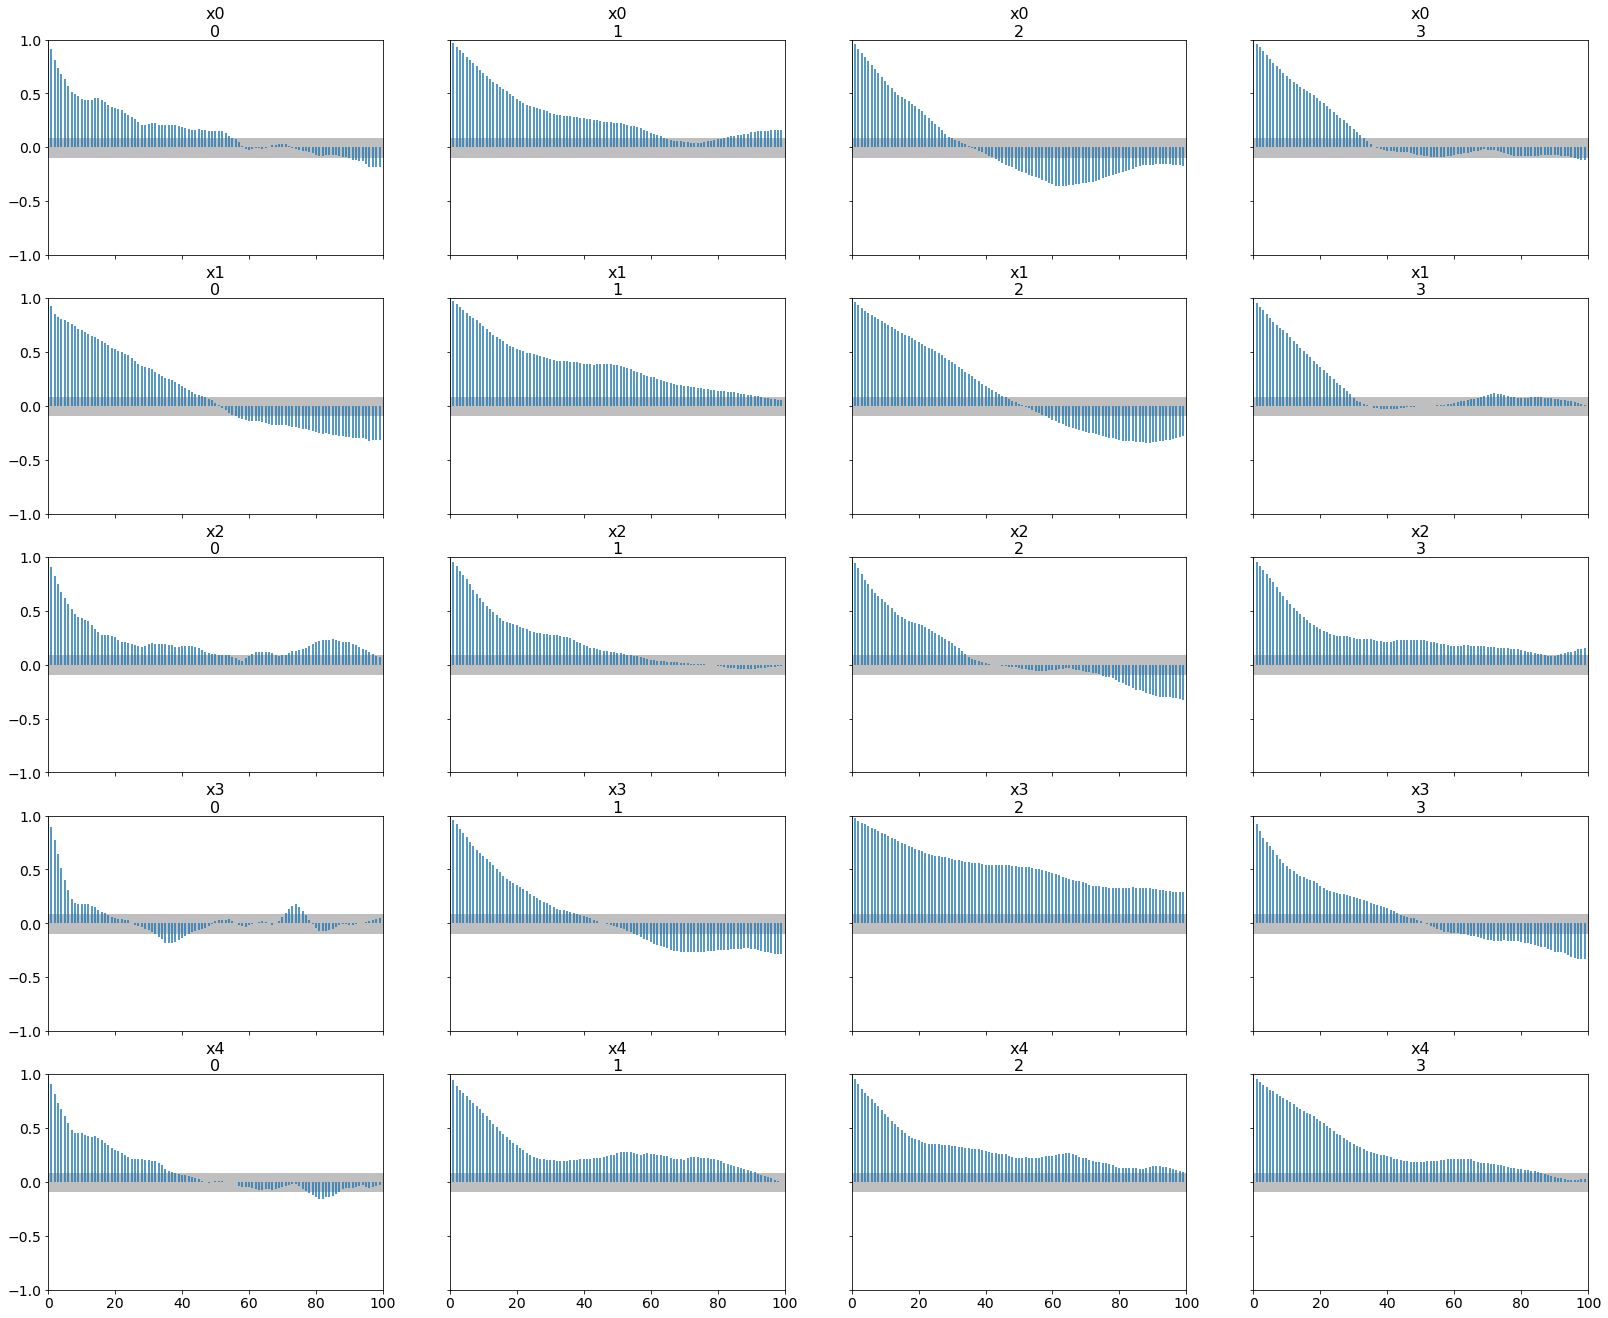

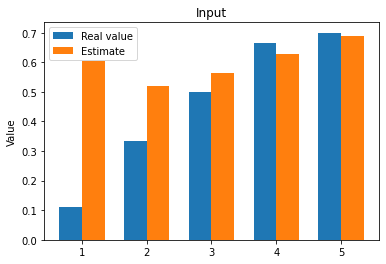

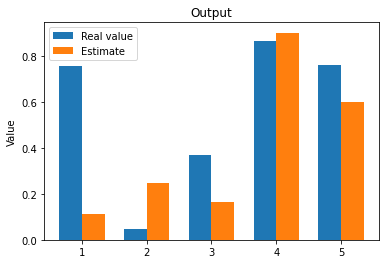

The function inverse took 730.7625484466553 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="AM")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.75: 100%|██████████| 1000/1000 [02:52<00:00,  5.81it/s]


Sampling chain 2/4


Running chain, α = 0.73: 100%|██████████| 1000/1000 [02:50<00:00,  5.88it/s]


Sampling chain 3/4


Running chain, α = 0.76: 100%|██████████| 1000/1000 [02:57<00:00,  5.63it/s]


Sampling chain 4/4


Running chain, α = 0.70: 100%|██████████| 1000/1000 [03:48<00:00,  4.39it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.607 0.431 0.105 0.525 0.25 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.607  0.305   0.126    1.035      0.142    0.108       5.0      14.0   
x1  0.431  0.131   0.241    0.702      0.043    0.032      10.0      12.0   
x2  0.105  0.170  -0.115    0.370      0.077    0.058       6.0      39.0   
x3  0.525  0.352   0.111    1.198      0.171    0.131       5.0      21.0   
x4  0.250  0.167  -0.077    0.538      0.069    0.051       6.0      12.0   

    r_hat  
x0   2.19  
x1   1.32  
x2   1.79  
x3   2.28  
x4   1.74  
Autocorrelation...
[0.49466 0.098   0.395   0.14    0.45   ]


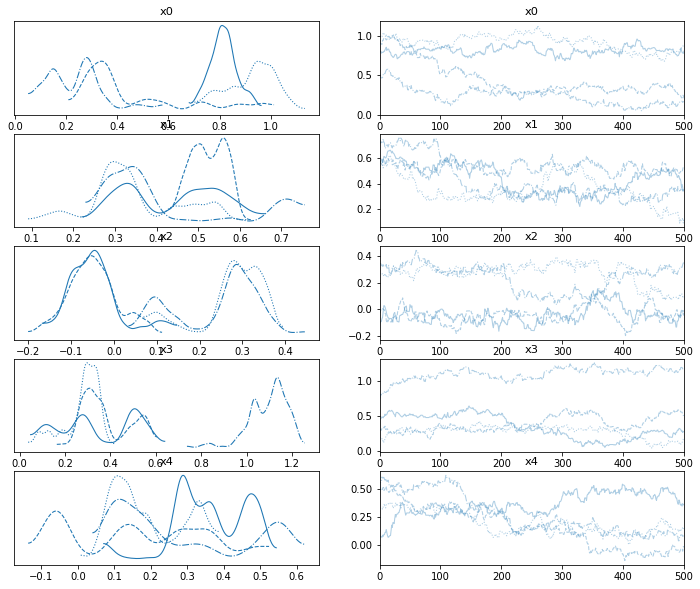

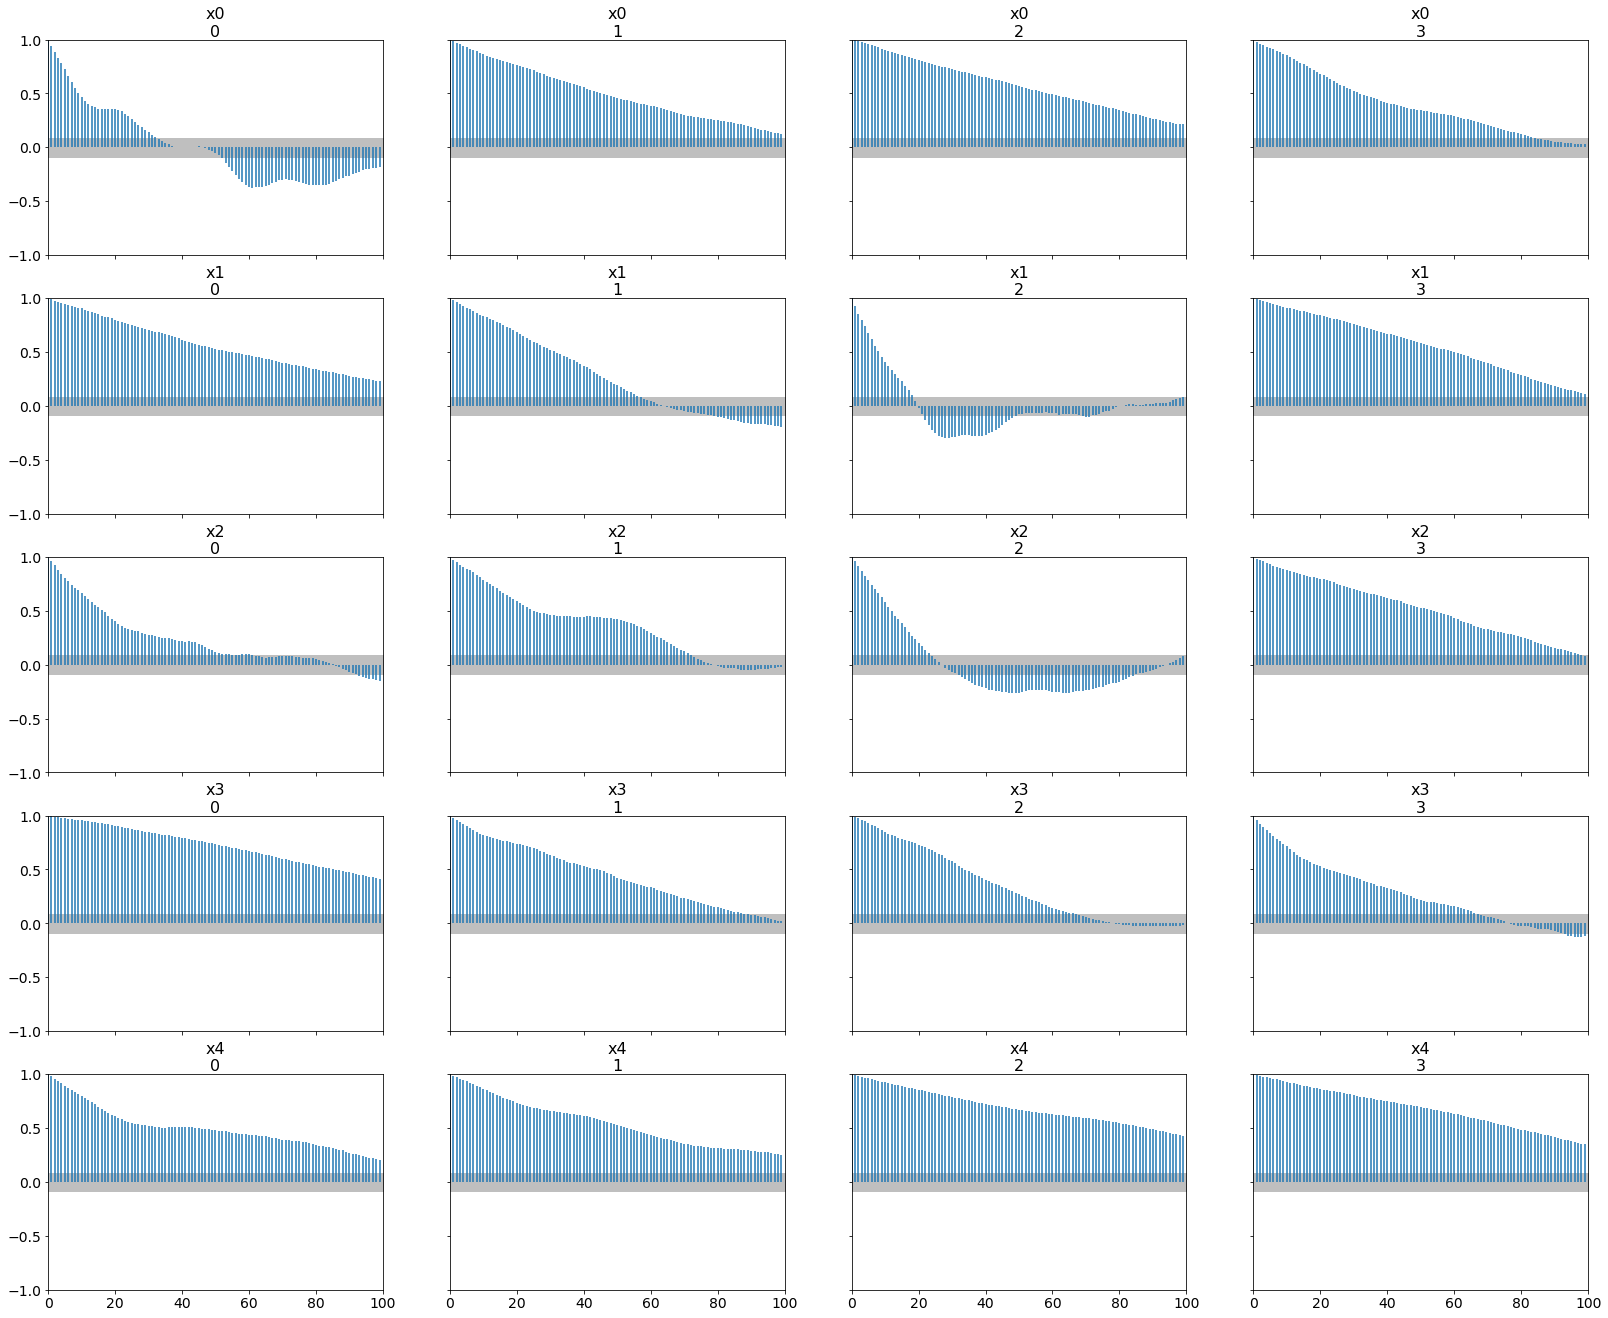

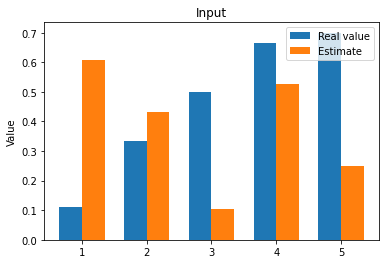

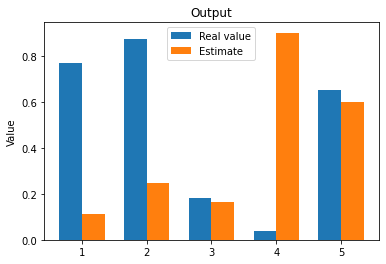

The function inverse took 823.0519914627075 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="CN")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.35: 100%|██████████| 1000/1000 [02:39<00:00,  6.27it/s]


Sampling chain 2/4


Running chain, α = 0.38: 100%|██████████| 1000/1000 [02:42<00:00,  6.14it/s]


Sampling chain 3/4


Running chain, α = 0.30: 100%|██████████| 1000/1000 [02:54<00:00,  5.72it/s]


Sampling chain 4/4


Running chain, α = 0.31: 100%|██████████| 1000/1000 [02:51<00:00,  5.84it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.24  0.076 0.268 0.243 0.181]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.240  0.332  -0.258    0.923      0.045    0.035      54.0      39.0   
x1  0.076  0.412  -0.844    0.792      0.127    0.092      12.0      42.0   
x2  0.268  0.380  -0.206    1.088      0.071    0.061      23.0      47.0   
x3  0.243  0.238  -0.096    0.747      0.029    0.022      72.0      51.0   
x4  0.181  0.321  -0.685    0.711      0.084    0.061      21.0      13.0   

    r_hat  
x0   1.05  
x1   1.25  
x2   1.13  
x3   1.02  
x4   1.14  
Autocorrelation...
[0.12766 0.257   0.232   0.422   0.519  ]


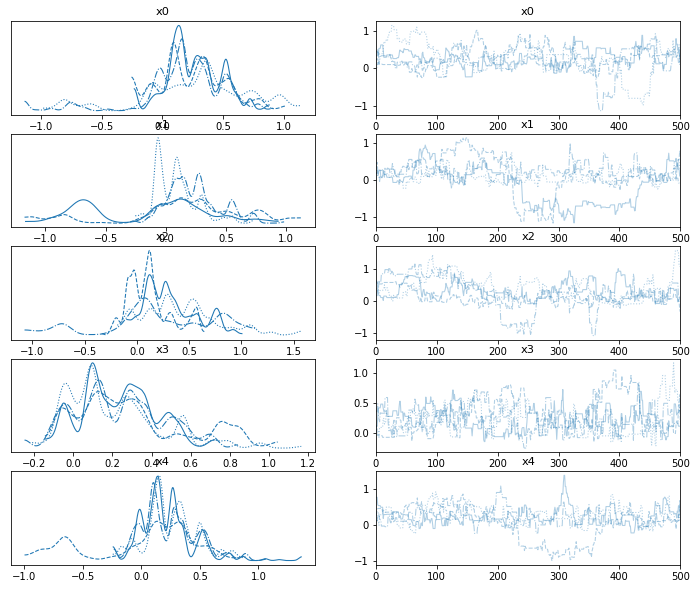

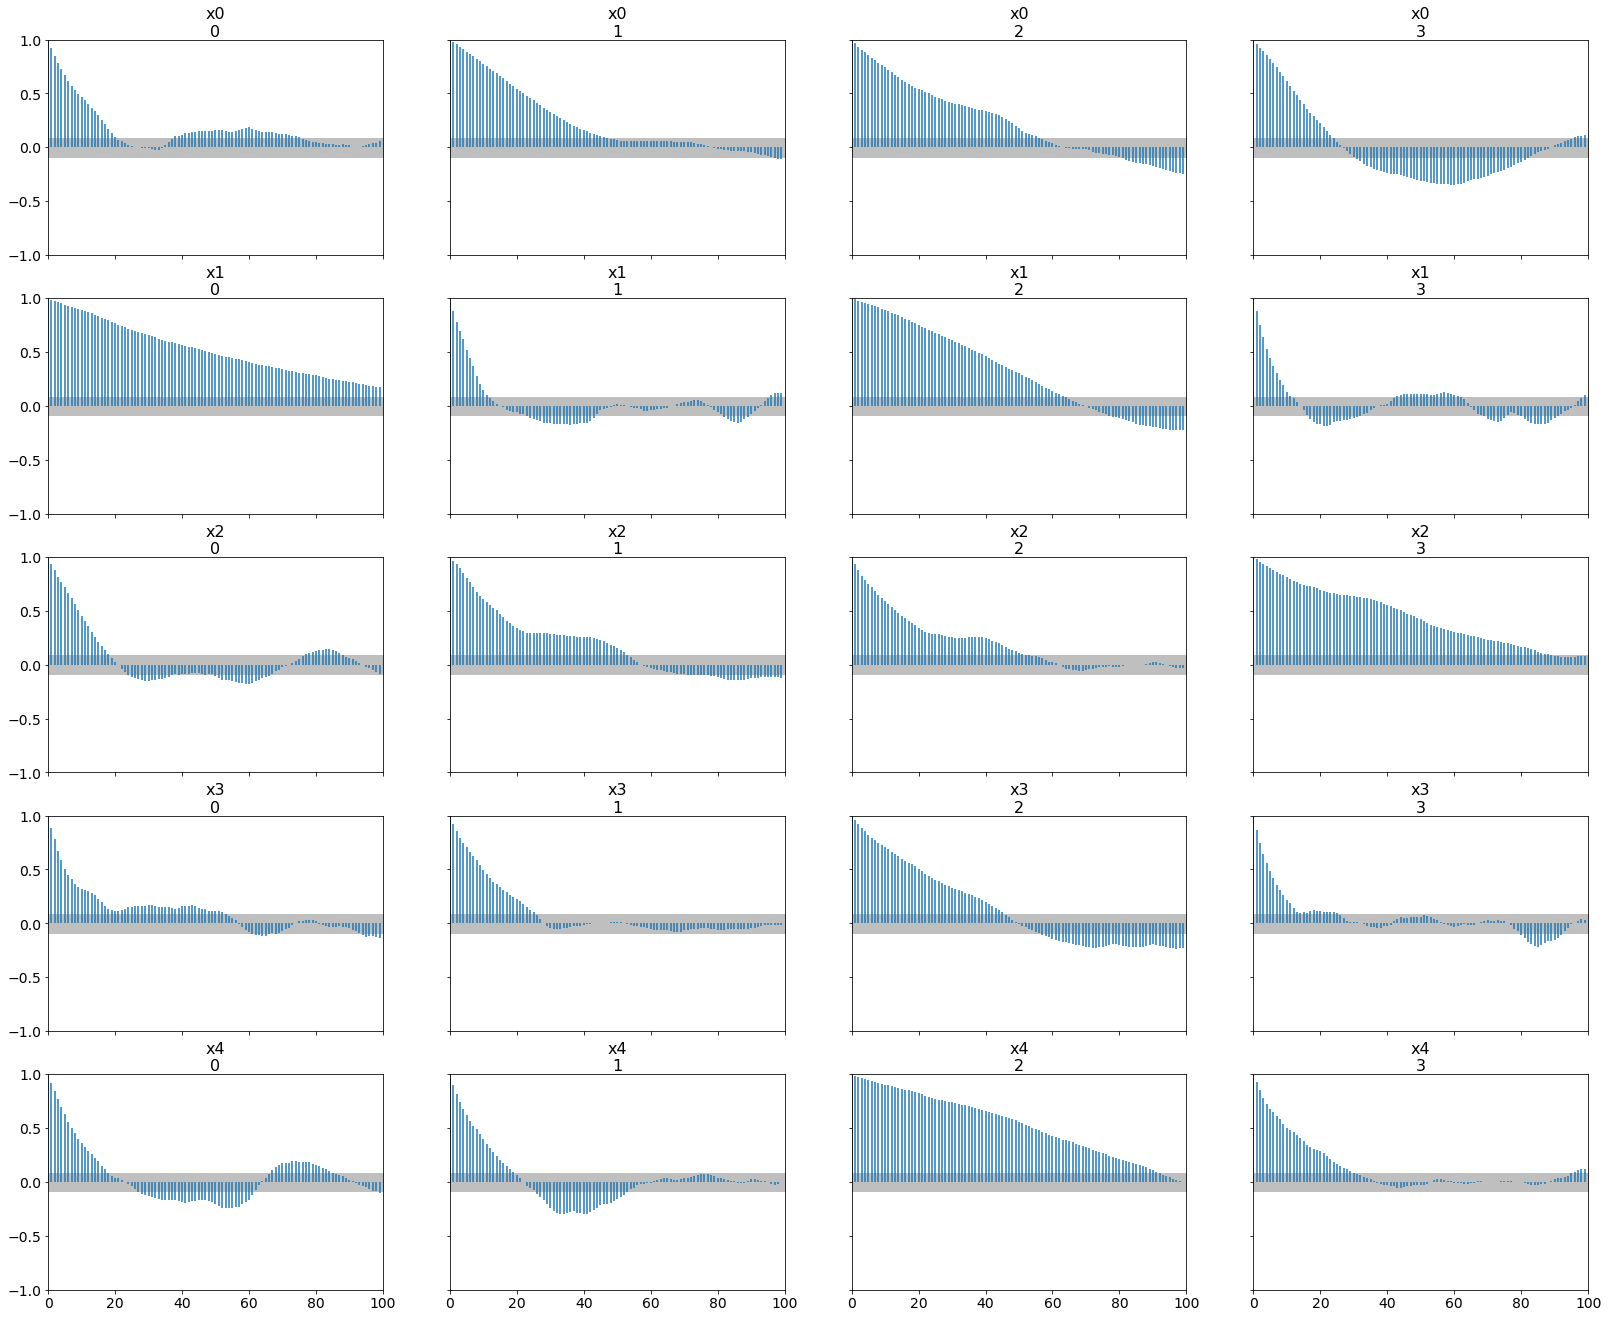

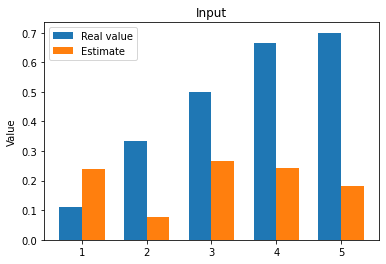

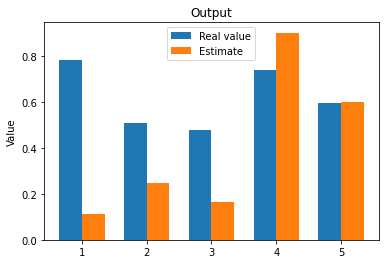

The function inverse took 735.5034279823303 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="CN")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.23: 100%|██████████| 1000/1000 [02:54<00:00,  5.74it/s]


Sampling chain 2/4


Running chain, α = 0.23: 100%|██████████| 1000/1000 [02:59<00:00,  5.58it/s]


Sampling chain 3/4


Running chain, α = 0.21: 100%|██████████| 1000/1000 [02:54<00:00,  5.73it/s]


Sampling chain 4/4


Running chain, α = 0.17: 100%|██████████| 1000/1000 [02:50<00:00,  5.86it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.535 0.597 0.531 0.506 0.574]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.535  0.387  -0.076    1.233      0.044    0.031      78.0     104.0   
x1  0.597  0.372   0.078    1.390      0.048    0.041      62.0      69.0   
x2  0.531  0.358  -0.087    1.147      0.037    0.026      92.0     165.0   
x3  0.506  0.414  -0.083    1.273      0.057    0.041      61.0      46.0   
x4  0.574  0.364  -0.094    1.174      0.039    0.029      88.0      96.0   

    r_hat  
x0   1.05  
x1   1.08  
x2   1.08  
x3   1.07  
x4   1.04  
Autocorrelation...
[0.42266 0.264   0.031   0.159   0.126  ]


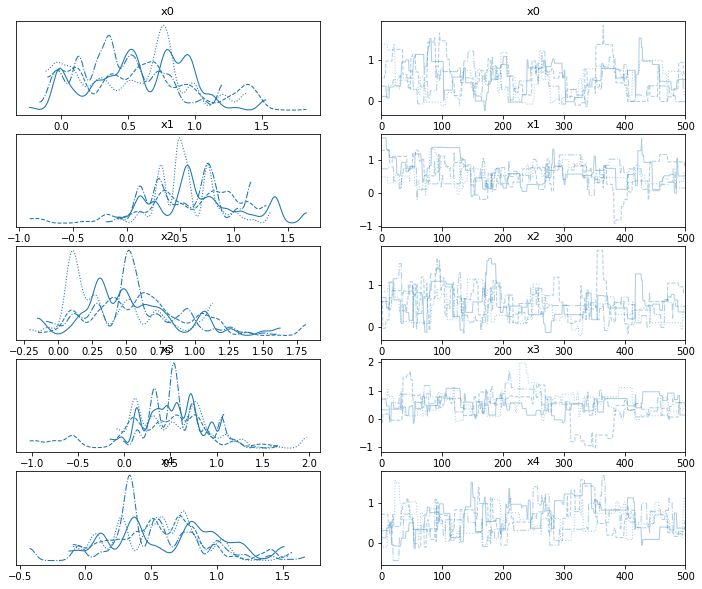

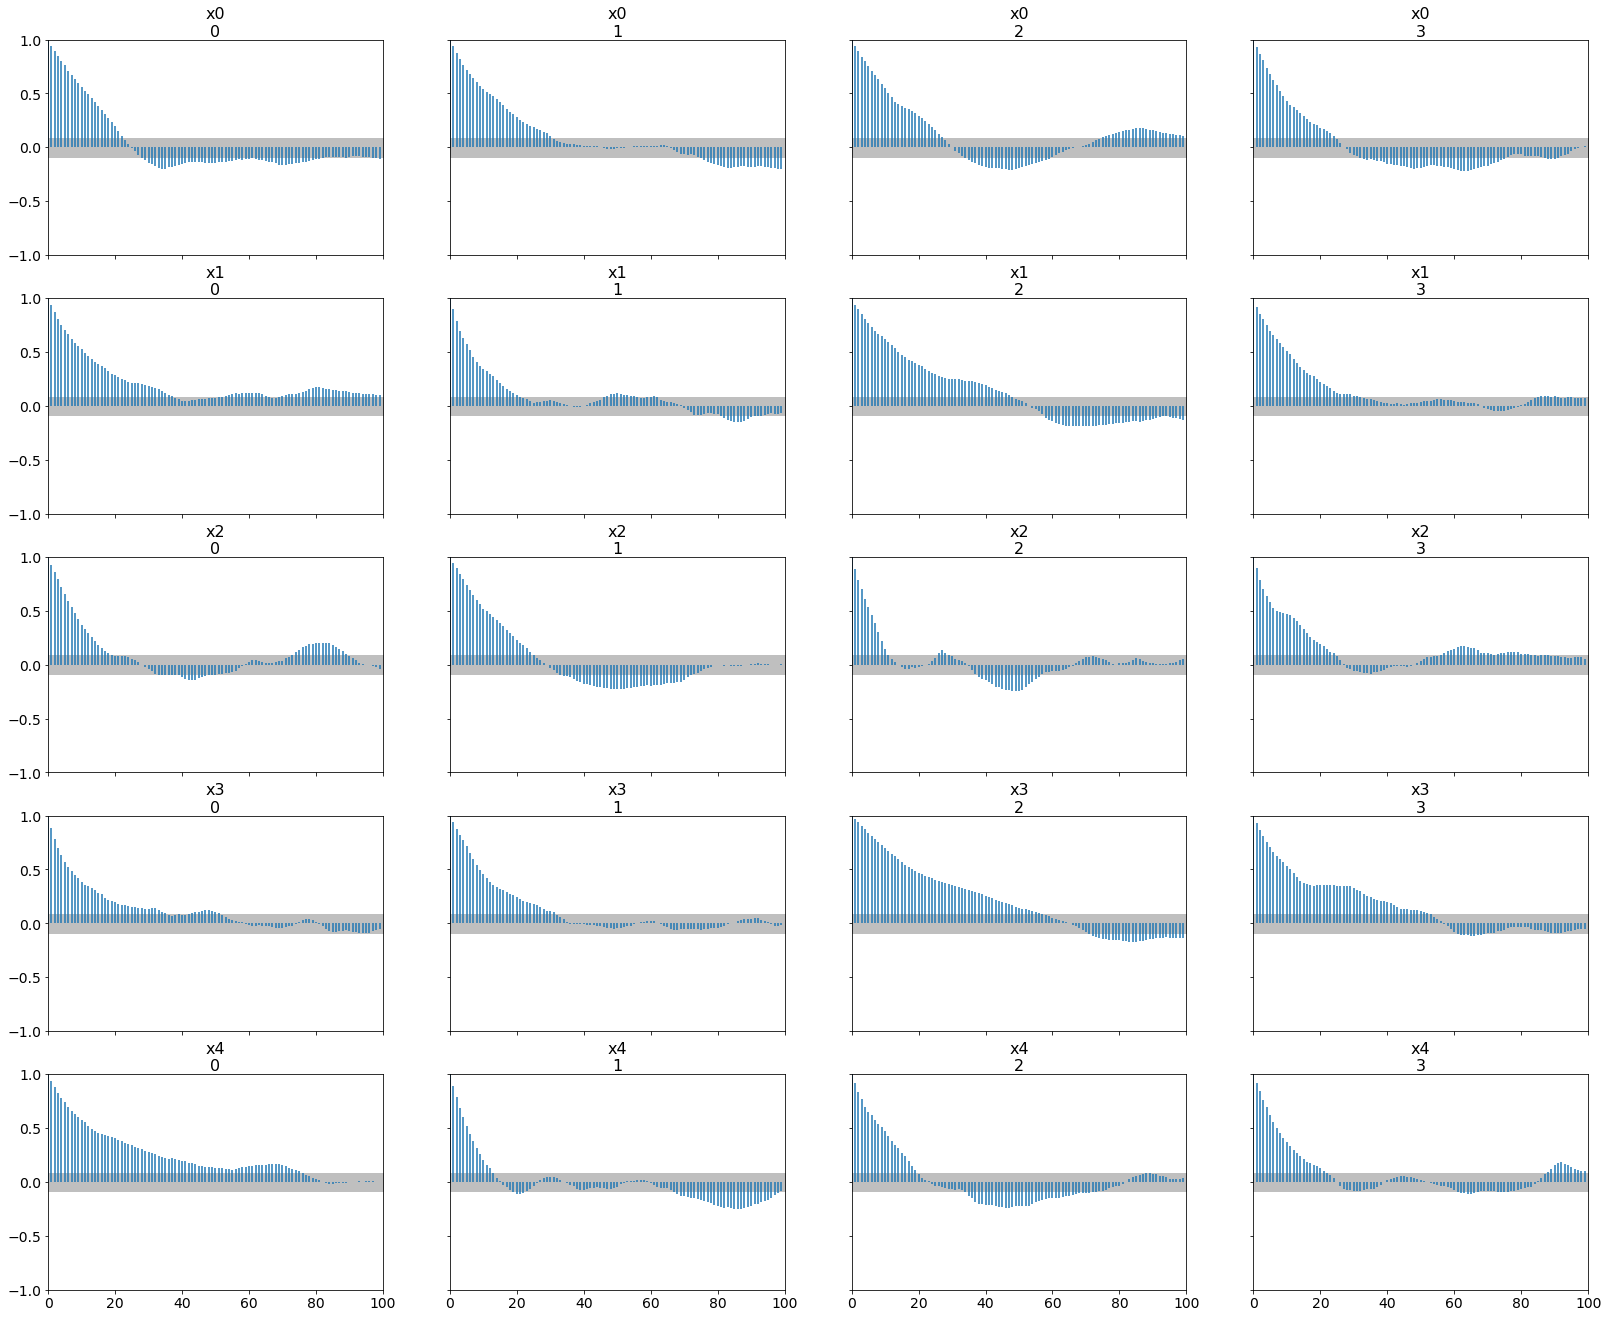

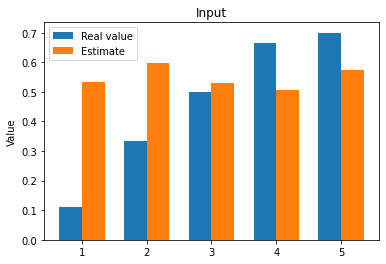

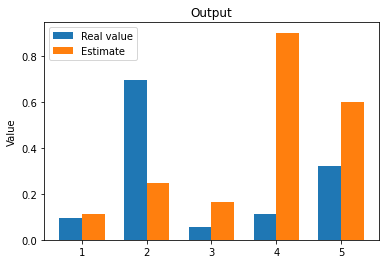

The function inverse took 767.4292497634888 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="DREAMZ")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.26: 100%|██████████| 1000/1000 [02:48<00:00,  5.95it/s]


Sampling chain 2/4


Running chain, α = 0.19: 100%|██████████| 1000/1000 [02:56<00:00,  5.67it/s]


Sampling chain 3/4


Running chain, α = 0.16: 100%|██████████| 1000/1000 [02:55<00:00,  5.69it/s]


Sampling chain 4/4


Running chain, α = 0.20: 100%|██████████| 1000/1000 [02:47<00:00,  5.98it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.545 0.531 0.545 0.586 0.509]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.545  0.369  -0.045    1.217      0.039    0.028      93.0     106.0   
x1  0.531  0.292   0.040    1.060      0.033    0.023      79.0      80.0   
x2  0.545  0.345  -0.058    1.151      0.041    0.029      74.0      59.0   
x3  0.586  0.382  -0.016    1.222      0.053    0.037      57.0      96.0   
x4  0.509  0.365   0.062    1.222      0.040    0.028      87.0      99.0   

    r_hat  
x0   1.02  
x1   1.05  
x2   1.04  
x3   1.08  
x4   1.06  
Autocorrelation...
[0.43266 0.198   0.045   0.079   0.191  ]


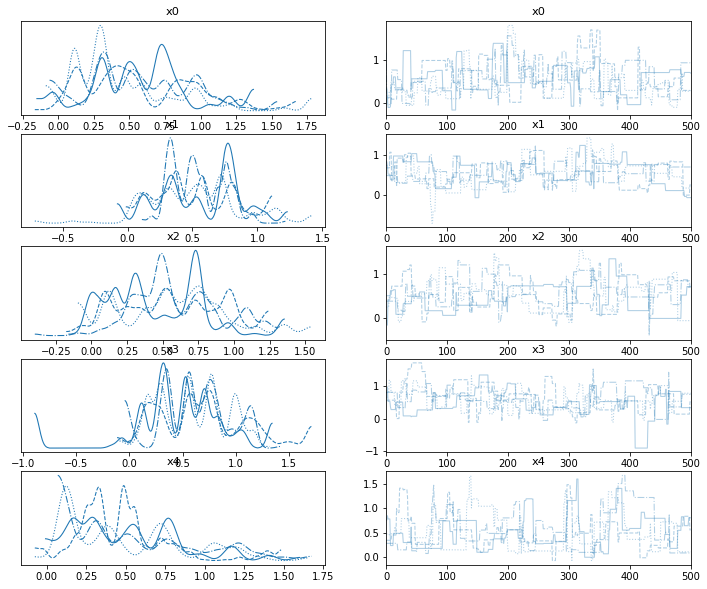

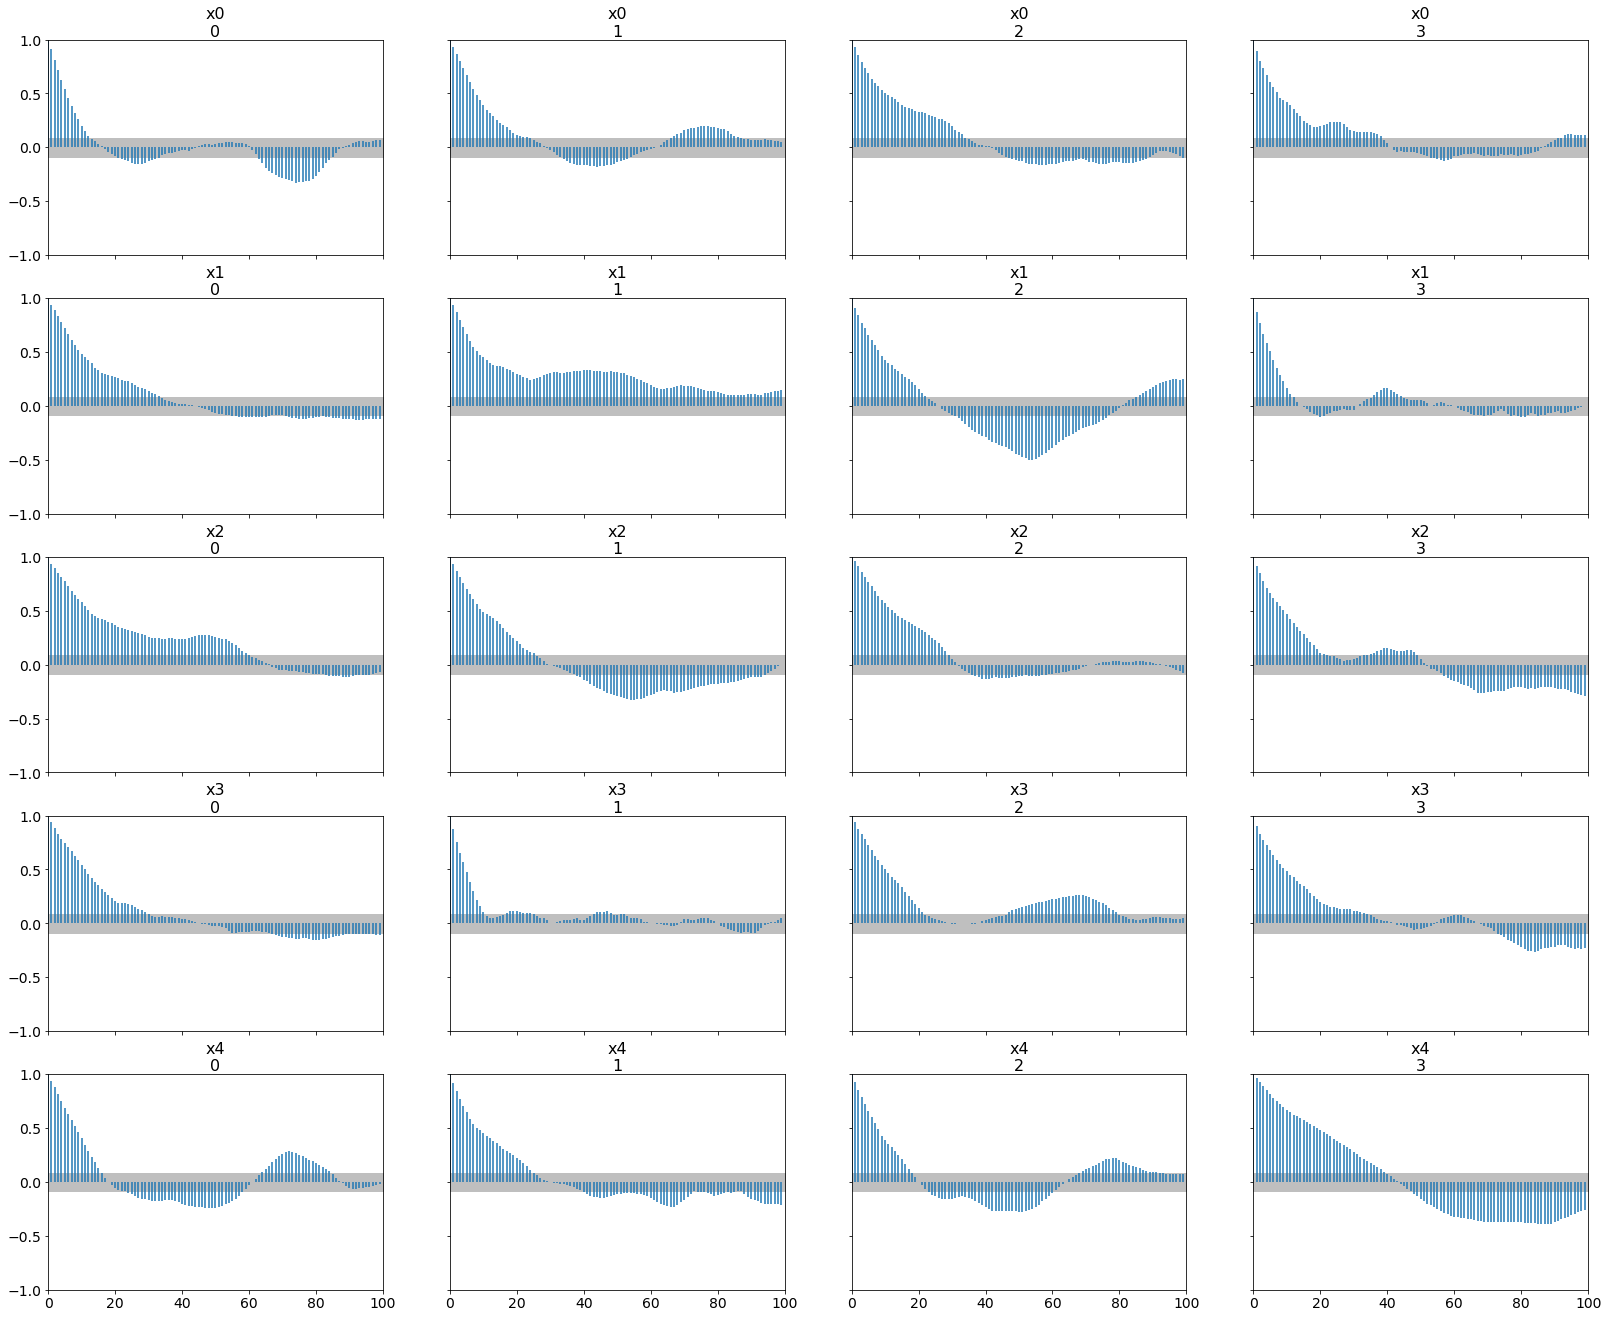

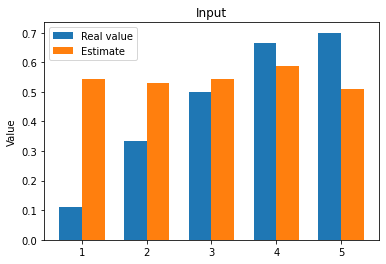

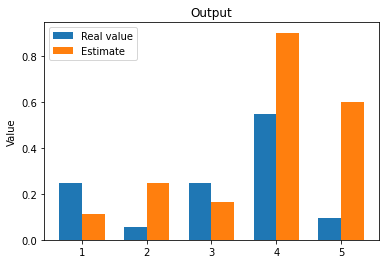

The function inverse took 780.7938289642334 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="DREAMZ")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 1.00:   0%|          | 0/1000 [00:00<?, ?it/s]

Running chain, α = 0.16: 100%|██████████| 1000/1000 [02:39<00:00,  6.28it/s]


Sampling chain 2/4


Running chain, α = 0.11: 100%|██████████| 1000/1000 [02:13<00:00,  7.49it/s]


...

Sampling chain 4/4


Running chain, α = 0.18: 100%|██████████| 1000/1000 [02:11<00:00,  7.59it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.503 0.484 0.465 0.618 0.439]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.503  0.243   0.116    0.828      0.106    0.080       6.0      11.0   
x1  0.484  0.206   0.104    0.804      0.096    0.075       5.0      24.0   
x2  0.465  0.101   0.286    0.581      0.040    0.030       8.0      78.0   
x3  0.618  0.296   0.096    1.097      0.145    0.111       4.0      13.0   
x4  0.439  0.173   0.089    0.734      0.074    0.055       6.0      14.0   

    r_hat  
x0   1.93  
x1   2.23  
x2   1.43  
x3   3.61  
x4   1.71  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
[0.503 0.484 0.465 0.618 0.439]
[0.11234 0.333   0.5     0.665   0.7    ]


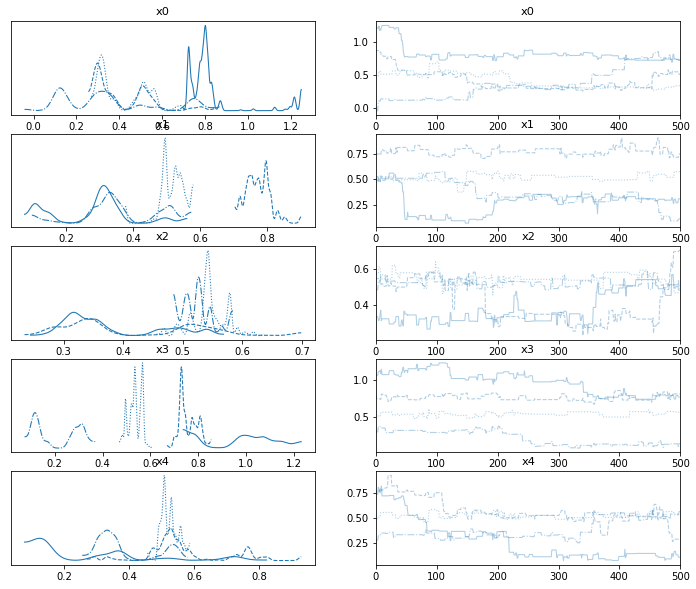

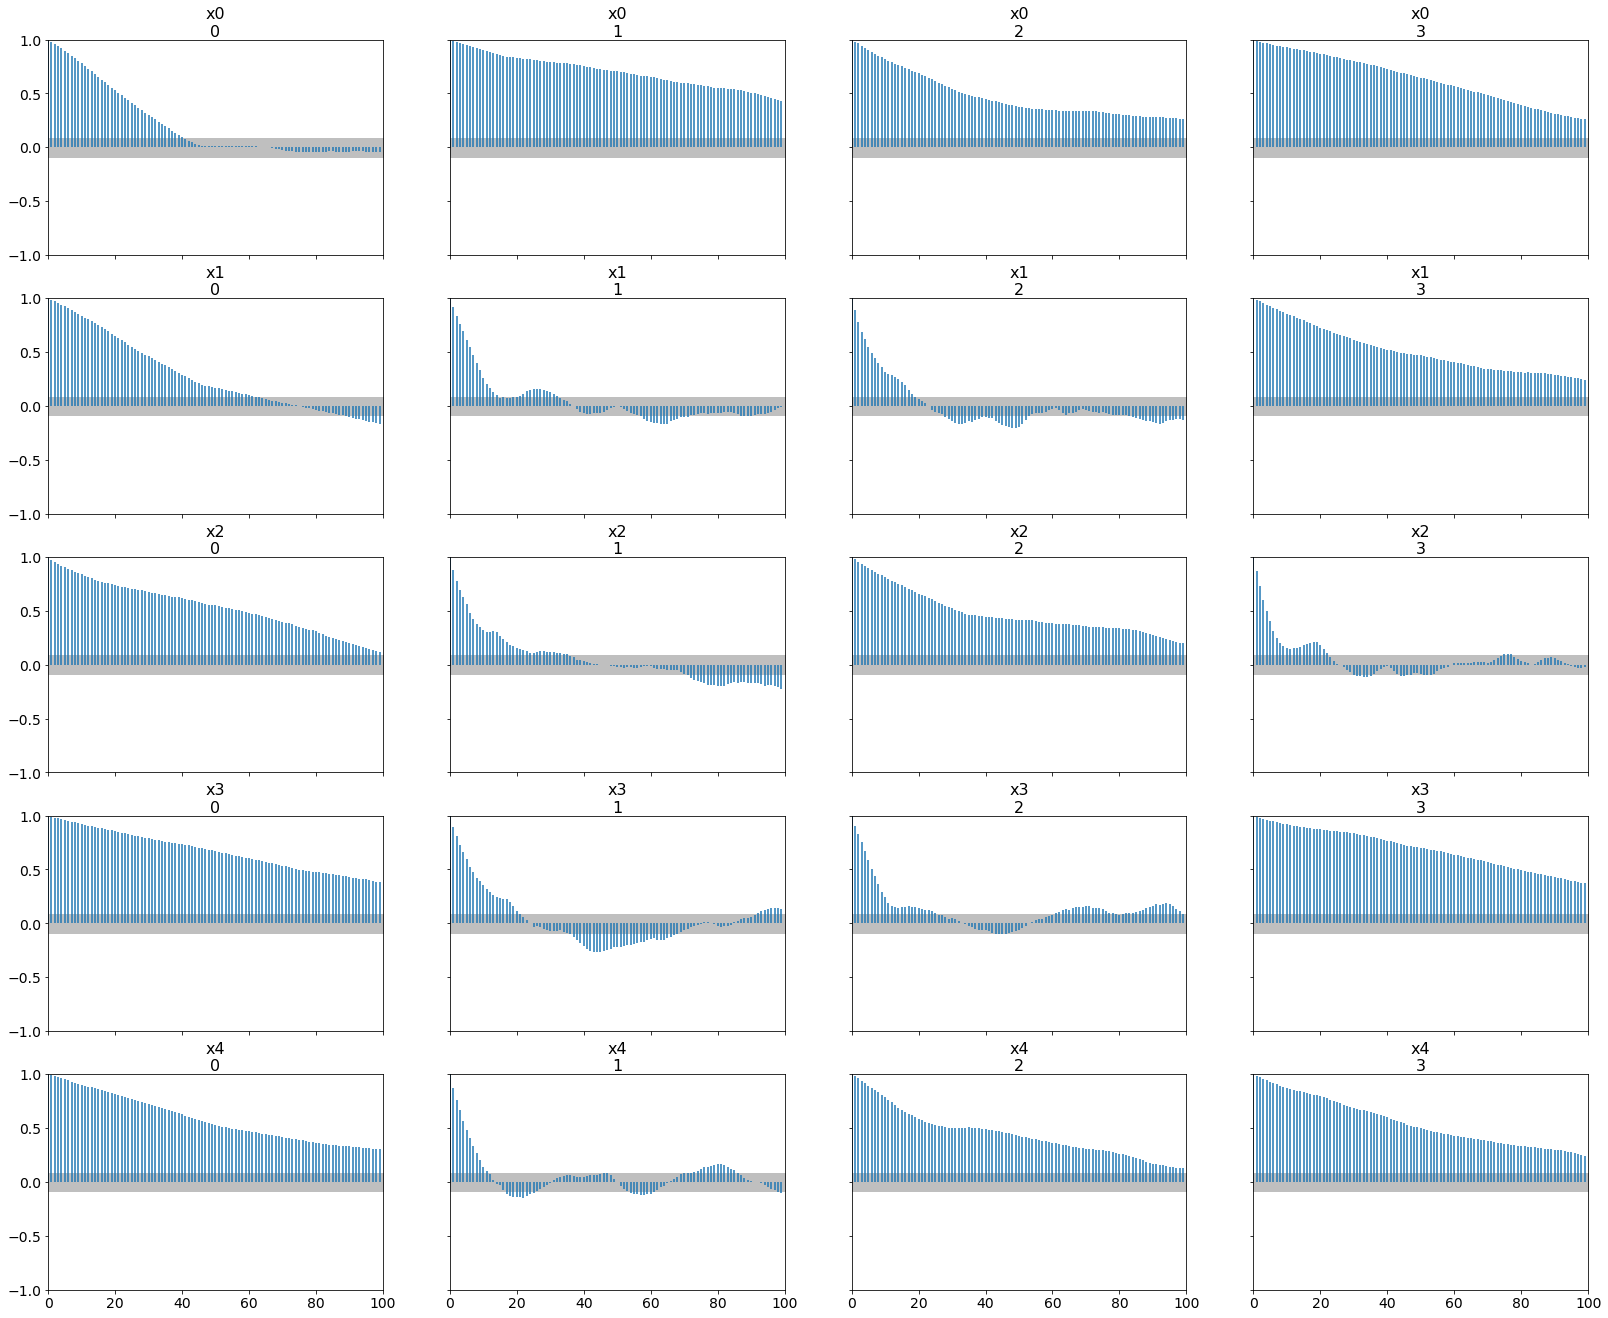

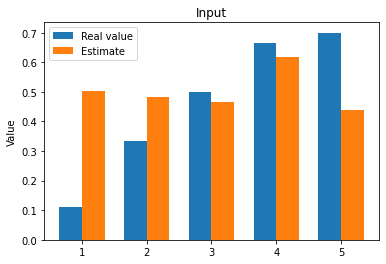

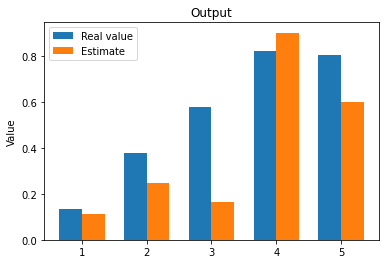

The function inverse took 562.0243139266968 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)
    

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.40: 100%|██████████| 3000/3000 [07:47<00:00,  6.41it/s]


Sampling chain 2/4


Running chain, α = 0.47: 100%|██████████| 3000/3000 [08:00<00:00,  6.24it/s]


Sampling chain 3/4


Running chain, α = 0.44: 100%|██████████| 3000/3000 [08:05<00:00,  6.18it/s]


Sampling chain 4/4


Running chain, α = 0.43: 100%|██████████| 3000/3000 [08:11<00:00,  6.10it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.51  0.457 0.579 0.475 0.662]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.510  0.329  -0.083    1.121      0.095    0.069      12.0      43.0   
x1  0.457  0.254  -0.070    0.847      0.043    0.031      36.0      61.0   
x2  0.579  0.313  -0.043    1.121      0.109    0.080       8.0      49.0   
x3  0.475  0.320  -0.060    1.089      0.068    0.056      25.0      43.0   
x4  0.662  0.343   0.074    1.340      0.137    0.106       7.0      14.0   

    r_hat  
x0   1.27  
x1   1.10  
x2   1.45  
x3   1.23  
x4   1.60  
Autocorrelation...
[0.51  0.457 0.579 0.475 0.662]
[0.11234 0.333   0.5     0.665   0.7    ]


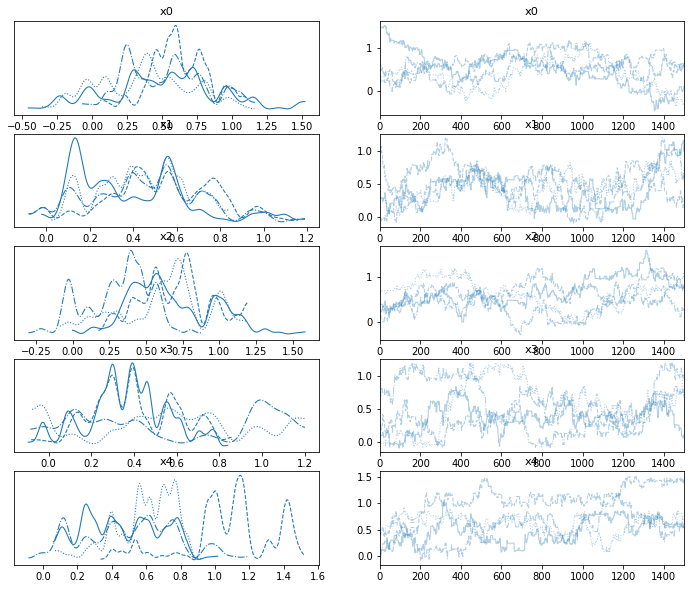

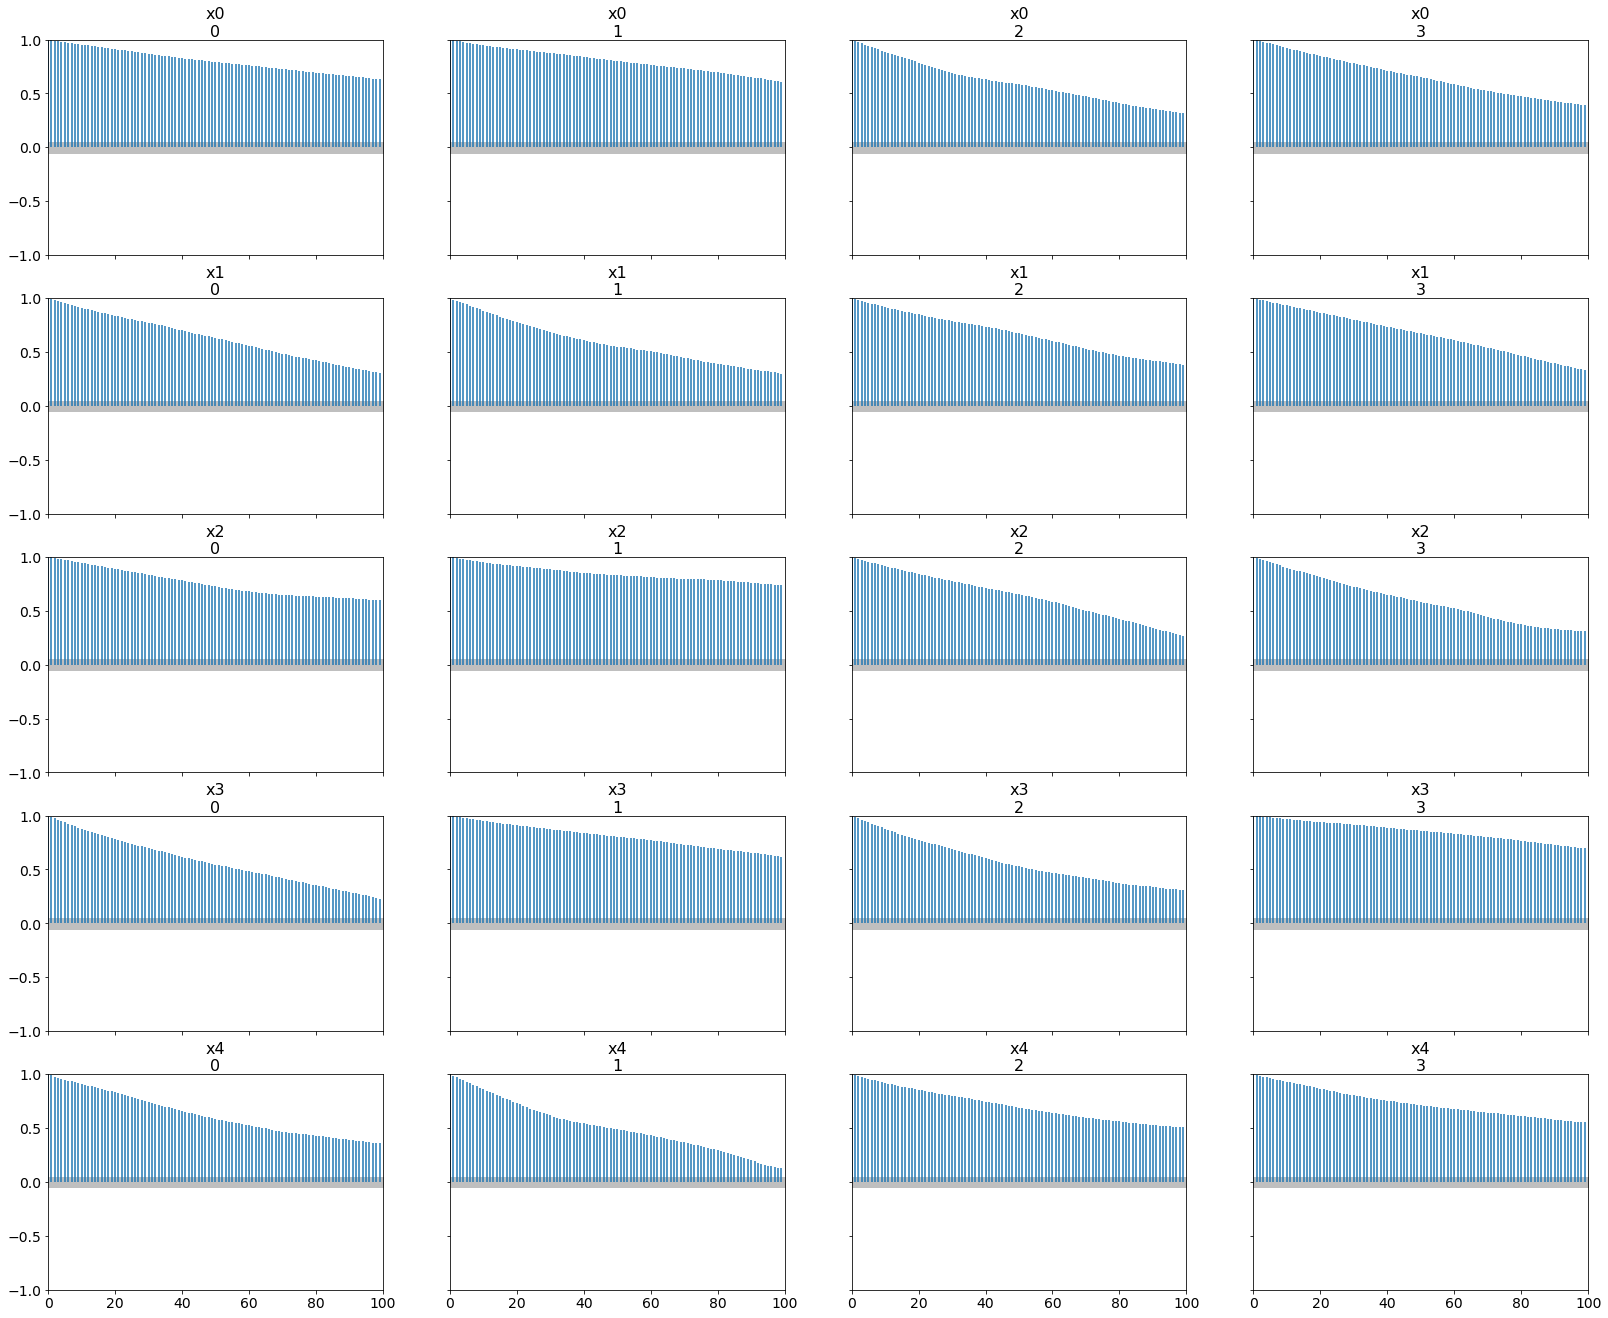

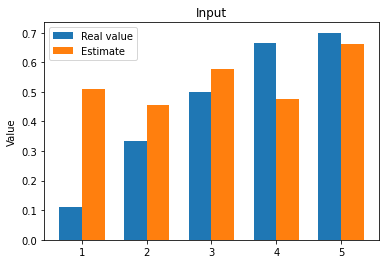

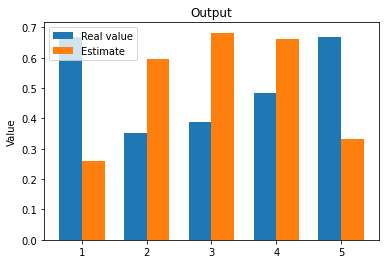

The function inverse took 1936.1948635578156 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
iterations=3000
burnin=1500
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)
    

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/10


Running chain, α = 0.05: 100%|██████████| 1000/1000 [02:49<00:00,  5.89it/s]


Sampling chain 2/10


Running chain, α = 0.17: 100%|██████████| 1000/1000 [02:44<00:00,  6.08it/s]


Sampling chain 3/10


...

Sampling chain 10/10


Running chain, α = 0.14: 100%|██████████| 1000/1000 [02:55<00:00,  5.70it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.571 0.541 0.489 0.651 0.484]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.571  0.286   0.091    1.021      0.085    0.062      12.0      21.0   
x1  0.541  0.427  -0.038    1.179      0.130    0.095      11.0      15.0   
x2  0.489  0.219   0.095    0.800      0.062    0.045      14.0      32.0   
x3  0.651  0.349   0.119    1.178      0.105    0.077      12.0      15.0   
x4  0.484  0.309  -0.069    1.078      0.094    0.068      11.0      13.0   

    r_hat  
x0   2.68  
x1   3.33  
x2   2.02  
x3   2.55  
x4   3.52  
Autocorrelation...


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\plots\plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (50) in plot_autocorr, generating only 40 plots
  warnings.warn(


[0.571 0.541 0.489 0.651 0.484]
[0.11234 0.333   0.5     0.665   0.7    ]


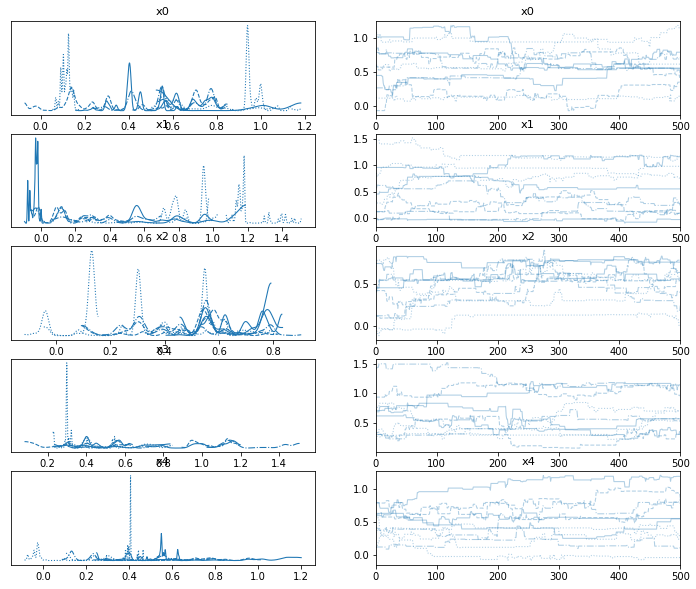

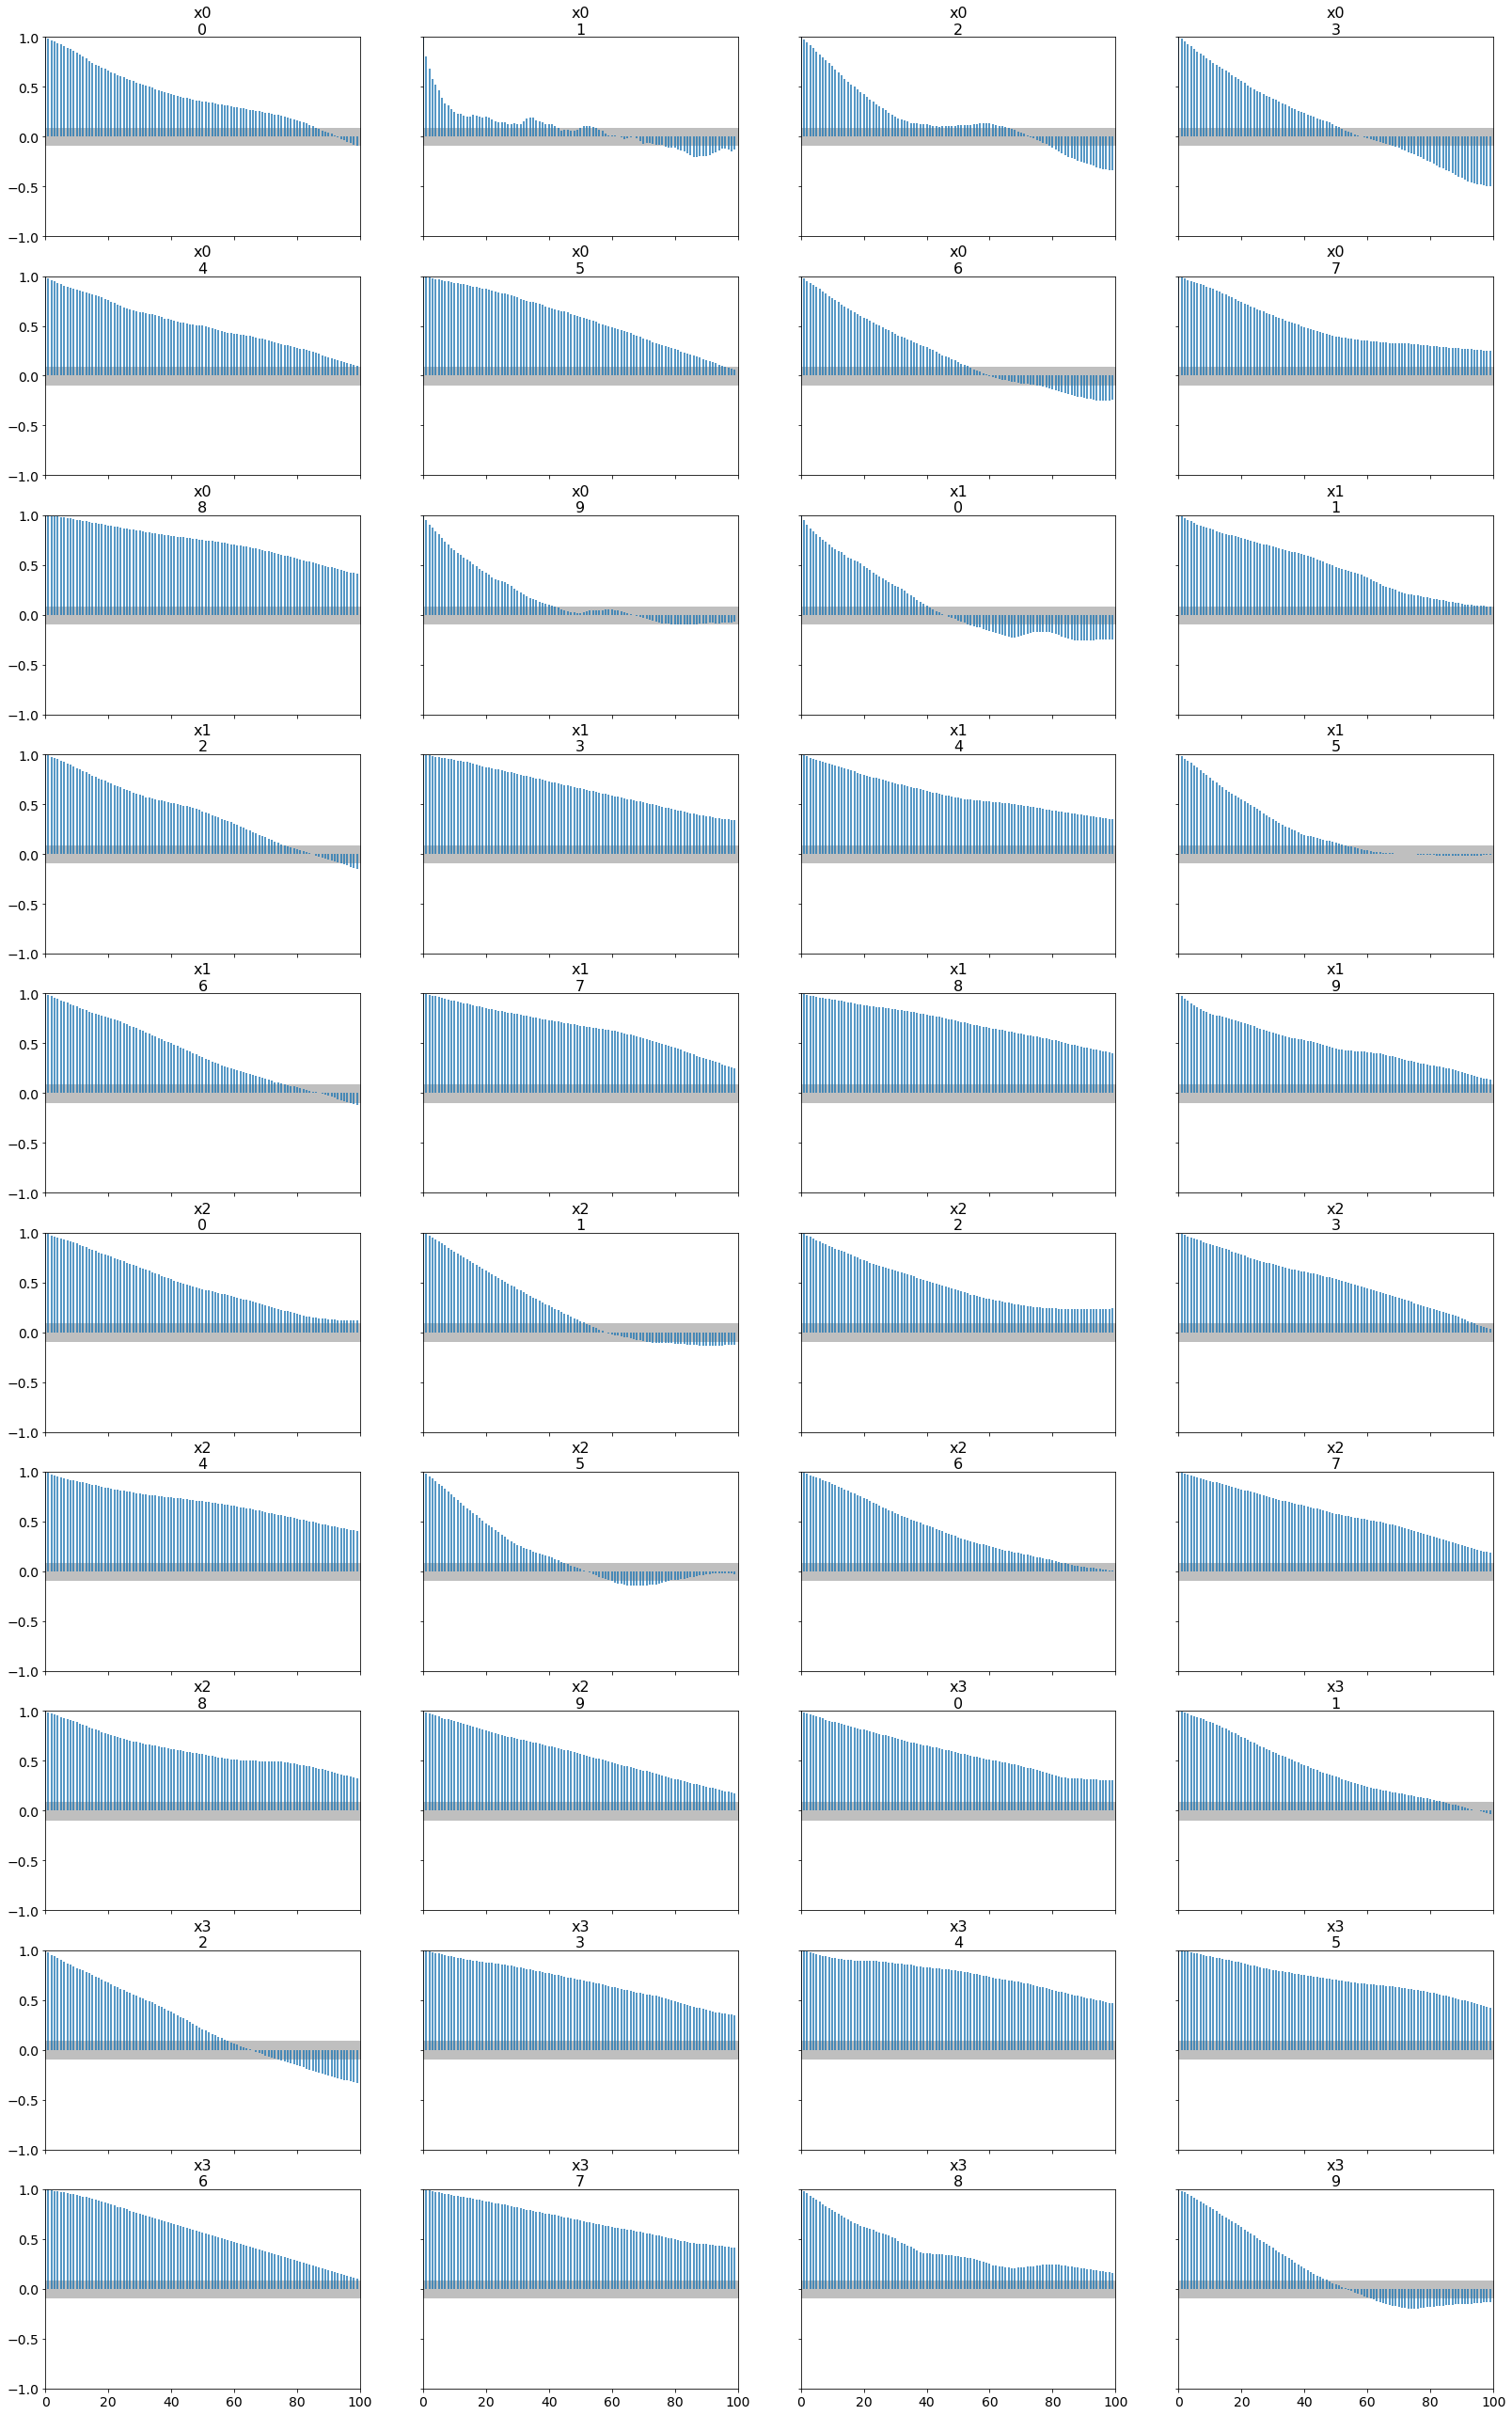

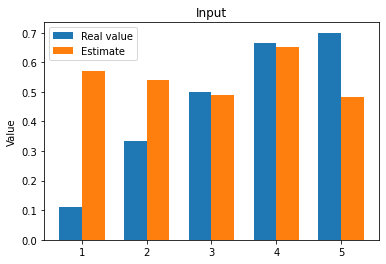

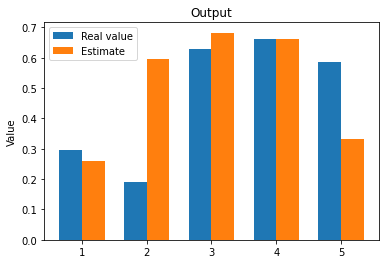

The function inverse took 1752.8812668323517 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
iterations=1000
burnin=500
n_chains=10
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.58: 100%|██████████| 1000/1000 [02:57<00:00,  5.63it/s]


Sampling chain 2/4


Running chain, α = 0.58: 100%|██████████| 1000/1000 [03:12<00:00,  5.21it/s]


Sampling chain 3/4


Running chain, α = 0.57: 100%|██████████| 1000/1000 [02:52<00:00,  5.79it/s]


Sampling chain 4/4


Running chain, α = 0.60: 100%|██████████| 1000/1000 [03:04<00:00,  5.43it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.294 0.765 0.449 0.75  0.307]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.294  0.739  -0.809    1.836      0.335    0.253       5.0      13.0   
x1  0.765  0.687  -0.614    2.124      0.312    0.236       5.0      17.0   
x2  0.449  0.409  -0.092    1.517      0.145    0.108       9.0      17.0   
x3  0.750  0.636  -0.084    2.051      0.289    0.218       5.0      18.0   
x4  0.307  0.394  -0.379    1.076      0.156    0.116       6.0      15.0   

    r_hat  
x0   2.19  
x1   2.37  
x2   1.42  
x3   2.12  
x4   1.68  
Autocorrelation...
[0.294 0.765 0.449 0.75  0.307]
[0.11234 0.333   0.5     0.665   0.7    ]


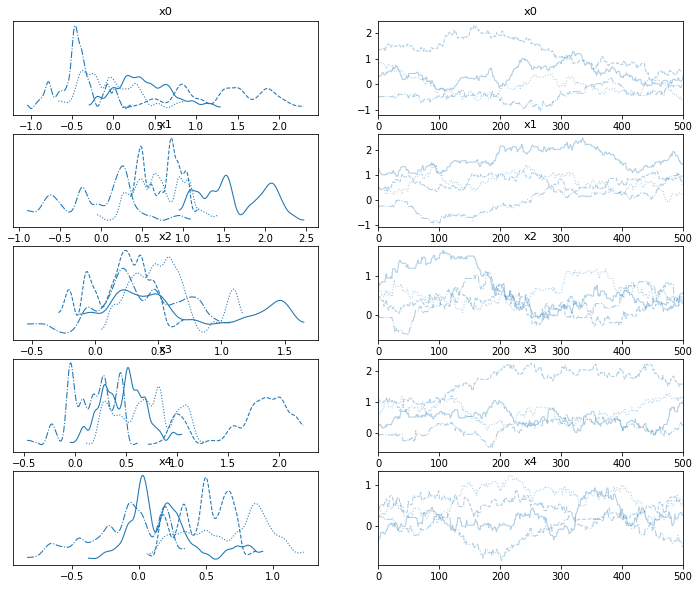

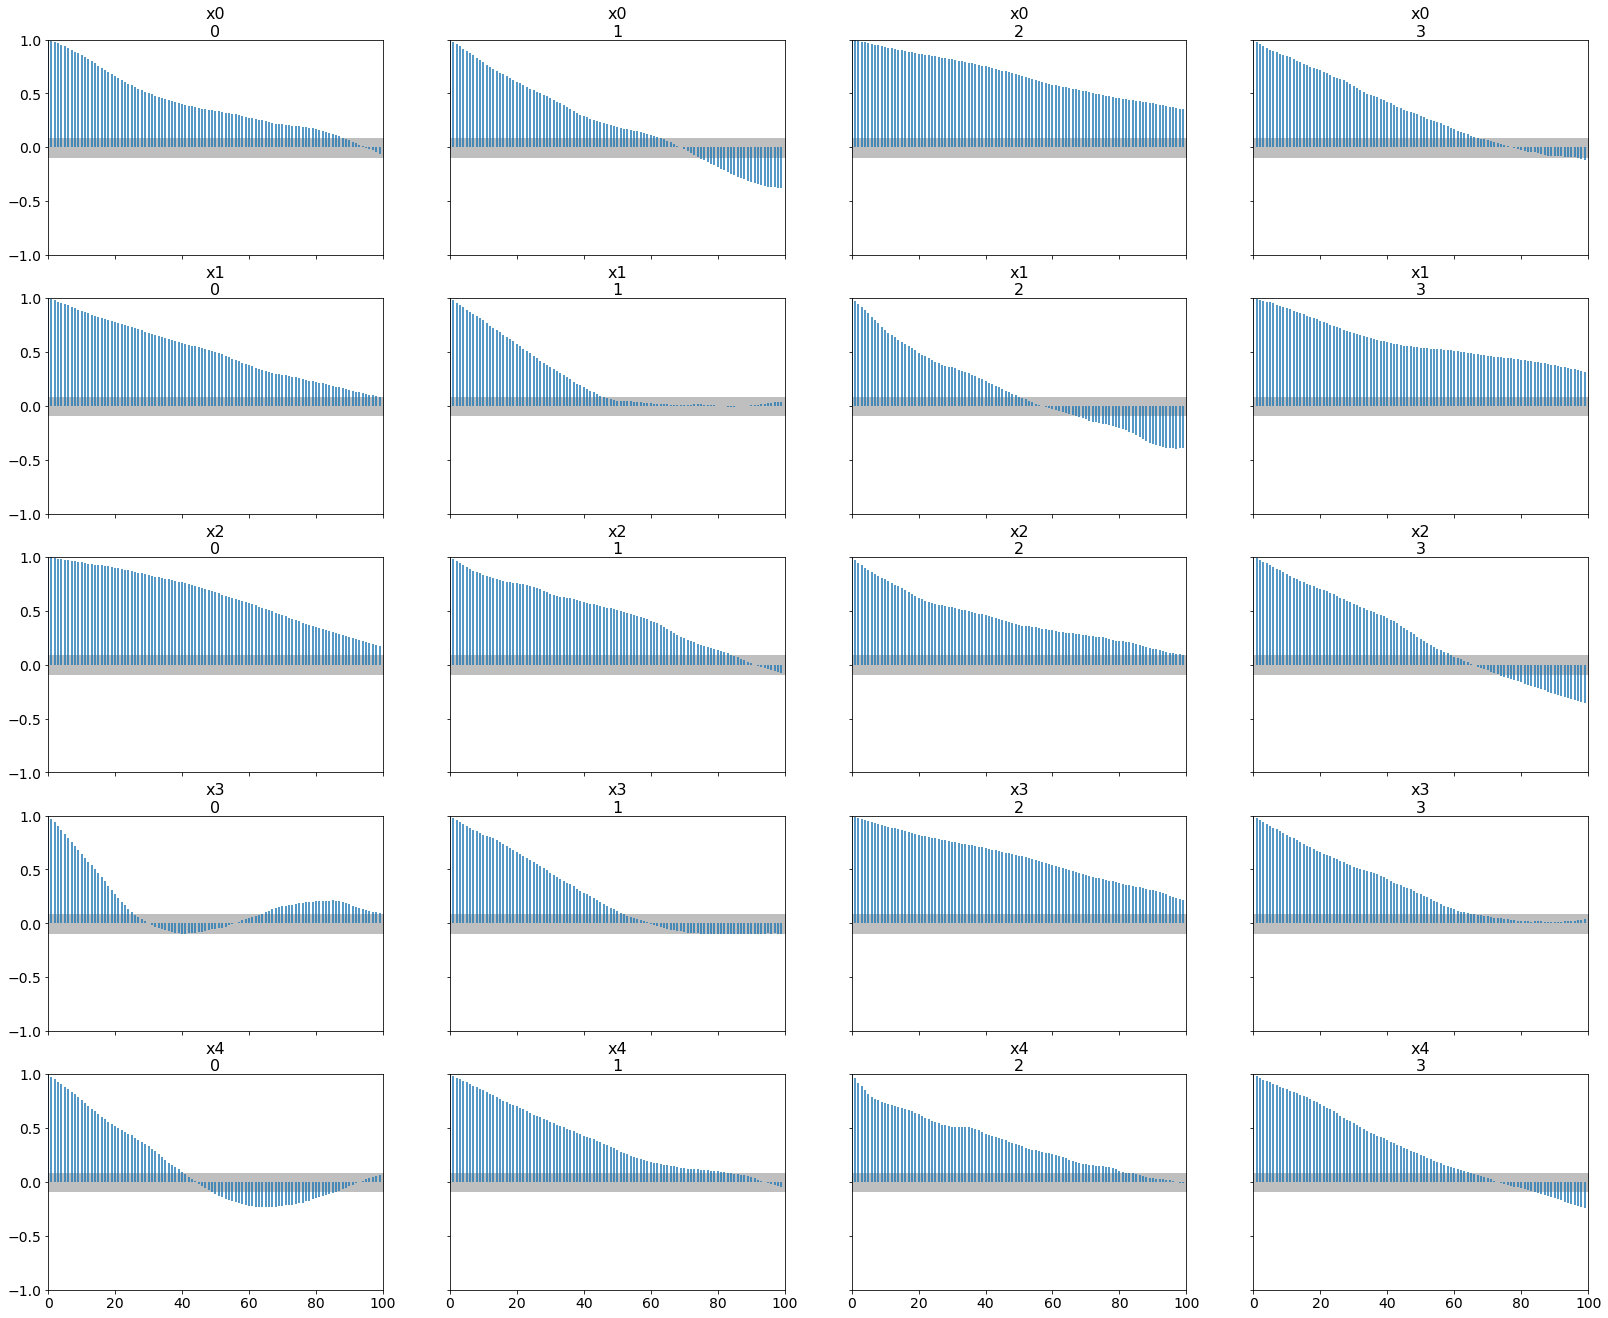

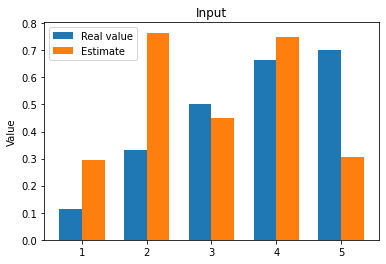

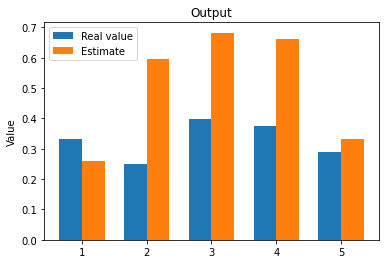

The function inverse took 732.2816848754883 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/6


Running chain, α = 0.32: 100%|██████████| 1500/1500 [03:32<00:00,  7.05it/s]


Sampling chain 2/6


Running chain, α = 0.55: 100%|██████████| 1500/1500 [03:40<00:00,  6.80it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.42: 100%|██████████| 1500/1500 [03:38<00:00,  6.88it/s]


Sampling chain 6/6


Running chain, α = 0.23: 100%|██████████| 1500/1500 [03:53<00:00,  6.42it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.684 0.235 0.521 0.209 0.67 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.684  0.367   0.063    1.237      0.119    0.087      10.0      25.0   
x1  0.235  0.582  -1.229    0.860      0.221    0.163      10.0      24.0   
x2  0.521  0.762  -1.079    1.552      0.300    0.222       7.0      21.0   
x3  0.209  0.570  -0.993    1.118      0.212    0.157      10.0      24.0   
x4  0.670  0.420  -0.098    1.310      0.151    0.111       8.0      35.0   

    r_hat  
x0   1.67  
x1   1.62  
x2   2.57  
x3   1.66  
x4   2.02  
Autocorrelation...
[0.684 0.235 0.521 0.209 0.67 ]
[0.11234 0.333   0.5     0.665   0.7    ]


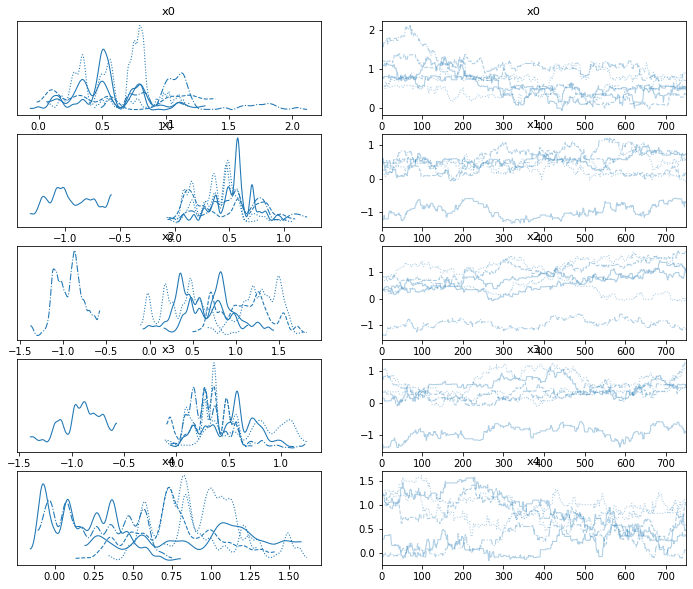

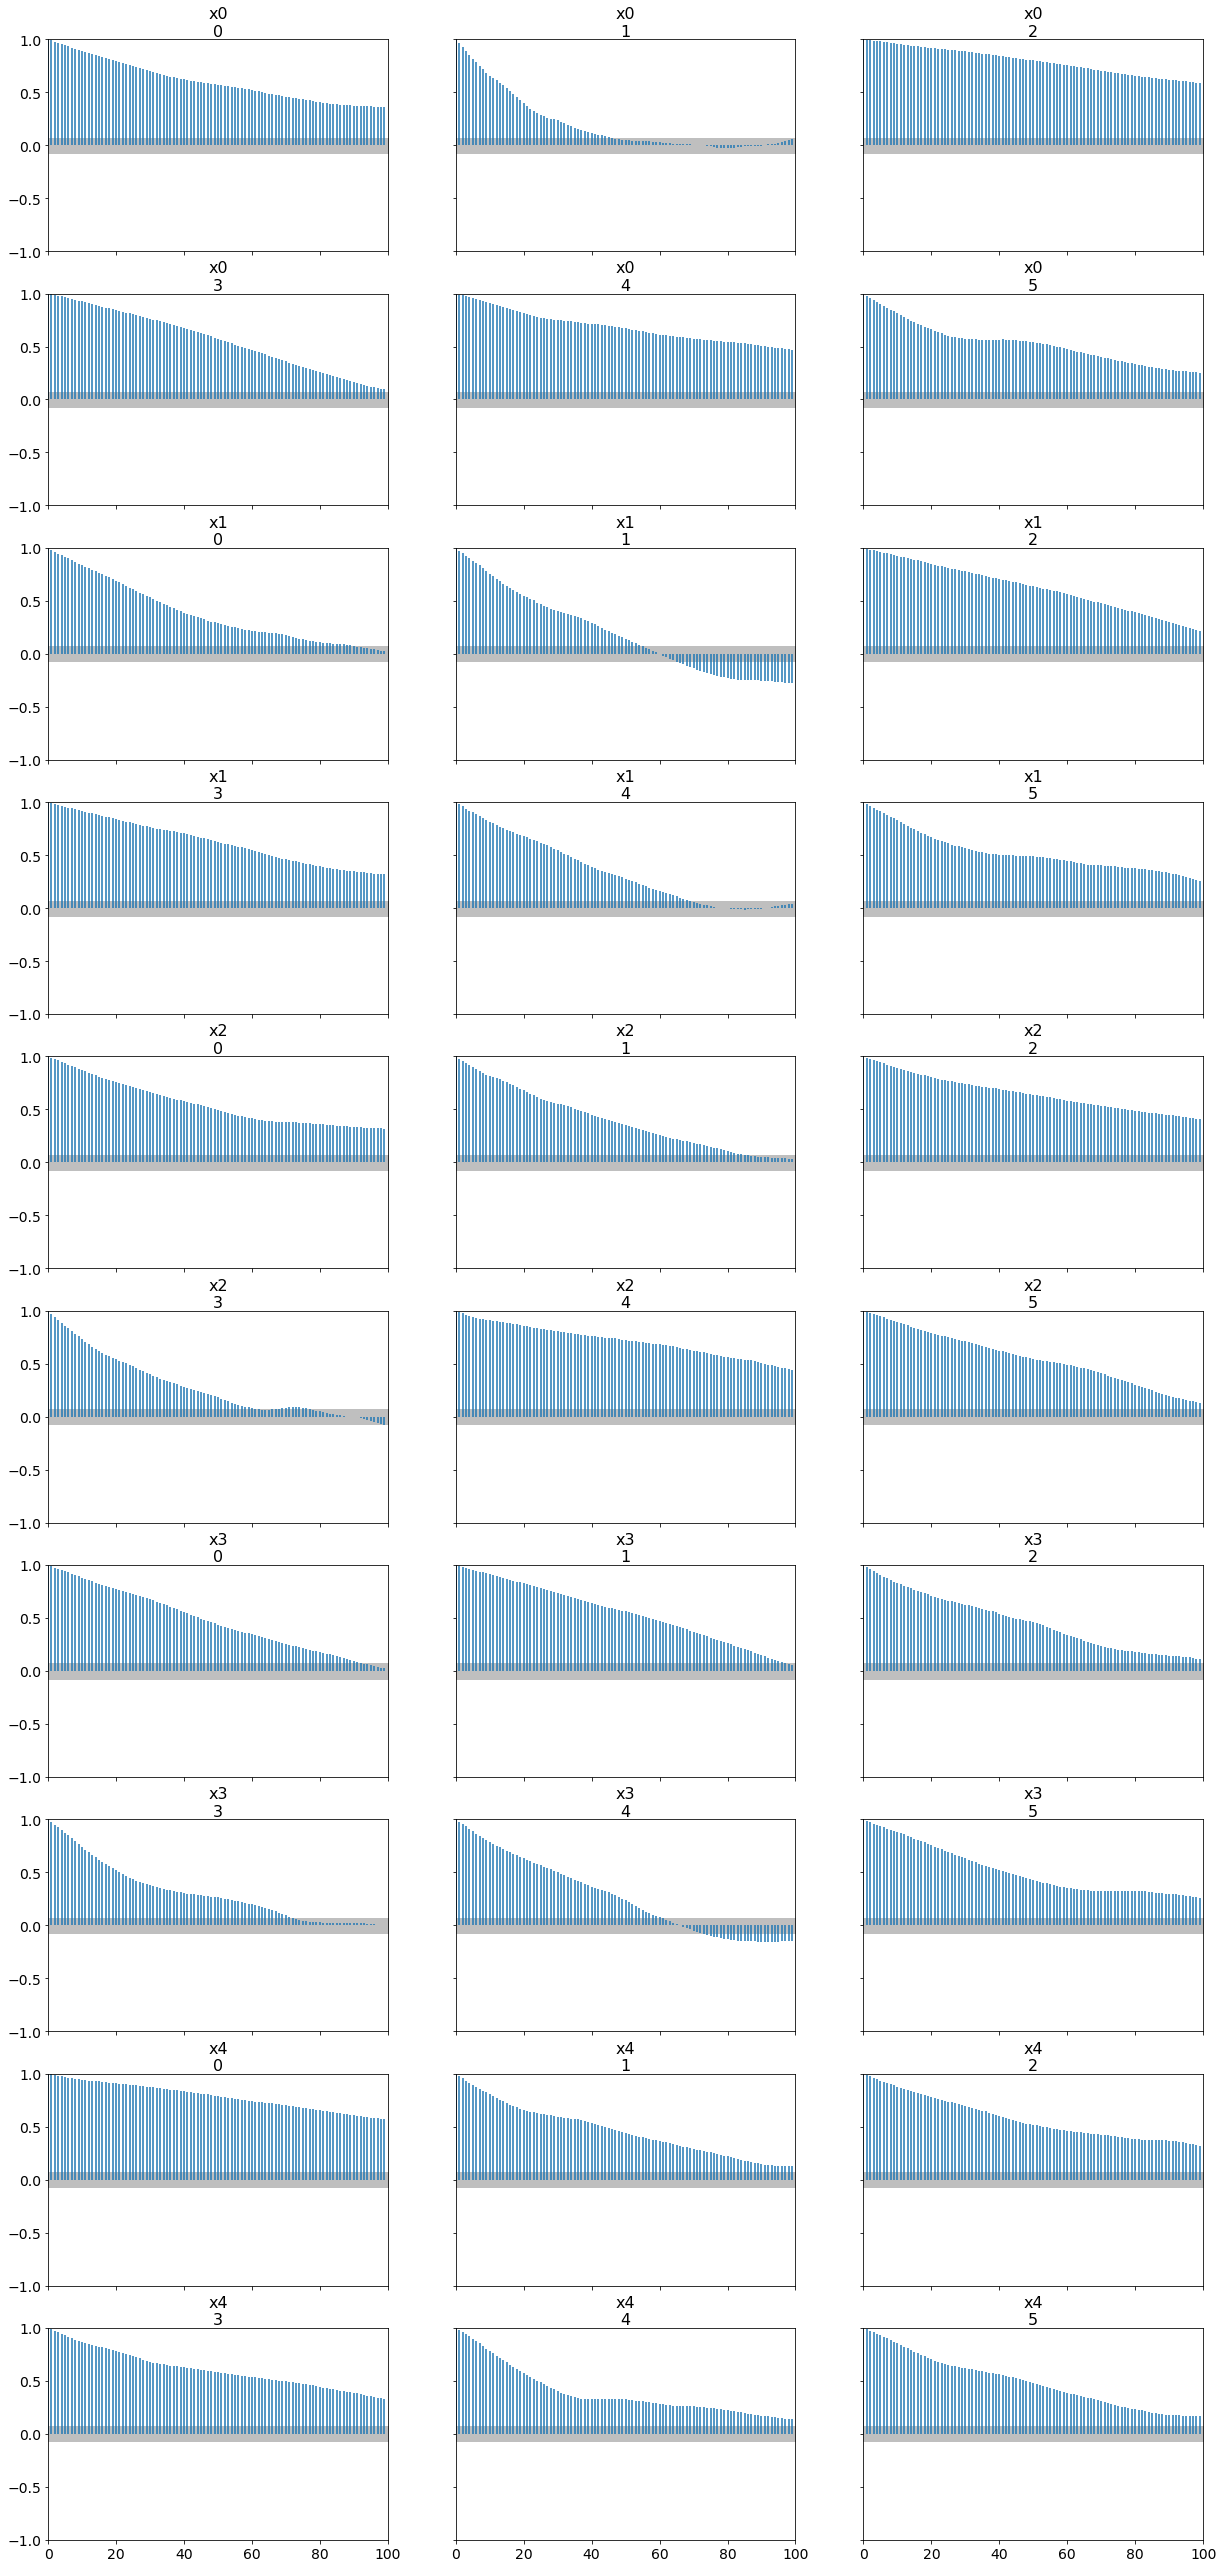

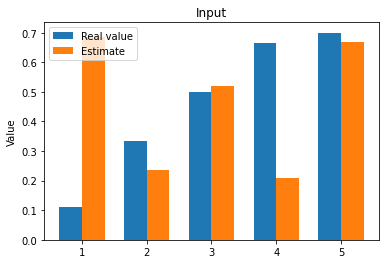

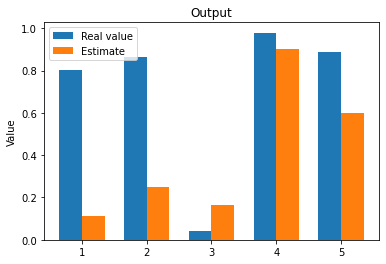

The function inverse took 1341.2048208713531 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*1.5 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1500#4000#8000
burnin=750#2000#4000
n_chains=6

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*2#*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.05 # covariance of the noise added to the known data
sigma_noise=0.05#*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*4 # covarianza della distribuzione di proposta!   <- elemento principale da regolare per modificare parametro di accettazione
rmwh_scaling = 0.1
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1500#4000#8000
burnin=750#2000#4000
n_chains=2
# alfa indica acceptance rejection, mi aspetto valori tra 0.3 e 0.5 che si riducano (mi sto avvicinando a valore vero, per cui prob piu alta)
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/2


Running chain, α = 0.00:  28%|██▊       | 421/1500 [01:11<03:02,  5.91it/s]


KeyboardInterrupt: 

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.75: 100%|██████████| 3000/3000 [07:24<00:00,  6.75it/s]


Sampling chain 2/4


Running chain, α = 0.64: 100%|██████████| 3000/3000 [07:07<00:00,  7.02it/s]


Sampling chain 3/4


...

Sampling chain 4/4


Running chain, α = 0.58: 100%|██████████| 3000/3000 [08:08<00:00,  6.15it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.39  0.434 0.243 0.506 0.562]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.390  0.278  -0.095    0.794      0.135    0.103       5.0      21.0   
x1  0.434  0.239   0.082    0.795      0.118    0.090       5.0      33.0   
x2  0.243  0.192  -0.071    0.547      0.092    0.070       5.0      18.0   
x3  0.506  0.356   0.069    1.098      0.174    0.133       5.0      13.0   
x4  0.562  0.208   0.257    0.826      0.099    0.075       5.0      60.0   

    r_hat  
x0   2.77  
x1   2.86  
x2   2.30  
x3   2.57  
x4   1.99  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
[0.39  0.434 0.243 0.506 0.562]
[0.11234 0.333   0.5     0.665   0.7    ]


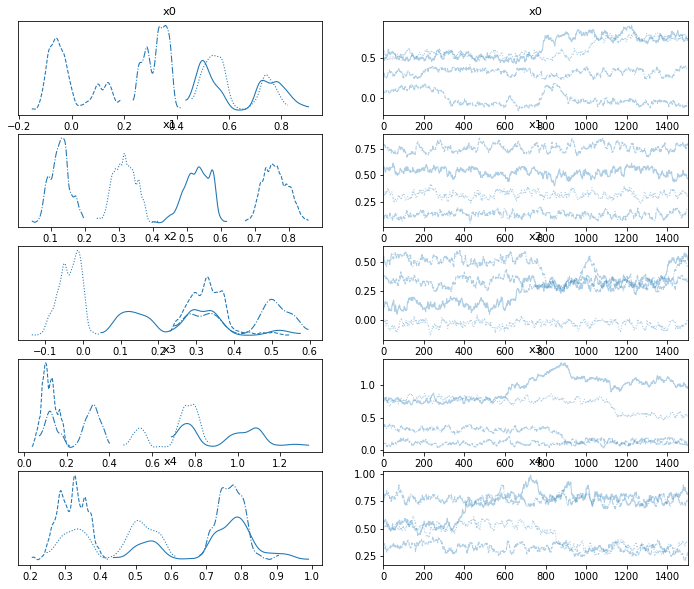

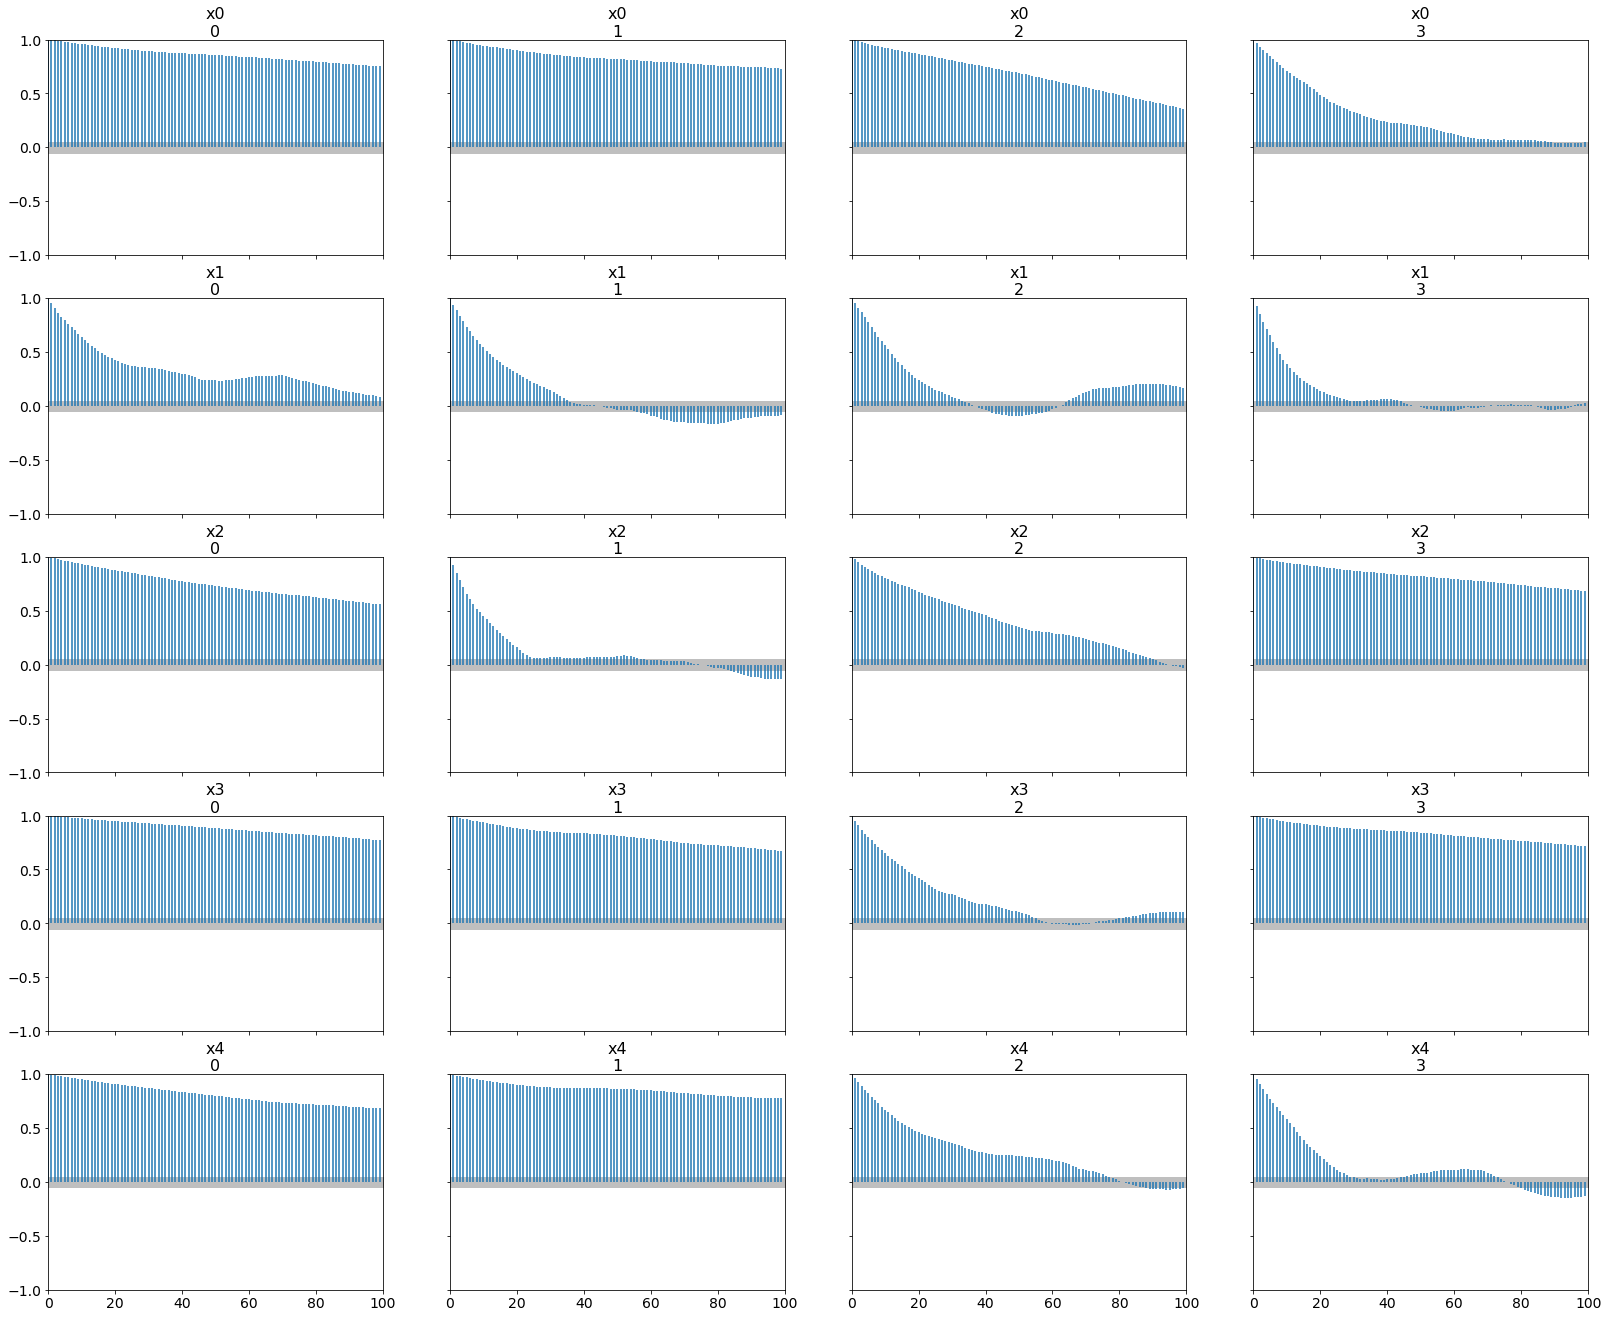

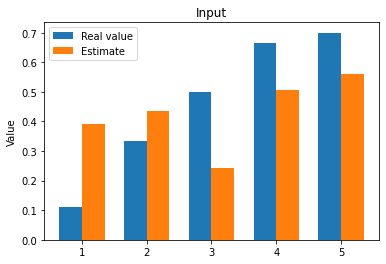

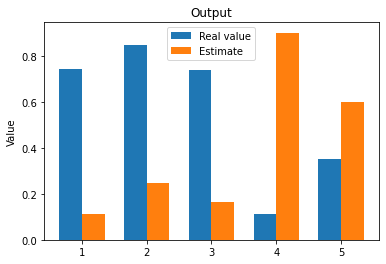

The function inverse took 1821.0441436767578 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=4
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

adaptive case
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.33: 100%|██████████| 3000/3000 [08:18<00:00,  6.02it/s]


Sampling chain 2/4


Running chain, α = 0.29: 100%|██████████| 3000/3000 [08:07<00:00,  6.15it/s]


Sampling chain 3/4


Running chain, α = 0.33: 100%|██████████| 3000/3000 [09:29<00:00,  5.27it/s]  


Sampling chain 4/4


Running chain, α = 0.25: 100%|██████████| 3000/3000 [07:44<00:00,  6.46it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.55  0.597 0.566 0.594 0.602]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.550  0.335  -0.092    1.115      0.022    0.015     242.0     395.0   
x1  0.597  0.364  -0.066    1.191      0.026    0.018     205.0     265.0   
x2  0.566  0.375  -0.039    1.225      0.028    0.020     181.0     410.0   
x3  0.594  0.381  -0.071    1.280      0.033    0.023     139.0     328.0   
x4  0.602  0.374   0.048    1.287      0.032    0.023     138.0     380.0   

    r_hat  
x0   1.01  
x1   1.02  
x2   1.03  
x3   1.03  
x4   1.03  
Autocorrelation...
[0.55  0.597 0.566 0.594 0.602]
[0.11234 0.333   0.5     0.665   0.7    ]


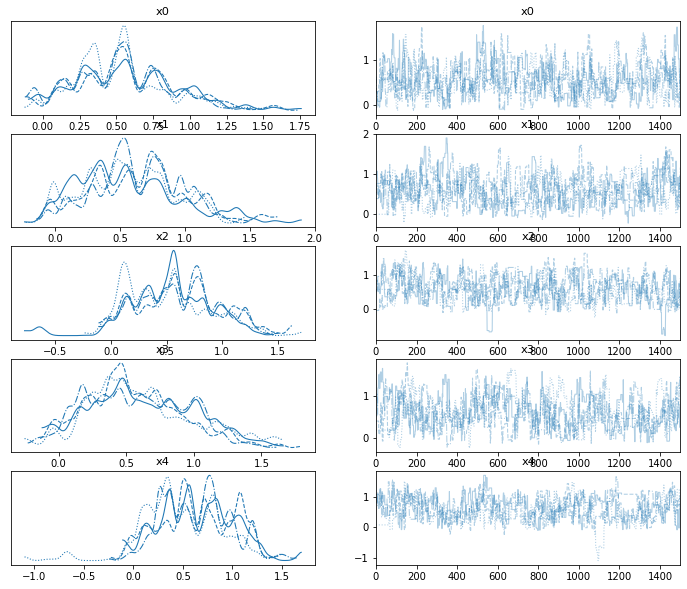

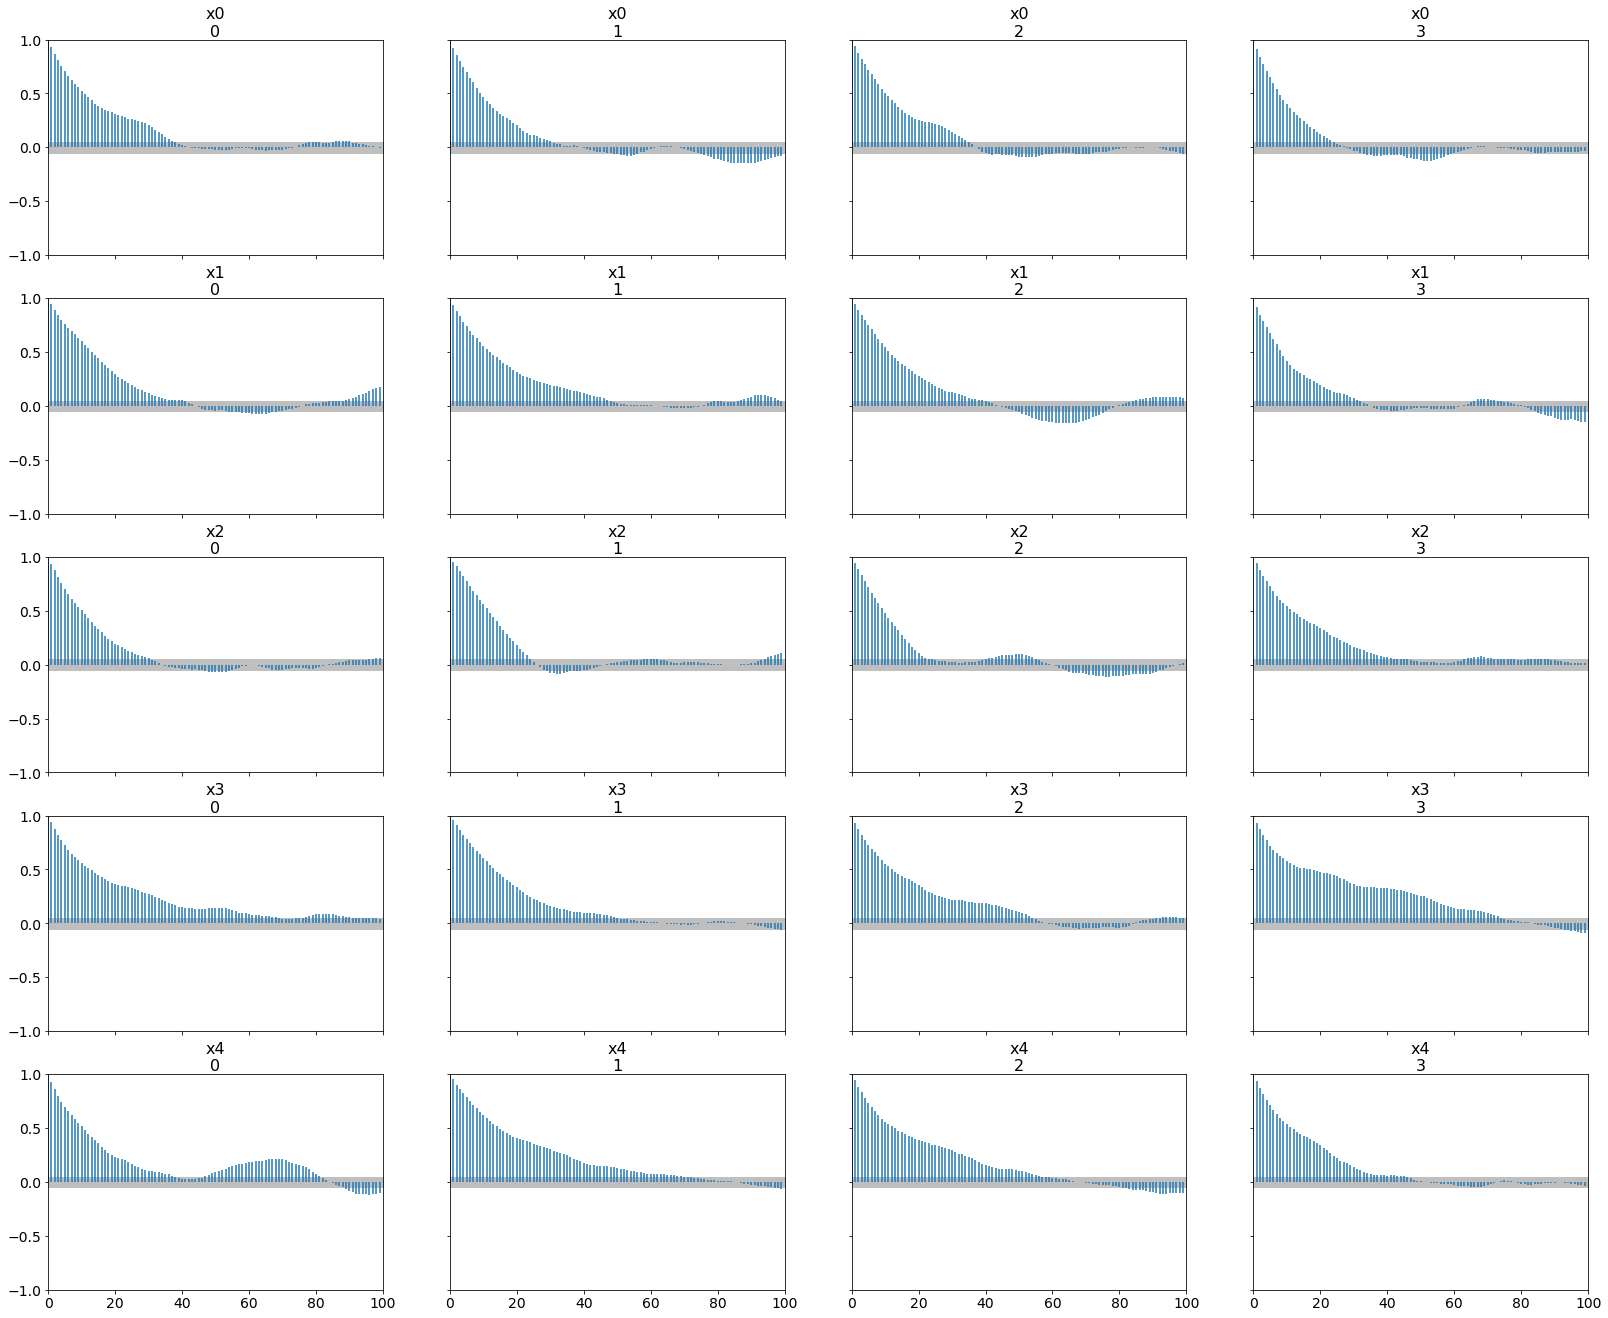

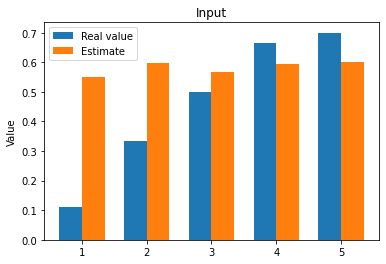

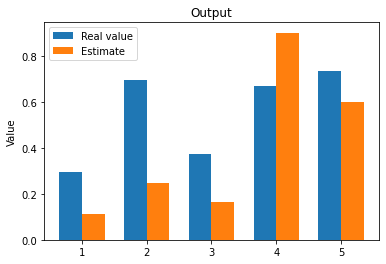

The function inverse took 2030.943510055542 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
print(("adaptive case"))
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=4
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

adaptive case
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/1


Running chain, α = 0.15: 100%|██████████| 3000/3000 [08:09<00:00,  6.13it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 1501), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1501), minimum_shape: (chains=2, draws=4)


estimated values are [0.572 0.625 0.558 0.608 0.574]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.572  0.379  -0.009    1.343      0.073    0.052      28.0     100.0   
x1  0.625  0.452  -0.111    1.325      0.116    0.083      13.0      35.0   
x2  0.558  0.385  -0.131    1.199      0.051    0.038      57.0      71.0   
x3  0.608  0.354   0.016    1.279      0.064    0.051      31.0      57.0   
x4  0.574  0.343  -0.090    1.107      0.052    0.037      45.0      89.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
x4    NaN  
Autocorrelation...
[0.572 0.625 0.558 0.608 0.574]
[0.11234 0.333   0.5     0.665   0.7    ]


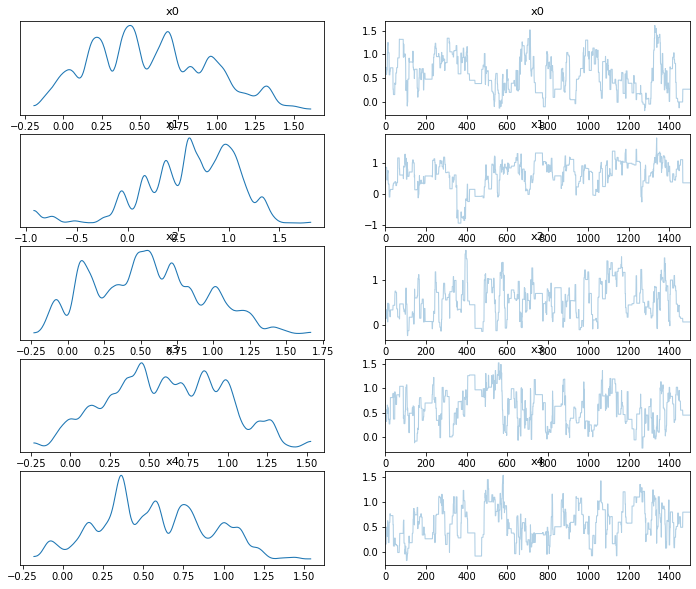

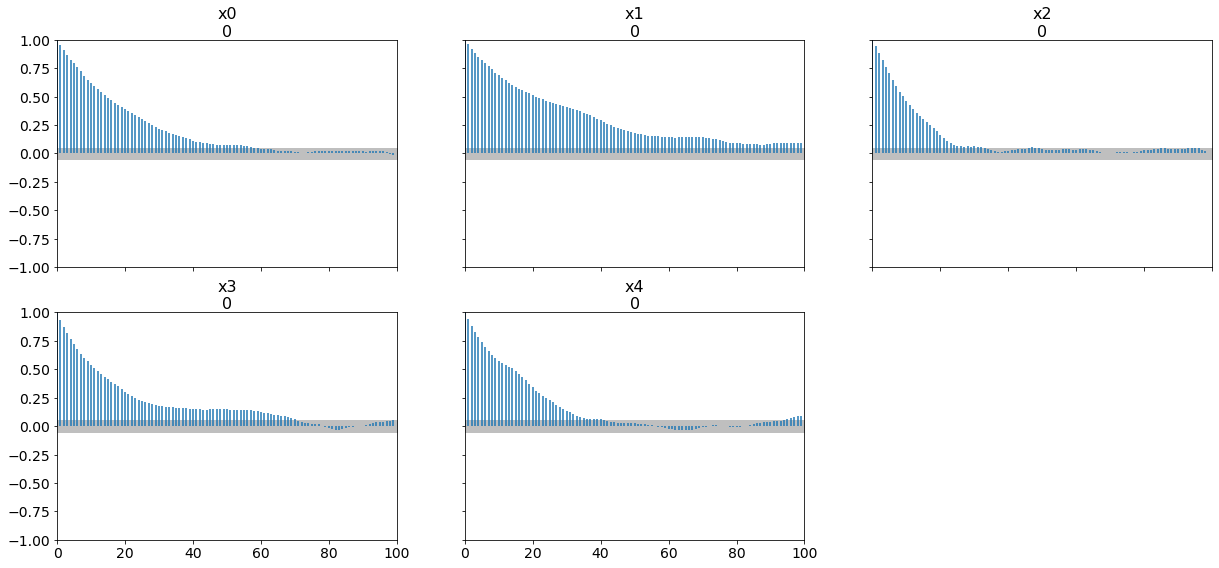

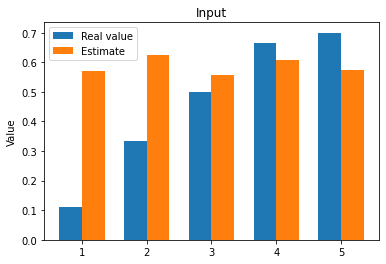

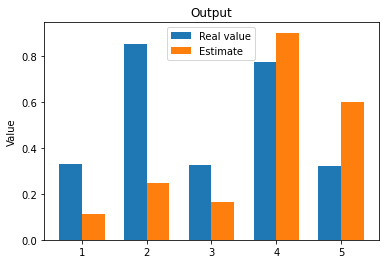

The function inverse took 492.39684987068176 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
print(("adaptive case"))
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x)) # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=1
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5#*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.05 # covariance of the noise added to the known data
sigma_noise=0.05#*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*4 # covarianza della distribuzione di proposta!   <- elemento principale da regolare per modificare parametro di accettazione
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=2
# alfa indica acceptance rejection, mi aspetto valori tra 0.3 e 0.5 che si riducano (mi sto avvicinando a valore vero, per cui prob piu alta)
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/2


Running chain, α = 0.07:   1%|▏         | 42/3000 [00:07<09:27,  5.21it/s]Exception ignored in: <function UniquePtr.__del__ at 0x000001F463F0B130>
Traceback (most recent call last):
  File "c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 74, in __del__
    self.deleter(obj)
KeyboardInterrupt: 
Running chain, α = 0.01:   3%|▎         | 101/3000 [00:19<08:25,  5.74it/s]

In [ ]:
for j in range(len(model_list)):
    estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

ValueError: setting an array element with a sequence.